# CFO Prediction — v4: Transition-Based Funnel Model

## Motivación
El **enfoque por transiciones** modela el funnel como un **sistema probabilístico de estados**
donde cada transición tiene su propio modelo predictivo con features específicas.

```
S0 ──► S1 ──────► S2 ──────────► S3
Lead  DocColl   Hired            CFO
```

$$P(\text{CFO}) = P(S_1|S_0) \times P(S_2|S_1) \times P(\text{CFO}|S_2)$$

| Stage | Estado | Condición de llegada | Modelo |
|-------|--------|---------------------|--------|
| **S0** | Lead Creado | Registro en el sistema | — (punto de entrada) |
| **S1** | Doc-Collection Completada | `doc_coll_to_doc_review` IS NOT NULL | M1: P(S1\|S0) |
| **S2** | Hired | `was_hired == 1` | M2: P(S2\|S1) |
| **S3** | CFO | `is_cfo == 1` | M3: P(CFO\|S2) |




In [10]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
    "google-cloud-bigquery", "db-dtypes",
    "lightgbm", "xgboost", "catboost",
    "optuna", "shap", "scikit-learn",
    "pandas", "matplotlib", "seaborn",
])

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import bigquery

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.isotonic import IsotonicRegression as IsoReg   # isotonic calibration
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve,
    roc_curve, f1_score, precision_score, recall_score, brier_score_loss,
    confusion_matrix,
)

import lightgbm as lgb
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import shap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
sns.set_palette("husl")

import xgboost as xgb
import catboost as cb
print(f"LightGBM {lgb.__version__} | XGBoost {xgb.__version__} | CatBoost {cb.__version__}")
print(f"Optuna {optuna.__version__} | SHAP {shap.__version__}")


LightGBM 4.6.0 | XGBoost 3.2.0 | CatBoost 1.2.10
Optuna 4.8.0 | SHAP 0.51.0


---\n## 1. Data Loading (BigQuery)

In [11]:
from google.colab import auth
auth.authenticate_user()

import google.auth
credentials, _ = google.auth.default()

project_id = "dhub-glovo"
client = bigquery.Client(project=project_id, credentials=credentials)

funnel_data = """
WITH raw_data AS (
    SELECT
        a.country_code, ci.city_code, a.applicant_id, a.rider_id,
        a.created_at, a.approved_at,
        DATE_TRUNC(DATE(a.created_at), ISOWEEK) AS week,
        a.workflow.workflow_name,
        UPPER(a.custom_non_pii_fields.utm.source) AS utm_source_raw,
        UPPER(a.custom_non_pii_fields.utm.medium) AS utm_medium_raw,
        t.tier, s.name AS stage_name, tr.to_state,
        tr.created_at AS transition_created_at
    FROM `fulfillment-dwh-production.curated_data_shared.applicants` AS a
    CROSS JOIN UNNEST(a.workflow.tiers)  AS t
    CROSS JOIN UNNEST(t.stage)           AS s
    CROSS JOIN UNNEST(s.transitions)     AS tr
    JOIN `fulfillment-dwh-production.curated_data_shared.countries` AS co ON co.country_code = a.country_code
    CROSS JOIN UNNEST(co.cities) AS ci ON a.city_id = ci.id
    WHERE a.country_code = 'gv-pl'
    AND DATE(a.created_at) >= DATE_TRUNC(DATE_SUB(CURRENT_DATE, INTERVAL 12 MONTH), MONTH)
    AND DATE(a.created_at) <= DATE_SUB(CURRENT_DATE, INTERVAL 30 DAY)
),

-- Mini query de diagnóstico embebida para ver doc_collection por workflow
doc_collection_check AS (
    SELECT
        r.workflow_name,
        r.applicant_id,
        -- "3PL already assigned": tier 0
        CASE WHEN r.workflow_name = '3PL already assigned leads PL'
                  AND r.tier = 0 AND r.stage_name = 'Document Collection' AND r.to_state = 'available'
             THEN r.transition_created_at END AS doc_col_start_3pl,
        CASE WHEN r.workflow_name = '3PL already assigned leads PL'
                  AND r.tier = 0 AND r.stage_name = 'Document Collection' AND r.to_state = 'completed'
             THEN r.transition_created_at END AS doc_col_end_3pl,
        -- "Other leads PL": tier 1
        CASE WHEN r.workflow_name = 'Other leads PL'
                  AND r.tier = 1 AND r.stage_name = 'Document Collection' AND r.to_state = 'available'
             THEN r.transition_created_at END AS doc_col_start_other,
        CASE WHEN r.workflow_name = 'Other leads PL'
                  AND r.tier = 1 AND r.stage_name = 'Document Collection' AND r.to_state = 'completed'
             THEN r.transition_created_at END AS doc_col_end_other
    FROM raw_data AS r
),

times_funnel_stages_raw AS (
    SELECT
        r.country_code, r.city_code, r.week, r.applicant_id, r.rider_id,
        r.created_at, r.approved_at, r.workflow_name,
        r.utm_source_raw, r.utm_medium_raw,

        -- T0 selección 3PL: solo "Other leads PL", tier 0
        CASE WHEN r.workflow_name = 'Other leads PL'
                  AND r.tier = 0 AND r.stage_name = 'Document Collection' AND r.to_state = 'available'
             THEN r.transition_created_at END AS pending_3pl_start,

        CASE WHEN r.workflow_name = 'Other leads PL'
                  AND r.tier = 0 AND r.stage_name = 'Document Collection' AND r.to_state = 'completed'
             THEN r.transition_created_at END AS pending_3pl_end,

        -- doc_collection: tier 1 para "Other leads PL", tier 0 para "3PL already assigned"
        CASE WHEN r.workflow_name = 'Other leads PL'
                  AND r.tier = 1 AND r.stage_name = 'Document Collection' AND r.to_state = 'available'
             THEN r.transition_created_at
             WHEN r.workflow_name LIKE '%3PL already assigned%'
                  AND r.tier = 0 AND r.stage_name = 'Document Collection' AND r.to_state = 'available'
             THEN r.transition_created_at END AS doc_collection_start,

        CASE WHEN r.workflow_name = 'Other leads PL'
                  AND r.tier = 1 AND r.stage_name = 'Document Collection' AND r.to_state = 'completed'
             THEN r.transition_created_at
             WHEN r.workflow_name LIKE '%3PL already assigned%'
                  AND r.tier = 0 AND r.stage_name = 'Document Collection' AND r.to_state = 'completed'
             THEN r.transition_created_at END AS doc_collection_end,

        -- Document Review
        CASE WHEN r.stage_name = 'Document Review' AND r.to_state = 'available'
             THEN r.transition_created_at END AS doc_review_start,
        CASE WHEN r.stage_name = 'Document Review' AND r.to_state = 'action_required'
             THEN r.transition_created_at END AS doc_nok_start,
        CASE WHEN r.stage_name = 'Document Review' AND r.to_state = 'completed'
             THEN r.transition_created_at END AS doc_review_end,

        -- Waiting List
        CASE WHEN r.stage_name = 'Waiting list' AND r.to_state = 'available'
             THEN r.transition_created_at END AS wl_start,
        CASE WHEN r.stage_name = 'Waiting list' AND r.to_state = 'completed'
             THEN r.transition_created_at END AS wl_end,

        -- Equipment Collection
        CASE WHEN r.stage_name = 'Equipment Collection' AND r.to_state = 'available'
             THEN r.transition_created_at END AS equip_collection_start,
        CASE WHEN r.stage_name = 'Equipment Collection' AND r.to_state = 'completed'
             THEN r.transition_created_at END AS equip_collection_end

    FROM raw_data AS r
),

times_funnel_stages AS (
    SELECT
        t.country_code, t.city_code, t.week, t.applicant_id, t.rider_id,
        t.created_at, t.approved_at, t.workflow_name,
        ANY_VALUE(t.utm_source_raw)   AS utm_source_raw,
        ANY_VALUE(t.utm_medium_raw)   AS utm_medium_raw,
        MAX(t.pending_3pl_start)      AS pending_3pl_start,
        MAX(t.pending_3pl_end)        AS pending_3pl_end,
        MAX(t.doc_collection_start)   AS doc_collection_start,
        MAX(t.doc_collection_end)     AS doc_collection_end,
        MAX(t.doc_review_start)       AS doc_review_start,
        MIN(t.doc_nok_start)          AS doc_nok_start,  -- MIN = primer NOK
        MAX(t.doc_review_end)         AS doc_review_end,
        MAX(t.wl_start)               AS wl_start,
        MAX(t.wl_end)                 AS wl_end,
        MAX(t.equip_collection_start) AS equip_collection_start,
        MAX(t.equip_collection_end)   AS equip_collection_end
    FROM times_funnel_stages_raw AS t
    GROUP BY 1,2,3,4,5,6,7,8
),

funnel_stages_difference AS (
    SELECT
        t.country_code, t.city_code, t.week, t.applicant_id, t.rider_id,
        t.workflow_name,
        CASE WHEN t.approved_at IS NOT NULL THEN 1 ELSE 0 END AS was_hired,

        -- lead_to_hired: NULL si no se contrató
        CASE WHEN t.approved_at IS NOT NULL
             THEN GREATEST((CAST(DATE_DIFF(t.approved_at, t.created_at, MINUTE) AS FLOAT64)/60)/24, 0)
        END AS lead_to_hired,

        -- pending_3pl_time: solo "Other leads PL", NULL para "3PL already assigned"
        CASE WHEN t.pending_3pl_start IS NOT NULL AND t.pending_3pl_end IS NOT NULL
             THEN GREATEST((CAST(DATE_DIFF(t.pending_3pl_end, t.pending_3pl_start, MINUTE) AS FLOAT64)/60)/24, 0)
        END AS pending_3pl_time,

        -- doc_collection_time: tiempo real subiendo docs (ambos workflows)
        CASE WHEN t.doc_collection_start IS NOT NULL AND t.doc_collection_end IS NOT NULL
             THEN GREATEST((CAST(DATE_DIFF(t.doc_collection_end, t.doc_collection_start, MINUTE) AS FLOAT64)/60)/24, 0)
        END AS doc_collection_time,

        -- doc_coll_to_doc_review: espera entre fin docs y inicio revisión
        CASE WHEN t.doc_collection_end IS NOT NULL AND t.doc_review_start IS NOT NULL
             THEN GREATEST((CAST(DATE_DIFF(t.doc_review_start, t.doc_collection_end, MINUTE) AS FLOAT64)/60)/24, 0)
        END AS doc_coll_to_doc_review,

        -- doc_review_time: tiempo total en revisión
        CASE WHEN t.doc_review_start IS NOT NULL AND t.doc_review_end IS NOT NULL
             THEN GREATEST((CAST(DATE_DIFF(t.doc_review_end, t.doc_review_start, MINUTE) AS FLOAT64)/60)/24, 0)
        END AS doc_review_time,

        -- had_doc_nok: flag binario
        CASE WHEN t.doc_nok_start IS NOT NULL THEN 1 ELSE 0 END AS had_doc_nok,

        -- doc_nok_correction_time: desde primer NOK hasta completed
        CASE WHEN t.doc_nok_start IS NOT NULL AND t.doc_review_end IS NOT NULL
             THEN GREATEST((CAST(DATE_DIFF(t.doc_review_end, t.doc_nok_start, MINUTE) AS FLOAT64)/60)/24, 0)
        END AS doc_nok_correction_time,

        -- wl_time: tiempo en waiting list
        CASE WHEN t.wl_start IS NOT NULL AND t.wl_end IS NOT NULL
             THEN GREATEST((CAST(DATE_DIFF(t.wl_end, t.wl_start, MINUTE) AS FLOAT64)/60)/24, 0)
        END AS wl_time,

        -- equip_time: tiempo en equipment collection
        CASE WHEN t.equip_collection_start IS NOT NULL AND t.equip_collection_end IS NOT NULL
             THEN GREATEST((CAST(DATE_DIFF(t.equip_collection_end, t.equip_collection_start, MINUTE) AS FLOAT64)/60)/24, 0)
        END AS equip_time,

        -- equip_to_hired: desde fin equipment hasta contratación
        CASE WHEN t.equip_collection_end IS NOT NULL AND t.approved_at IS NOT NULL
             THEN GREATEST((CAST(DATE_DIFF(t.approved_at, t.equip_collection_end, MINUTE) AS FLOAT64)/60)/24, 0)
        END AS equip_to_hired

    FROM times_funnel_stages AS t
),

target AS (
    SELECT
        a.applicant_id, a.rider_id,
        CASE WHEN ra.first_order_creation_datetime IS NOT NULL THEN 1 ELSE 0 END AS is_cfo
    FROM `fulfillment-dwh-production.curated_data_shared.applicants` AS a
    LEFT JOIN `fulfillment-dwh-production.curated_data_shared_glovo.rider_attributes__rider_attributes` AS ra
        ON ra.rider_id = a.rider_id
    WHERE a.country_code = 'gv-pl'
    AND DATE(a.created_at) >= DATE_TRUNC(DATE_SUB(CURRENT_DATE, INTERVAL 12 MONTH), MONTH)
    AND DATE(a.created_at) <= DATE_SUB(CURRENT_DATE, INTERVAL 30 DAY)
),

rider_profile AS (
    SELECT
        a.applicant_id, a.rider_id,
        a.rejection_category, a.rejection_type, a.current_stage_name,
        a.duplicate, a.company_name, a.created_at,
        (SELECT cf.value FROM UNNEST(a.custom_fields) AS cf WHERE cf.name = 'vehicle' LIMIT 1) AS vehicle_from_custom_fields,
        CASE
            WHEN UPPER(a.custom_non_pii_fields.utm.source) LIKE '%REFERRAL%'
              OR UPPER(a.custom_non_pii_fields.utm.source) LIKE '%RAF%'      THEN 'REFERRAL'
            WHEN UPPER(a.custom_non_pii_fields.utm.source) LIKE '%3PL%'      THEN '3PL'
            WHEN UPPER(a.custom_non_pii_fields.utm.source) LIKE '%RIDERHUB%' THEN 'RIDER WEB'
            WHEN UPPER(a.custom_non_pii_fields.utm.medium) LIKE '%JOBPLATFORM%' THEN 'JOB PLATFORM'
            WHEN (UPPER(a.custom_non_pii_fields.utm.source) LIKE '%GOOGLE%'
               OR UPPER(a.custom_non_pii_fields.utm.source) LIKE '%FACEBOOK%'
               OR UPPER(a.custom_non_pii_fields.utm.source) LIKE '%TIKTOK%')
             AND UPPER(a.custom_non_pii_fields.utm.medium) <> 'SOCIAL'       THEN 'PERF MKT'
            WHEN UPPER(a.custom_non_pii_fields.utm.medium) = 'OFFLINE'
             AND UPPER(a.custom_non_pii_fields.utm.source) NOT IN ('BRANDAMBASSADOR','CAPTAIN') THEN 'OFFLINE'
            WHEN UPPER(a.custom_non_pii_fields.utm.source) IN ('BRANDAMBASSADOR','CAPTAIN') THEN 'BRAND AMBASSADOR'
            WHEN UPPER(a.custom_non_pii_fields.utm.medium) = 'SOCIAL'        THEN 'SOCIAL MEDIA'
            ELSE 'ORGANIC'
        END AS source,
        CASE WHEN a.custom_non_pii_fields.registration_source = 'web' THEN 1
             WHEN a.custom_non_pii_fields.registration_source = 'app' THEN 0
             ELSE NULL END AS registered_via_web,
        CASE WHEN EXTRACT(MONTH FROM a.created_at) IN (12,1,2) THEN 'winter'
             WHEN EXTRACT(MONTH FROM a.created_at) IN (3,4,5)  THEN 'spring'
             WHEN EXTRACT(MONTH FROM a.created_at) IN (6,7,8)  THEN 'summer'
             ELSE 'autumn' END AS apply_season
    FROM `fulfillment-dwh-production.curated_data_shared.applicants` AS a
    WHERE a.country_code = 'gv-pl'
    AND DATE(a.created_at) >= DATE_TRUNC(DATE_SUB(CURRENT_DATE, INTERVAL 12 MONTH), MONTH)
    AND DATE(a.created_at) <= DATE_SUB(CURRENT_DATE, INTERVAL 30 DAY)
),

rider_attributes AS (
    SELECT ra.rider_id, ra.vehicle_type, ra.business_model, ra.is_3pl
    FROM `fulfillment-dwh-production.curated_data_shared_glovo.rider_attributes__rider_attributes` AS ra
    WHERE ra.country_code = 'PL'
),

-- Diagnóstico: verificar captura de doc_collection por workflow
diag_doc_collection AS (
    SELECT
        t.workflow_name,
        COUNT(*) AS n,
        COUNTIF(t.doc_collection_start IS NOT NULL) AS con_doc_collection_start,
        COUNTIF(t.doc_collection_end IS NOT NULL)   AS con_doc_collection_end
    FROM times_funnel_stages AS t
    GROUP BY t.workflow_name
)

SELECT
    d.applicant_id,
    d.city_code,
    rp.created_at,
    DATE_TRUNC(d.week, MONTH)           AS month,
    d.rider_id,
    d.workflow_name,

    -- Target y flags
    t.is_cfo,
    d.was_hired,
    d.had_doc_nok,

    -- Perfil del lead
    rp.rejection_category,
    rp.rejection_type,
    rp.current_stage_name,
    rp.company_name,
    rp.vehicle_from_custom_fields,
    ra.vehicle_type,
    ra.business_model,
    ra.is_3pl,
    rp.source,
    rp.registered_via_web,
    rp.apply_season,
    rp.duplicate,

    -- Tiempos del funnel
    d.lead_to_hired,
    d.pending_3pl_time,
    d.doc_collection_time,
    d.doc_coll_to_doc_review,
    d.doc_review_time,
    d.doc_nok_correction_time,
    d.wl_time,
    d.equip_time,
    d.equip_to_hired

FROM funnel_stages_difference AS d
LEFT JOIN target           AS t  ON d.applicant_id = t.applicant_id
LEFT JOIN rider_profile    AS rp ON d.applicant_id = rp.applicant_id
LEFT JOIN rider_attributes AS ra ON d.rider_id     = ra.rider_id
WHERE d.city_code IS NOT NULL
"""

print("Running BigQuery...")
df_raw = client.query(funnel_data).result().to_dataframe()
print(f"Shape: {df_raw.shape}")
df_raw.head(3)

Running BigQuery...
Shape: (164527, 30)


,applicant_id,city_code,created_at,month,rider_id,workflow_name,is_cfo,was_hired,had_doc_nok,rejection_category,...,duplicate,lead_to_hired,pending_3pl_time,doc_collection_time,doc_coll_to_doc_review,doc_review_time,doc_nok_correction_time,wl_time,equip_time,equip_to_hired
0,ad6de7d1-ee72-429f-ad0f-d8f7ec75ae92,WAW,2026-02-25 14:14:58.508443+00:00,2026-02-01,<NA>,3PL already assigned leads PL\t,0,0,0,None,...,False,NaN,NaN,0.000000,0.0,0.000000,NaN,0.624306,0.0,NaN
1,378f1256-5592-4263-857d-d6c41501e280,KRA,2026-01-26 11:32:21.666339+00:00,2026-01-01,<NA>,3PL already assigned leads PL\t,0,0,1,None,...,False,NaN,NaN,0.000694,0.0,44.990278,44.924306,NaN,NaN,NaN
2,55630f8a-a041-48f0-9c10-6f215329141c,RZE,2026-02-06 11:21:57.249936+00:00,2026-02-01,<NA>,3PL already assigned leads PL\t,0,0,1,None,...,False,NaN,NaN,0.002778,0.0,52.983333,52.975694,NaN,NaN,NaN


---
## 2. Feature Engineering Base + Definición de Estados del Funnel

Lo primero que hacemos es crear una copia del dataset original para no modificar directamente df_raw. Después, convertimos created_at a formato fecha-hora sin zona horaria. Esto se hace porque muchas librerías de pandas y de modelado funcionan de forma más estable cuando las fechas están unificadas en formato datetime “naive”, es decir, sin timezone. Como aquí lo que nos interesa no es comparar husos horarios internacionales, sino trabajar con el momento de creación del lead de forma consistente, eliminar la zona horaria simplifica el procesamiento.

A continuación, filtramos dos cosas:

1. eliminamos duplicados lógicos (duplicate == False), porque no queremos que el mismo applicant aparezca repetido y contamine el aprendizaje;
2. aplicamos un migration cutoff en 2025-03-01, quedándonos solo con leads creados desde esa fecha.


Una vez limpia la base, empezamos con el primer gran grupo de features: las variables temporales derivadas de created_at.

Aquí asumimos que el momento en el que entra un lead al funnel puede influir en su comportamiento posterior. No todos los leads tienen la misma probabilidad de avanzar si llegan un lunes por la mañana, un sábado por la noche, en invierno o en el último trimestre del año. Puede haber patrones operativos, de marketing o de comportamiento del candidato asociados al tiempo.

Por eso generamos:

_month_period: una versión mensual de la fecha, útil para agregaciones históricas;
hour_of_day: la hora del día en que entra el lead;
day_of_week: el día de la semana;
month_num: el mes;
quarter: el trimestre;
is_weekend: indicador binario de si el lead se creó en fin de semana.

Además, no nos quedamos solo con la versión entera de hora, día o mes. También construimos variables cíclicas con seno y coseno:

hour_sin, hour_cos
dow_sin, dow_cos
month_sin, month_cos

Esto se hace porque variables como la hora o el mes tienen naturaleza circular. Por ejemplo, las 23:00 y las 00:00 están muy cerca en el tiempo real, pero si las dejamos como números 23 y 0, el modelo puede interpretarlas como extremos muy lejanos. Lo mismo ocurre con diciembre y enero. Las transformaciones seno/coseno corrigen ese problema y permiten que el modelo entienda mejor la continuidad temporal.



Después trabajamos la variable vehicle_from_custom_fields, que en crudo puede venir con formatos distintos, mayúsculas, espacios o categorías muy fragmentadas. Aquí hacemos una limpieza semántica:

pasamos todo a minúsculas,
eliminamos espacios innecesarios,
agrupamos equivalencias razonables.

Por ejemplo:

scooter y moped se agrupan como motorbike,
walker y on foot se agrupan como walker.

Además, si alguna categoría no se puede mapear, la enviamos a unknown, lo cual evita perder observaciones y mantiene la variable usable.



Después construimos dos variables:

city_freq: frecuencia relativa de cada ciudad en el dataset;
city_group: dejamos las 20 ciudades más frecuentes como categorías propias y agrupamos el resto en OTHER.

Esto tiene dos ventajas.

La primera es que city_freq introduce una señal de tamaño o relevancia de mercado. No es lo mismo un lead que entra en una ciudad con muchísimo volumen que uno que entra en una ciudad residual. Esa frecuencia puede capturar diferencias estructurales del sistema.

La segunda es que city_group reduce la cardinalidad de la variable ciudad. Si dejáramos todas las ciudades individualmente, muchas tendrían muy pocos ejemplos y producirían ruido o sobreajuste. Agrupar las menos frecuentes en OTHER hace la variable más estable.


La variable registered_via_web se rellena con -1 cuando falta y luego se convierte a entero. Esto implica que estamos distinguiendo tres posibles situaciones:

1. registrado por web,
2. registrado por otro canal conocido,
3. valor ausente o desconocido.



Después codificamos varias variables categóricas:

source
apply_season
vehicle_clean
city_group

Primero rellenamos nulos con UNKNOWN y luego usamos LabelEncoder.

Aquí hay un matiz importante. Este tipo de codificación no introduce una “distancia real” entre categorías, simplemente las transforma en enteros para que ciertos modelos puedan procesarlas. En algunos casos, especialmente con árboles, esto es suficiente si luego se combina con splits no lineales. Además, mantener esta codificación homogénea facilita comparar distintos modelos dentro del mismo pipeline.

También guardamos los encoders en le_dict, lo cual es útil si más adelante queremos:

interpretar resultados,
decodificar categorías,
o aplicar exactamente la misma transformación a nuevos datos.

Después realizamos la definición de targets intermedios del funnel


reached_s1: indica si el lead alcanzó S1, usando como señal que doc_coll_to_doc_review no sea nulo.
reached_s2: indica si el lead fue hired, a partir de was_hired.



Después establecemos las features históricas con lag: contexto del pasado sin leakage


La idea es introducir información contextual histórica, pero sin caer en leakage. Es decir, queremos que el modelo sepa cómo se comportaba el sistema en el pasado reciente, pero sin darle acceso a información del futuro.

Para eso:

1. ordenamos el dataset cronológicamente por created_at;
2. agregamos por city_group y mes para calcular:
 lag_s1_city: tasa histórica de llegada a S1 por ciudad;
 lag_cfo_city: tasa histórica de CFO por ciudad;
3. hacemos lo mismo por source:
lag_s1_src
lag_cfo_src;
4. aplicamos shift(1) dentro de cada grupo.

Ese shift(1) es la clave. Hace que, para un mes dado, usemos la información del mes anterior, no la del mismo mes. Así evitamos que el modelo vea estadísticas construidas con datos contemporáneos o futuros del propio registro. Es una manera de darle memoria histórica al sistema sin contaminar la predicción.

Estas variables ayudan mucho porque capturan contexto operativo: por ejemplo, si en una ciudad el funnel venía rindiendo especialmente bien o mal el mes anterior, eso puede afectar la probabilidad de conversión de nuevos leads. Lo mismo con los canales de adquisición.


Como al aplicar shift(1) el primer mes de cada grupo se queda sin histórico previo, rellenamos esos nulos con la media global correspondiente.

Por ejemplo:

lag_s1_city se rellena con la media global de reached_s1,
lag_cfo_city con la media global de is_cfo.

Esto tiene sentido porque, si no tenemos histórico previo para una ciudad o source en ese primer mes, la mejor estimación neutral es el comportamiento promedio global del sistema. No es perfecto, pero es una imputación razonable y evita perder observaciones o introducir valores arbitrarios.


Por último, imprimimos un pequeño resumen del funnel:

cuántos leads hay en S0,
cuántos alcanzan S1,
cuántos llegan a S2,

In [12]:
# ── Base: filter, tz-strip, migration cutoff ─────────────────────────────────
df = df_raw.copy()
df["created_at"] = pd.to_datetime(df["created_at"]).dt.tz_convert(None)
df = df[df["duplicate"] == False].copy()
df = df[df["created_at"] >= pd.Timestamp("2025-03-01")].copy()
print(f"Applicants after dedup + migration filter: {len(df):,}")

# ── Right-censoring filter ────────────────────────────────────────────────────
# Leads created too recently haven't had time to complete the hiring funnel.
# We compute a data-driven buffer from the P75 of lead_to_hired in mature cohorts,
# with a minimum floor of 60 days.
_matured = df[df["was_hired"] == 1]["lead_to_hired"].dropna()
CENSORING_DAYS = max(60, int(np.ceil(_matured.quantile(0.75))))
CENSORING_CUTOFF = pd.Timestamp.now().normalize() - pd.Timedelta(days=CENSORING_DAYS)
_before = len(df)
df = df[df["created_at"] <= CENSORING_CUTOFF].copy()
print(f"Censoring filter: removed {_before - len(df):,} leads created after "
      f"{CENSORING_CUTOFF.date()} (buffer={CENSORING_DAYS}d, P75 lead_to_hired)")
print(f"Applicants after censoring filter: {len(df):,}")

# ── Temporal features ─────────────────────────────────────────────────────────
df["_month_period"] = df["created_at"].dt.to_period("M").astype(str)
df["hour_of_day"]   = df["created_at"].dt.hour
df["hour_sin"]      = np.sin(2 * np.pi * df["hour_of_day"] / 24)
df["hour_cos"]      = np.cos(2 * np.pi * df["hour_of_day"] / 24)
df["day_of_week"]   = df["created_at"].dt.dayofweek
df["dow_sin"]       = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"]       = np.cos(2 * np.pi * df["day_of_week"] / 7)
df["month_num"]     = df["created_at"].dt.month
df["month_sin"]     = np.sin(2 * np.pi * df["month_num"] / 12)
df["month_cos"]     = np.cos(2 * np.pi * df["month_num"] / 12)
df["quarter"]       = df["created_at"].dt.quarter
df["is_weekend"]    = (df["day_of_week"] >= 5).astype(int)

# ── Vehicle ───────────────────────────────────────────────────────────────────
vehicle_map = {
    "car": "car", "electric car": "electric_car",
    "bicycle": "bicycle", "electric bicycle": "electric_bicycle",
    "motorbike": "motorbike", "electric motorbike": "electric_motorbike",
    "scooter": "motorbike", "moped": "motorbike",
    "walker": "walker", "on foot": "walker",
}
df["vehicle_clean"] = (
    df["vehicle_from_custom_fields"].str.lower().str.strip()
    .map(vehicle_map).fillna("unknown")
)

# ── City ──────────────────────────────────────────────────────────────────────
city_freq_map = df["city_code"].value_counts(normalize=True).to_dict()
df["city_freq"]  = df["city_code"].map(city_freq_map)
top_cities       = df["city_code"].value_counts().head(20).index.tolist()
df["city_group"] = df["city_code"].apply(lambda x: x if x in top_cities else "OTHER")

# ── Other static ──────────────────────────────────────────────────────────────
df["registered_via_web"] = df["registered_via_web"].fillna(-1).astype(int)

# ── Label encoding ────────────────────────────────────────────────────────────
CAT_COLS = ["source", "apply_season", "vehicle_clean", "city_group"]
le_dict  = {}
for col in CAT_COLS:
    df[col] = df[col].fillna("UNKNOWN")
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

# ── Transition targets ────────────────────────────────────────────────────────
df["reached_s1"] = df["doc_coll_to_doc_review"].notna().astype(int)  # S0 → S1
df["reached_s2"] = df["was_hired"].astype(int)                        # S0 → S2

# ── Feature Engineering Avanzado: Historical Lag Stats (1-month lag, sin leakage) ──
# Computed AFTER label encoding so we merge on numeric city/source codes.
# Shift(1) ensures each month uses only stats from the PRIOR month → no leakage.
df = df.sort_values("created_at").reset_index(drop=True)

_mc = (df.groupby(["city_group", "_month_period"])
         .agg(lag_s1_city=("reached_s1","mean"),
              lag_cfo_city=("is_cfo","mean"))
         .reset_index()
         .sort_values(["city_group", "_month_period"]))
_mc[["lag_s1_city","lag_cfo_city"]] = (
    _mc.groupby("city_group")[["lag_s1_city","lag_cfo_city"]].shift(1)
)
df = df.merge(_mc[["city_group","_month_period","lag_s1_city","lag_cfo_city"]],
              on=["city_group","_month_period"], how="left")

_ms = (df.groupby(["source", "_month_period"])
         .agg(lag_s1_src=("reached_s1","mean"),
              lag_cfo_src=("is_cfo","mean"))
         .reset_index()
         .sort_values(["source", "_month_period"]))
_ms[["lag_s1_src","lag_cfo_src"]] = (
    _ms.groupby("source")[["lag_s1_src","lag_cfo_src"]].shift(1)
)
df = df.merge(_ms[["source","_month_period","lag_s1_src","lag_cfo_src"]],
              on=["source","_month_period"], how="left")

# Fill first-month NaN with global historical mean (no prior period → best estimate)
for col, fallback_series in [
    ("lag_s1_city",  df["reached_s1"]),
    ("lag_cfo_city", df["is_cfo"]),
    ("lag_s1_src",   df["reached_s1"]),
    ("lag_cfo_src",  df["is_cfo"]),
]:
    df[col] = df[col].fillna(fallback_series.mean())

print(f"\nFunnel de transiciones:")
print(f"  S0 (Lead creado):              {len(df):>8,}  — punto de partida")
print(f"  S0→S1 (Doc Collection OK):     {df['reached_s1'].sum():>8,}  ({df['reached_s1'].mean()*100:.1f}%)")
n_s1 = df["reached_s1"].sum()
n_s2 = df["reached_s2"].sum()
n_cfo = df["is_cfo"].sum()
print(f"  S0→S2 (Hired):                 {n_s2:>8,}  ({n_s2/len(df)*100:.1f}%)")
print(f"  S0→CFO:                        {n_cfo:>8,}  ({n_cfo/len(df)*100:.1f}%)")
print(f"\nLag features added (1-month lag, no leakage):")
print(f"  lag_s1_city, lag_cfo_city, lag_s1_src, lag_cfo_src")


Applicants after dedup + migration filter: 158,344
Censoring filter: removed 12,820 leads created after 2026-02-06 (buffer=60d, P75 lead_to_hired)
Applicants after censoring filter: 145,524

Funnel de transiciones:
  S0 (Lead creado):               145,524  — punto de partida
  S0→S1 (Doc Collection OK):       85,744  (58.9%)
  S0→S2 (Hired):                   63,859  (43.9%)
  S0→CFO:                          36,706  (25.2%)

Lag features added (1-month lag, no leakage):
  lag_s1_city, lag_cfo_city, lag_s1_src, lag_cfo_src


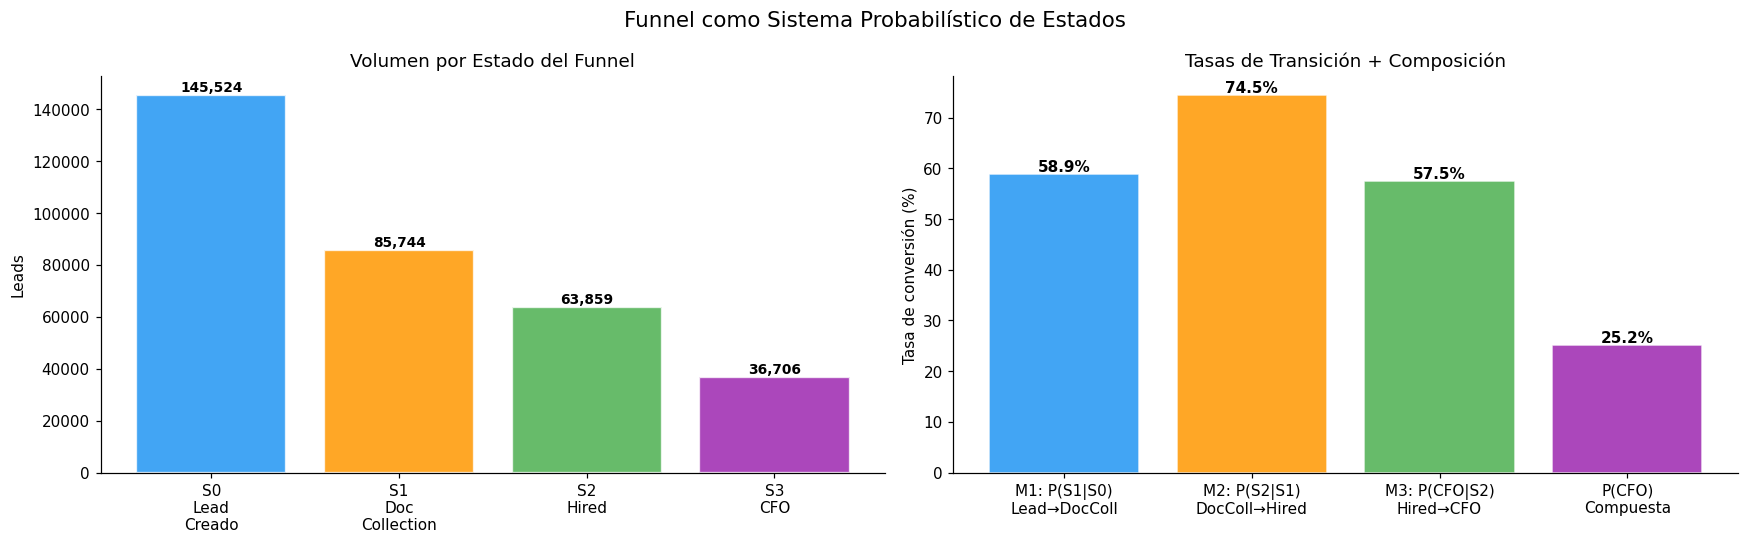


Fórmula de composición verificada:
  P(CFO) = 0.5892 × 0.7448 × 0.5748 = 0.2522
  P(CFO) real en dataset:                               0.2522


In [13]:
# ── Funnel system visualization ──────────────────────────────────────────────
n_s0 = len(df)
n_s1 = int(df["reached_s1"].sum())
n_s2 = int(df["was_hired"].sum())
n_s3 = int(df["is_cfo"].sum())

cr_01 = n_s1 / n_s0
cr_12 = n_s2 / n_s1
cr_23 = n_s3 / n_s2

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: volume funnel bar chart
stage_labels = ["S0\nLead\nCreado", "S1\nDoc\nCollection", "S2\nHired", "S3\nCFO"]
volumes      = [n_s0, n_s1, n_s2, n_s3]
colors_f     = ["#2196F3", "#FF9800", "#4CAF50", "#9C27B0"]
bars = axes[0].bar(stage_labels, volumes, color=colors_f, alpha=0.85, edgecolor="white", linewidth=1.5)
for b, v in zip(bars, volumes):
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + n_s0*0.01,
                 f"{v:,}", ha="center", fontsize=9, fontweight="bold")
axes[0].set_ylabel("Leads"); axes[0].set_title("Volumen por Estado del Funnel")

# Right: transition rates (the 3 models)
tr_labels = ["M1: P(S1|S0)\nLead→DocColl", "M2: P(S2|S1)\nDocColl→Hired", "M3: P(CFO|S2)\nHired→CFO", "P(CFO)\nCompuesta"]
tr_rates  = [cr_01, cr_12, cr_23, cr_01 * cr_12 * cr_23]
bars2 = axes[1].bar(tr_labels, [r * 100 for r in tr_rates], color=colors_f, alpha=0.85, edgecolor="white")
for b, r in zip(bars2, tr_rates):
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 0.5,
                 f"{r*100:.1f}%", ha="center", fontsize=10, fontweight="bold")
axes[1].set_ylabel("Tasa de conversión (%)"); axes[1].set_title("Tasas de Transición + Composición")

plt.suptitle("Funnel como Sistema Probabilístico de Estados", fontsize=14)
plt.tight_layout(); plt.show()

print(f"\nFórmula de composición verificada:")
print(f"  P(CFO) = {cr_01:.4f} × {cr_12:.4f} × {cr_23:.4f} = {cr_01*cr_12*cr_23:.4f}")
print(f"  P(CFO) real en dataset:                               {df['is_cfo'].mean():.4f}")

---\n## 3. Construcción de los Datasets de Transición\n\nCada dataset **solo incluye información disponible hasta ese stage** (no-leakage por diseño).

In [14]:
BASE_COLS = [
    "applicant_id", "created_at", "_month_period",
    "hour_of_day","hour_sin","hour_cos",
    "day_of_week","dow_sin","dow_cos",
    "month_num","month_sin","month_cos",
    "quarter","is_weekend",
    "city_freq","city_group","source",
    "registered_via_web","apply_season","vehicle_clean",
    # Historical lag stats (1-month lag, no leakage)
    "lag_s1_city","lag_cfo_city","lag_s1_src","lag_cfo_src",
]

# ── DS1: S0 → S1 (all leads → did they complete doc collection?) ──────────────
ds_t1 = df[BASE_COLS + ["reached_s1","reached_s2","is_cfo"]].copy()
ds_t1["TARGET"] = ds_t1["reached_s1"]

# ── DS2: S1 → S2 (leads who reached S1 → were they hired?) ───────────────────
_t2 = df[df["reached_s1"] == 1].copy()
ds_t2 = _t2[BASE_COLS + ["reached_s2","is_cfo"]].copy()
ds_t2["time_pending_3pl"] = pd.to_numeric(_t2["pending_3pl_time"], errors="coerce").values
ds_t2["time_doc_coll"]    = pd.to_numeric(_t2["doc_coll_to_doc_review"],  errors="coerce").values
ds_t2["total_funnel_s1"]  = (
    pd.to_numeric(_t2["pending_3pl_time"], errors="coerce").fillna(0).values +
    pd.to_numeric(_t2["doc_coll_to_doc_review"],  errors="coerce").fillna(0).values
)
ds_t2["funnel_speed_s1"]  = ds_t2["total_funnel_s1"].apply(
    lambda x: x if x > 0 else np.nan
)
# Funnel velocity: 1 / (1 + total_funnel_s1) → higher = faster progress
ds_t2["velocity_s1"] = 1.0 / (1.0 + ds_t2["total_funnel_s1"].fillna(0))
ds_t2["TARGET"] = ds_t2["reached_s2"]

# ── DS3: S2 → S3 (hired leads → did they become CFO?) ────────────────────────
_t3 = df[df["was_hired"] == 1].copy()
ds_t3 = _t3[BASE_COLS + ["is_cfo"]].copy()
ds_t3["time_pending_3pl"] = pd.to_numeric(_t3["pending_3pl_time"], errors="coerce").values
ds_t3["time_doc_coll"]    = pd.to_numeric(_t3["doc_coll_to_doc_review"],  errors="coerce").values
ds_t3["total_funnel_s1"]  = (
    pd.to_numeric(_t3["pending_3pl_time"], errors="coerce").fillna(0).values +
    pd.to_numeric(_t3["doc_coll_to_doc_review"],  errors="coerce").fillna(0).values
)
ds_t3["funnel_speed_s1"]  = ds_t3["total_funnel_s1"].apply(lambda x: x if x > 0 else np.nan)
ds_t3["velocity_s1"]      = 1.0 / (1.0 + ds_t3["total_funnel_s1"].fillna(0))
ds_t3["had_nok"]          = _t3["doc_nok_correction_time"].notna().astype(float).values
ds_t3["time_nok"]         = pd.to_numeric(_t3["doc_nok_correction_time"], errors="coerce").values
ds_t3["time_doc_review"]  = pd.to_numeric(_t3["doc_review_time"],         errors="coerce").values
ds_t3["time_equip"]       = pd.to_numeric(_t3["equip_to_hired"],          errors="coerce").values
ds_t3["lead_to_hired"]    = pd.to_numeric(_t3["lead_to_hired"],           errors="coerce").values
ds_t3["total_funnel_s2"]  = pd.to_numeric(_t3["lead_to_hired"],           errors="coerce").fillna(0).values
ds_t3["velocity_s2"]      = 1.0 / (1.0 + ds_t3["total_funnel_s2"])   # higher = faster
ds_t3["stages_completed"] = 3
ds_t3["TARGET"] = ds_t3["is_cfo"]

print("=== Datasets de Transición ===")
for i, (ds, nm) in enumerate([(ds_t1,"T1: S0→S1"),(ds_t2,"T2: S1→S2"),(ds_t3,"T3: S2→CFO")], 1):
    print(f"\n  Dataset {i} ({nm}):")
    print(f"    Filas:       {len(ds):,}")
    print(f"    Target rate: {ds['TARGET'].mean()*100:.1f}%  ({int(ds['TARGET'].sum()):,} positivos)")


=== Datasets de Transición ===

  Dataset 1 (T1: S0→S1):
    Filas:       145,524
    Target rate: 58.9%  (85,744 positivos)

  Dataset 2 (T2: S1→S2):
    Filas:       85,744
    Target rate: 74.5%  (63,859 positivos)

  Dataset 3 (T3: S2→CFO):
    Filas:       63,859
    Target rate: 57.5%  (36,706 positivos)


En este bloque definimos qué variables utiliza cada modelo según la fase del funnel, asegurando que cada uno solo vea la información disponible en ese momento y evitando leakage. Partimos de un conjunto base común y vamos añadiendo features progresivamente más ricas (duraciones, velocidades, estados intermedios) a medida que avanzamos en el funnel. Esto permite que cada modelo capture la complejidad real de su etapa sin introducir información futura ni inconsistencias.

In [15]:


FEAT_BASE = [
    # Temporal (creation moment — always available)
    "hour_of_day","hour_sin","hour_cos",
    "day_of_week","dow_sin","dow_cos",
    "month_num","month_sin","month_cos",
    "quarter","is_weekend",
    # Static profile at S0
    "city_freq","city_group","source",
    "registered_via_web","apply_season","vehicle_clean",
    # Historical lag stats (1-month lag from past data — no leakage)
    "lag_s1_city","lag_cfo_city","lag_s1_src","lag_cfo_src",
]

# T1: Lead → Doc Collection (S0 features only)
FEAT_T1 = FEAT_BASE + [
    "te1_city",    # Smoothed P(S1|S0) by city  — computed from train
    "te1_source",  # Smoothed P(S1|S0) by source — computed from train
]

# T2: Doc Collection → Hired (S0 + S1 durations + velocity)
FEAT_T2 = FEAT_BASE + [
    "time_pending_3pl",   # Days in 3PL pending
    "time_doc_coll",      # Days in doc collection
    "total_funnel_s1",    # Cumulative days through S1
    "funnel_speed_s1",    # NaN-masked speed proxy
    "velocity_s1",        # 1/(1+total_funnel_s1) — higher = faster
    "te2_city",           # Smoothed P(S2|S1) by city
    "te2_source",         # Smoothed P(S2|S1) by source
]

# T3: Hired → CFO (S0 + S1 + S2 durations + velocities)
FEAT_T3 = FEAT_BASE + [
    "time_pending_3pl",
    "time_doc_coll",
    "total_funnel_s1",
    "funnel_speed_s1",
    "velocity_s1",
    "had_nok",
    "time_nok",
    "time_doc_review",
    "time_equip",
    "lead_to_hired",
    "total_funnel_s2",
    "velocity_s2",        # 1/(1+total_funnel_s2) — higher = faster to CFO
    "te3_city",
    "te3_source",
]

print("Feature counts per transition model:")
print(f"  T1 (S0→S1):   {len(FEAT_T1):>3} features")
print(f"  T2 (S1→S2):   {len(FEAT_T2):>3} features  (+{len(FEAT_T2)-len(FEAT_T1)} vs T1)")
print(f"  T3 (S2→CFO):  {len(FEAT_T3):>3} features  (+{len(FEAT_T3)-len(FEAT_T2)} vs T2)")
print("\nNew features vs T1:")
for f in FEAT_T2:
    if f not in FEAT_T1: print(f"  T2+ {f}")
for f in FEAT_T3:
    if f not in FEAT_T2: print(f"  T3+ {f}")


Feature counts per transition model:
  T1 (S0→S1):    23 features
  T2 (S1→S2):    28 features  (+5 vs T1)
  T3 (S2→CFO):   35 features  (+7 vs T2)

New features vs T1:
  T2+ time_pending_3pl
  T2+ time_doc_coll
  T2+ total_funnel_s1
  T2+ funnel_speed_s1
  T2+ velocity_s1
  T2+ te2_city
  T2+ te2_source
  T3+ had_nok
  T3+ time_nok
  T3+ time_doc_review
  T3+ time_equip
  T3+ lead_to_hired
  T3+ total_funnel_s2
  T3+ velocity_s2
  T3+ te3_city
  T3+ te3_source


Aquí definimos un split temporal realista (train, validation y test) basado en fechas, para simular cómo funcionará el modelo en producción y evitar leakage futuro. Entrenamos con datos hasta octubre, validamos en noviembre-diciembre y dejamos enero en adelante como test completamente out-of-sample. Esto nos permite evaluar no solo performance, sino también estabilidad en el tiempo y riesgo de drift.

In [16]:
TRAIN_END = pd.Timestamp("2025-10-31")
VAL_END   = pd.Timestamp("2025-12-31")

def temporal_split(ds, label=""):
    tr = ds[ds["created_at"] <= TRAIN_END].copy()
    va = ds[(ds["created_at"] > TRAIN_END) & (ds["created_at"] <= VAL_END)].copy()
    te = ds[ds["created_at"] > VAL_END].copy()
    print(f"  {label:12s}: "
          f"train={len(tr):>7,} ({tr['TARGET'].mean()*100:.1f}%)  "
          f"val={len(va):>6,} ({va['TARGET'].mean()*100:.1f}%)  "
          f"test={len(te):>6,} ({te['TARGET'].mean()*100:.1f}%)")
    return tr, va, te

print("Three-way temporal split (train ≤ Oct-25 | val Nov-Dic-25 | test ≥ Ene-26):\n")
tr1, va1, te1 = temporal_split(ds_t1, "T1 (S0→S1)")
tr2, va2, te2 = temporal_split(ds_t2, "T2 (S1→S2)")
tr3, va3, te3 = temporal_split(ds_t3, "T3 (S2→CFO)")

print(f"\nTotal test leads (T1): {len(te1):,} | será la base del scoring final compuesto")

Three-way temporal split (train ≤ Oct-25 | val Nov-Dic-25 | test ≥ Ene-26):

  T1 (S0→S1)  : train=107,390 (57.1%)  val=23,320 (64.1%)  test=14,814 (63.9%)
  T2 (S1→S2)  : train= 61,335 (77.2%)  val=14,942 (70.3%)  test= 9,467 (63.2%)
  T3 (S2→CFO) : train= 47,366 (56.6%)  val=10,510 (61.1%)  test= 5,983 (57.8%)

Total test leads (T1): 14,814 | será la base del scoring final compuesto


Aquí aplicamos target encoding suavizado para ciudad y source en cada transición, reemplazando categorías por su conversión histórica estimada en train. El suavizado con alpha evita que categorías con pocos casos generen tasas extremas y, al ajustar y aplicar siempre desde train hacia val/test, prevenimos leakage temporal. Así añadimos una señal estadística muy potente sobre el contexto local del funnel sin usar información del futuro.

In [17]:
def smooth_te(train_key: pd.Series, train_target: pd.Series,
              apply_key: pd.Series, alpha: int = 20) -> pd.Series:
    """Smoothed mean target encoding. Fit on train, apply to any split."""
    global_mean = float(train_target.mean())
    stats = (pd.DataFrame({"k": train_key, "t": train_target})
               .groupby("k")["t"].agg(["mean", "count"]))
    stats["te"] = (stats["mean"] * stats["count"] + global_mean * alpha) / (stats["count"] + alpha)
    return apply_key.map(stats["te"]).fillna(global_mean)

# ── T1 TE (fits on tr1, applied to all T1 splits) ────────────────────────────
for split in [tr1, va1, te1]:
    split["te1_city"]   = smooth_te(tr1["city_group"], tr1["TARGET"], split["city_group"])
    split["te1_source"] = smooth_te(tr1["source"],      tr1["TARGET"], split["source"])

# ── T2 TE (fits on tr2, applied to all T2 splits) ────────────────────────────
for split in [tr2, va2, te2]:
    split["te2_city"]   = smooth_te(tr2["city_group"], tr2["TARGET"], split["city_group"])
    split["te2_source"] = smooth_te(tr2["source"],      tr2["TARGET"], split["source"])

# ── T3 TE (fits on tr3, applied to all T3 splits) ────────────────────────────
for split in [tr3, va3, te3]:
    split["te3_city"]   = smooth_te(tr3["city_group"], tr3["TARGET"], split["city_group"])
    split["te3_source"] = smooth_te(tr3["source"],      tr3["TARGET"], split["source"])

print("Target encoding applied.")
print(f"\n  Global conversion rates from TRAIN:")
print(f"    T1 P(S1|S0):  {tr1['TARGET'].mean():.4f} ({tr1['TARGET'].mean()*100:.1f}%)")
print(f"    T2 P(S2|S1):  {tr2['TARGET'].mean():.4f} ({tr2['TARGET'].mean()*100:.1f}%)")
print(f"    T3 P(CFO|S2): {tr3['TARGET'].mean():.4f} ({tr3['TARGET'].mean()*100:.1f}%)")

Target encoding applied.

  Global conversion rates from TRAIN:
    T1 P(S1|S0):  0.5711 (57.1%)
    T2 P(S2|S1):  0.7723 (77.2%)
    T3 P(CFO|S2): 0.5663 (56.6%)


Antes de entrenar los modelos de cada transición, necesitamos definir un conjunto de funciones auxiliares que nos permitan evaluar resultados, detectar sobreajuste, comparar alternativas y automatizar el ajuste de hiperparámetros. Este bloque no entrena todavía ningún modelo concreto, pero sí construye toda la infraestructura que vamos a reutilizar después en T1, T2 y T3.

La idea es que en lugar de repetir código cada vez que queramos medir métricas, ajustar un threshold o entrenar un LightGBM, encapsulamos esa lógica en funciones. Así el pipeline queda más limpio, más consistente y más fácil de mantener.

**evaluate_binary**

La función **evaluate_binary** recibe tres elementos principales: los valores reales (y_true), las probabilidades predichas (y_prob) y el nombre del modelo. Su objetivo es resumir el rendimiento de un clasificador binario en un único diccionario de métricas.

Lo primero que hace es convertir y_true y y_prob a arrays de NumPy, para asegurar que todas las operaciones posteriores funcionen de forma estable y homogénea. Después, si no se le pasa un threshold manual, calcula automáticamente uno.

Ese threshold no se fija arbitrariamente en 0.5, sino que se obtiene a partir de la curva precision-recall. La función calcula precision, recall y thresholds posibles, y para cada threshold estima el F1-score. Luego selecciona el threshold que maximiza F1. Esto es importante porque en problemas desbalanceados, como este, usar siempre 0.5 puede ser una mala decisión. Aquí intentamos encontrar el punto donde precision y recall están mejor equilibrados.

Una vez elegido el threshold, transforma las probabilidades en predicciones binarias (yp) comparando cada score con ese corte. Con esas predicciones calcula:

AUC-PR, que es la métrica principal del proyecto porque mide la calidad del ranking en un problema desbalanceado;
AUC-ROC, como métrica adicional más clásica;
F1, para evaluar el equilibrio entre precision y recall tras fijar el threshold;
Recall, para ver cuántos positivos reales estamos capturando;
Brier score, que mide la calidad probabilística de los scores, es decir, si las probabilidades están bien calibradas;
y el propio threshold seleccionado.


**Precision_at_k**

Esta función mide la precisión dentro del top-k% de leads con mayor score.

La lógica es la siguiente. A veces no nos interesa clasificar absolutamente todos los leads, sino priorizar los mejores. Por ejemplo, si Operations o un equipo comercial solo puede actuar sobre el 10% de los casos, lo importante no es tanto la métrica global como saber qué porcentaje de positivos reales hay dentro de ese top 10%.

La función calcula primero cuántas observaciones corresponden a ese porcentaje k. Por ejemplo, si k=0.10, toma el 10% de observaciones con score más alto. Para hacerlo, ordena las probabilidades de mayor a menor y selecciona los índices correspondientes al top-k.

Después, calcula la media de y_true en ese subconjunto. Como y_true es binaria, esa media equivale al porcentaje de positivos reales dentro del top-k.

**lift_at_k**

lift_at_k complementa a precision_at_k. Mientras la precisión en top-k te dice la calidad absoluta del top, el lift te dice cuánto mejora ese top respecto al promedio general del dataset.

La función calcula primero la tasa base de positivos (base), es decir, la media de y_true en todo el conjunto. Después, divide la precisión del top-k entre esa tasa base.

Por ejemplo, si la tasa base de CFO es 20% y en el top 10% el modelo consigue 60%, el lift sería 3.0. Eso significa que el top seleccionado por el modelo contiene positivos a una tasa tres veces superior al promedio.

**check_overfitting**

Esta función está diseñada específicamente para detectar sobreajuste.

Recibe las etiquetas reales y las probabilidades predichas en train, validation y test. Lo que hace es calcular AUC-PR en los tres conjuntos, porque esa es la métrica central del proyecto. Después calcula el gap entre train y test

Si ese gap es mayor que 0.05, marca el modelo como potencialmente sobreajustado con la etiqueta ⚠️ overfit. Si no, lo marca como ✅ OK.

Si el modelo rinde muy bien en train pero cae bastante en test, probablemente está aprendiendo patrones demasiado específicos del entrenamiento y no generaliza bien al futuro. Esto es especialmente importante en tu caso porque trabajas con split temporal, así que el test representa un periodo más reciente y más exigente.

**select_best_model**

Selecciona el mejor modelo teniendo en cuenta que si el modelo más simple, que es LogReg es al menos 98% de buen reusltado que lightgbm, al ser más simple, se selecciona ese, por tema de cómputo.

**run_optuna_lgb**

Es para automatizar el tunning de hiperparámetros de LightGBM usando Optuna. 

Primero calcula scale_pos_weight aproximado a partir del balance entre negativos y positivos en train. Esto sirve para ayudar al modelo cuando las clases están desbalanceadas.

Luego define una función interna objective(trial), que es la que Optuna va a optimizar. En cada trial, Optuna propone una combinación distinta de hiperparámetros, entre ellos:

num_leaves
max_depth
learning_rate
n_estimators
min_child_samples
subsample
colsample_bytree
reg_alpha
reg_lambda
scale_pos_weight


Con esos parámetros crea un LGBMClassifier y lo entrena sobre train, evaluando sobre validation. Usa además dos callbacks importantes:

early stopping, para parar si el modelo deja de mejorar;
log_evaluation(0), para no saturar la salida con logs.

Después de entrenar, devuelve como objetivo la AUC-PR en validation. Eso significa que Optuna no está optimizando accuracy ni logloss, sino exactamente la métrica que a ti te importa.

Fuera de objective, se crea un estudio de Optuna con:

- dirección "maximize",
- sampler TPE,
- y un pruner que corta trials poco prometedores.

Finalmente, ejecuta la optimización, imprime el mejor valor alcanzado y devuelve tanto los mejores parámetros como el estudio completo.

**build_final_lgb**

Una vez que ya conocemos los mejores hiperparámetros gracias a Optuna, esta función entrena el modelo final de LightGBM.

La lógica aquí es diferente a la del tuning. Ya no queremos usar solo train, sino aprovechar también validation para entrenar con más datos. Por eso concatena ambos conjuntos en X_tv y y_tv.

Sin embargo, incluso dentro de ese conjunto combinado deja una pequeña fracción final (n_iv, 10%) como validación interna. Esto se hace para que el early stopping siga funcionando y el modelo no crezca indefinidamente.

Luego crea el LGBMClassifier con los mejores parámetros encontrados y lo entrena sobre:

el 90% inicial de train+val,
validando sobre el 10% final.

Así obtienes un modelo final más robusto, entrenado con más información que durante el tuning, pero manteniendo cierto control interno del entrenamiento.


In [18]:
def evaluate_binary(y_true, y_prob, name, threshold=None):
    y_true, y_prob = np.array(y_true), np.array(y_prob)
    if threshold is None:
        p_, r_, t_ = precision_recall_curve(y_true, y_prob)
        f1_ = 2 * p_[:-1] * r_[:-1] / (p_[:-1] + r_[:-1] + 1e-9)
        threshold = float(t_[f1_.argmax()]) if len(t_) > 0 else 0.5
    yp = (y_prob >= threshold).astype(int)
    return {
        "Model": name,
        "AUC-PR":  round(average_precision_score(y_true, y_prob), 4),
        "AUC-ROC": round(roc_auc_score(y_true, y_prob), 4),
        "F1":      round(f1_score(y_true, yp, zero_division=0), 4),
        "Recall":  round(recall_score(y_true, yp, zero_division=0), 4),
        "Brier":   round(brier_score_loss(y_true, y_prob), 4),
        "Threshold": round(threshold, 3),
    }

def precision_at_k(y_true, y_prob, k=0.10):
    k_ = max(1, int(len(y_true) * k))
    idx = np.argsort(np.array(y_prob))[::-1][:k_]
    return np.array(y_true)[idx].mean()

def lift_at_k(y_true, y_prob, k=0.10):
    base = np.array(y_true).mean()
    return precision_at_k(y_true, y_prob, k) / base if base > 0 else np.nan

def check_overfitting(y_tr, p_tr, y_va, p_va, y_te, p_te, name):
    # Print AUC-PR on train/val/test to detect overfitting.
    ap_tr = average_precision_score(y_tr, p_tr)
    ap_va = average_precision_score(y_va, p_va)
    ap_te = average_precision_score(y_te, p_te)
    gap   = ap_tr - ap_te
    flag  = "⚠️ overfit" if gap > 0.05 else "✅ OK"
    print(f"  {name:12s}  train={ap_tr:.4f}  val={ap_va:.4f}  test={ap_te:.4f}  gap={gap:+.4f}  {flag}")
    return ap_tr, ap_va, ap_te

def select_best_model(lgb_prob, lr_prob, y_test, threshold=0.98):
    # Return (best_prob, model_name). Use LogReg if within threshold*LGB perf.
    ap_lgb = average_precision_score(y_test, lgb_prob)
    ap_lr  = average_precision_score(y_test, lr_prob)
    if ap_lr >= ap_lgb * threshold:
        print(f"    → LogReg (AP={ap_lr:.4f}) competitive with LGB (AP={ap_lgb:.4f}) — usando LogReg")
        return lr_prob, "LogReg"
    print(f"    → LightGBM (AP={ap_lgb:.4f}) vs LogReg (AP={ap_lr:.4f}) — usando LGB")
    return lgb_prob, "LightGBM"

def run_optuna_lgb(X_tr, y_tr, X_va, y_va, n_trials=50, label=""):
    spw = max(1.0, (y_tr == 0).sum() / max(1, (y_tr == 1).sum()))
    def objective(trial):
        params = {
            "num_leaves":        trial.suggest_int("num_leaves", 20, 200),
            "max_depth":         trial.suggest_int("max_depth", 3, 10),
            "learning_rate":     trial.suggest_float("lr", 0.01, 0.2, log=True),
            "n_estimators":      trial.suggest_int("n_estimators", 100, 800),
            "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
            "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.4, 1.0),
            "reg_alpha":         trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
            "reg_lambda":        trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
            "scale_pos_weight":  trial.suggest_float("spw", 1.0, spw * 2),
        }
        m = lgb.LGBMClassifier(**params, objective="binary",
                                random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
        m.fit(X_tr, y_tr, eval_set=[(X_va, y_va)],
              callbacks=[lgb.early_stopping(20, verbose=False), lgb.log_evaluation(0)])
        return average_precision_score(y_va, m.predict_proba(X_va)[:, 1])
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=10),
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    print(f"  → {label}: best AUC-PR (val) = {study.best_value:.4f}")
    return study.best_params, study

def build_final_lgb(best_params, X_tr, y_tr, X_va, y_va):
    X_tv = pd.concat([X_tr, X_va]); y_tv = pd.concat([y_tr, y_va])
    n = len(X_tv); n_iv = max(int(n * 0.10), 1)
    m = lgb.LGBMClassifier(**best_params, objective="binary",
                            random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
    m.fit(X_tv.iloc[:n-n_iv], y_tv.iloc[:n-n_iv],
          eval_set=[(X_tv.iloc[n-n_iv:], y_tv.iloc[n-n_iv:])],
          callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(0)])
    return m

def plot_roc_pr_dist(y_te, y_prob, lr_prob, color, title):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fpr_, tpr_, _  = roc_curve(y_te, y_prob)
    fpr_r, tpr_r, _ = roc_curve(y_te, lr_prob)
    axes[0].plot(fpr_, tpr_, lw=2, color=color,
                 label=f"LGB ({roc_auc_score(y_te, y_prob):.3f})")
    axes[0].plot(fpr_r, tpr_r, "--", lw=1.5, color="gray",
                 label=f"LogReg ({roc_auc_score(y_te, lr_prob):.3f})")
    axes[0].plot([0,1],[0,1],"k:",alpha=0.4); axes[0].legend()
    axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR"); axes[0].set_title("ROC Curve")
    p_, r_, _   = precision_recall_curve(y_te, y_prob)
    p_r, r_r, _ = precision_recall_curve(y_te, lr_prob)
    axes[1].plot(r_, p_, lw=2, color=color,
                 label=f"LGB (AP={average_precision_score(y_te, y_prob):.3f})")
    axes[1].plot(r_r, p_r, "--", lw=1.5, color="gray",
                 label=f"LogReg ({average_precision_score(y_te, lr_prob):.3f})")
    axes[1].axhline(float(y_te.mean()), color="red", ls=":", alpha=0.5)
    axes[1].legend(); axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
    axes[1].set_title("PR Curve")
    axes[2].hist(y_prob[np.array(y_te)==0], bins=40, alpha=0.5, density=True, color=color, label="Neg")
    axes[2].hist(y_prob[np.array(y_te)==1], bins=40, alpha=0.5, density=True, color="gold", label="Pos")
    axes[2].legend(); axes[2].set_xlabel("Score"); axes[2].set_title("Score Distribution")
    plt.suptitle(title, fontsize=12); plt.tight_layout(); plt.show()

print("Helpers: evaluate_binary, precision_at_k, lift_at_k, check_overfitting,")
print("         select_best_model, run_optuna_lgb, build_final_lgb, plot_roc_pr_dist")


Helpers: evaluate_binary, precision_at_k, lift_at_k, check_overfitting,
         select_best_model, run_optuna_lgb, build_final_lgb, plot_roc_pr_dist


Este bloque es para comparar también con otros modelos de manera homogénea. Los modelos son XGBoost, CatBoost, Random Forest. 

Empieza con _arr, que estandariza inputs convirtiéndolos a arrays de NumPy y rellenando NaNs con -999. Esto es clave porque modelos como XGBoost o RandomForest no manejan NaNs igual que LightGBM, y así evitamos errores y mantenemos consistencia.

Las funciones run_optuna_xgb y run_optuna_catboost replican exactamente la lógica que ya habías implementado para LightGBM: búsqueda de hiperparámetros con Optuna maximizando AUC-PR en validation, uso de early stopping y ajuste de scale_pos_weight o class_weights para manejar desbalanceo. Esto permite comparar modelos en igualdad de condiciones, sin sesgos por tuning desigual.

Las funciones build_final_xgb y build_final_catboost siguen el mismo patrón que en LightGBM: entrenar con train+validation y reservar un pequeño bloque interno para early stopping. Esto garantiza que el modelo final esté bien ajustado pero sin sobreentrenarse.

build_rf introduce Random Forest como baseline no boosting. Aquí no hay tuning automático, sino una configuración razonable con ajuste de class_weight para desbalanceo. Es importante porque sirve como punto de referencia más simple frente a los modelos de boosting.

El bloque más relevante a nivel analítico es build_benchmark_table. Esta función construye una tabla completa con todas las métricas clave: AUC-PR en train/val/test, gap de sobreajuste, AUC-ROC, Brier, F1, recall y métricas de negocio como precision@k y lift@k. Además, añade un comentario automático interpretando cada modelo (mejor, sobreajustado, competitivo, etc.), lo que convierte la evaluación en algo directamente accionable.

Finalmente, select_best_model_multi implementa una lógica de selección avanzada. No elige el modelo con mayor AUC-PR sin más, sino que penaliza el sobreajuste y aplica un criterio de simplicidad. Define un score ajustado (AUC-PR menos penalización por gap train-test) y, entre los modelos cercanos al mejor, prioriza el más simple según un orden predefinido. Esto refleja exactamente cómo se toman decisiones en producción: no solo rendimiento, sino estabilidad y mantenibilidad.

In [19]:

def _arr(x):
    """Convert to numpy array filling NaN with -999."""
    return np.asarray(x.fillna(-999)) if hasattr(x, "fillna") else np.asarray(x)

# ── XGBoost ───────────────────────────────────────────────────────────────────
def run_optuna_xgb(X_tr, y_tr, X_va, y_va, n_trials=40, label=""):
    spw = max(1.0, float((np.asarray(y_tr) == 0).sum()) /
              max(1, float((np.asarray(y_tr) == 1).sum())))
    Xa, ya = _arr(X_tr), np.asarray(y_tr)
    Xv, yv = _arr(X_va), np.asarray(y_va)
    def objective(trial):
        params = dict(
            max_depth         = trial.suggest_int("max_depth", 3, 8),
            learning_rate     = trial.suggest_float("lr", 0.01, 0.2, log=True),
            n_estimators      = trial.suggest_int("n_estimators", 100, 800),
            min_child_weight  = trial.suggest_int("min_child_weight", 1, 50),
            subsample         = trial.suggest_float("subsample", 0.5, 1.0),
            colsample_bytree  = trial.suggest_float("colsample_bytree", 0.4, 1.0),
            reg_alpha         = trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
            reg_lambda        = trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
            scale_pos_weight  = trial.suggest_float("spw", 1.0, spw * 2),
        )
        m = XGBClassifier(**params, objective="binary:logistic", eval_metric="aucpr",
                          early_stopping_rounds=20, verbosity=0,
                          random_state=RANDOM_STATE, n_jobs=-1)
        m.fit(Xa, ya, eval_set=[(Xv, yv)], verbose=False)
        return average_precision_score(yv, m.predict_proba(Xv)[:, 1])
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=8),
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    print(f"  → XGB {label}: best AUC-PR (val) = {study.best_value:.4f}")
    # Remap Optuna suggestion names → XGBoost parameter names
    bp = study.best_params
    return {
        "max_depth":        bp["max_depth"],
        "learning_rate":    bp["lr"],
        "n_estimators":     bp["n_estimators"],
        "min_child_weight": bp["min_child_weight"],
        "subsample":        bp["subsample"],
        "colsample_bytree": bp["colsample_bytree"],
        "reg_alpha":        bp["reg_alpha"],
        "reg_lambda":       bp["reg_lambda"],
        "scale_pos_weight": bp["spw"],
    }

def build_final_xgb(best_params, X_tr, y_tr, X_va, y_va):
    X_tv = pd.concat([X_tr, X_va]) if hasattr(X_tr, "iloc") else np.vstack([_arr(X_tr), _arr(X_va)])
    y_tv = pd.concat([y_tr, y_va]) if hasattr(y_tr, "iloc") else np.concatenate([y_tr, y_va])
    n = len(y_tv); n_iv = max(int(n * 0.10), 1)
    Xtv, ytv = _arr(X_tv), np.asarray(y_tv)
    m = XGBClassifier(**best_params, objective="binary:logistic", eval_metric="aucpr",
                      early_stopping_rounds=30, verbosity=0,
                      random_state=RANDOM_STATE, n_jobs=-1)
    m.fit(Xtv[:n-n_iv], ytv[:n-n_iv],
          eval_set=[(Xtv[n-n_iv:], ytv[n-n_iv:])], verbose=False)
    return m

# ── CatBoost ──────────────────────────────────────────────────────────────────
def run_optuna_catboost(X_tr, y_tr, X_va, y_va, n_trials=40, label=""):
    spw = max(1.0, float((np.asarray(y_tr) == 0).sum()) /
              max(1, float((np.asarray(y_tr) == 1).sum())))
    Xa, ya = _arr(X_tr), np.asarray(y_tr)
    Xv, yv = _arr(X_va), np.asarray(y_va)
    def objective(trial):
        params = dict(
            depth              = trial.suggest_int("depth", 3, 8),
            learning_rate      = trial.suggest_float("lr", 0.01, 0.2, log=True),
            iterations         = trial.suggest_int("iterations", 100, 800),
            l2_leaf_reg        = trial.suggest_float("l2_leaf_reg", 1.0, 20.0),
            bagging_temperature= trial.suggest_float("bagging_temperature", 0.0, 2.0),
            class_weights      = [1.0, trial.suggest_float("pos_w", 1.0, spw * 2)],
        )
        m = CatBoostClassifier(**params, eval_metric="PRAUC", early_stopping_rounds=20,
                               verbose=False, random_state=RANDOM_STATE, thread_count=-1)
        m.fit(Xa, ya, eval_set=(Xv, yv), use_best_model=True, verbose=False)
        return average_precision_score(yv, m.predict_proba(Xv)[:, 1])
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=8),
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    print(f"  → CatBoost {label}: best AUC-PR (val) = {study.best_value:.4f}")
    bp = study.best_params
    return {
        "depth":               bp["depth"],
        "learning_rate":       bp["lr"],
        "iterations":          bp["iterations"],
        "l2_leaf_reg":         bp["l2_leaf_reg"],
        "bagging_temperature": bp["bagging_temperature"],
        "class_weights":       [1.0, bp["pos_w"]],
    }

def build_final_catboost(best_params, X_tr, y_tr, X_va, y_va):
    X_tv = pd.concat([X_tr, X_va]) if hasattr(X_tr, "iloc") else np.vstack([_arr(X_tr), _arr(X_va)])
    y_tv = pd.concat([y_tr, y_va]) if hasattr(y_tr, "iloc") else np.concatenate([y_tr, y_va])
    n = len(y_tv); n_iv = max(int(n * 0.10), 1)
    Xtv, ytv = _arr(X_tv), np.asarray(y_tv)
    m = CatBoostClassifier(**best_params, eval_metric="PRAUC", early_stopping_rounds=30,
                           verbose=False, random_state=RANDOM_STATE, thread_count=-1)
    m.fit(Xtv[:n-n_iv], ytv[:n-n_iv],
          eval_set=(Xtv[n-n_iv:], ytv[n-n_iv:]),
          use_best_model=True, verbose=False)
    return m

# ── Random Forest ─────────────────────────────────────────────────────────────
def build_rf(X_tr, y_tr, n_estimators=300, max_depth=12,
             min_samples_leaf=20, max_features="sqrt"):
    spw = float((np.asarray(y_tr) == 0).sum()) / max(1, float((np.asarray(y_tr) == 1).sum()))
    m = RandomForestClassifier(
        n_estimators=n_estimators, max_depth=max_depth,
        min_samples_leaf=min_samples_leaf, max_features=max_features,
        class_weight={0: 1.0, 1: spw},
        random_state=RANDOM_STATE, n_jobs=-1,
    )
    m.fit(_arr(X_tr), np.asarray(y_tr))
    return m

# ── Benchmark Table ────────────────────────────────────────────────────────────
def _auto_comment(name, ap_te, gap, best_ap, best_gap_name):
    if ap_te == best_ap:
        return "mejor test AP"
    if name == "Logistic Regression" and ap_te >= best_ap * 0.90:
        return "baseline robusto"
    if gap > 0.08:
        return "sobreajuste alto"
    if ap_te >= best_ap * 0.98:
        return "muy cercano, preferir si más simple"
    if name == best_gap_name and gap <= 0.04:
        return "más estable"
    if ap_te >= best_ap * 0.95:
        return "competitivo"
    return "por debajo de referencia"

def build_benchmark_table(transition_label, y_tr, y_va, y_te, model_data):
    """
    model_data: list of (name, p_tr, p_va, p_te)
    Returns DataFrame with Train AP | Val AP | Test AP | Gap | AUC-ROC | Brier |
                           F1 | Recall | P@5% | P@10% | P@20% | Lift@5% | Lift@10% |
                           Lift@20% | Comentario
    """
    y_tr_a, y_va_a, y_te_a = np.asarray(y_tr), np.asarray(y_va), np.asarray(y_te)
    rows = []
    for name, p_tr, p_va, p_te in model_data:
        p_tr_a = np.asarray(p_tr); p_va_a = np.asarray(p_va); p_te_a = np.asarray(p_te)
        ap_tr = average_precision_score(y_tr_a, p_tr_a)
        ap_va = average_precision_score(y_va_a, p_va_a)
        ap_te = average_precision_score(y_te_a, p_te_a)
        gap   = ap_tr - ap_te
        roc   = roc_auc_score(y_te_a, p_te_a)
        brier = brier_score_loss(y_te_a, p_te_a)
        p_, r_, t_ = precision_recall_curve(y_te_a, p_te_a)
        f1v = 2 * p_[:-1] * r_[:-1] / (p_[:-1] + r_[:-1] + 1e-9)
        thr = float(t_[f1v.argmax()]) if len(t_) > 0 else 0.5
        yp  = (p_te_a >= thr).astype(int)
        rows.append({
            "Modelo":         name,
            "Train AP":       round(ap_tr, 4),
            "Val AP":         round(ap_va, 4),
            "Test AP":        round(ap_te, 4),
            "Gap train-test": round(gap,   4),
            "AUC-ROC":        round(roc,   4),
            "Brier":          round(brier,  4),
            "F1":             round(f1_score(y_te_a, yp, zero_division=0), 4),
            "Recall":         round(recall_score(y_te_a, yp, zero_division=0), 4),
            "P@5%":           round(precision_at_k(y_te_a, p_te_a, 0.05), 4),
            "P@10%":          round(precision_at_k(y_te_a, p_te_a, 0.10), 4),
            "P@20%":          round(precision_at_k(y_te_a, p_te_a, 0.20), 4),
            "Lift@5%":        round(lift_at_k(y_te_a, p_te_a, 0.05), 2),
            "Lift@10%":       round(lift_at_k(y_te_a, p_te_a, 0.10), 2),
            "Lift@20%":       round(lift_at_k(y_te_a, p_te_a, 0.20), 2),
        })
    df = pd.DataFrame(rows).set_index("Modelo")
    best_ap  = df["Test AP"].max()
    best_gap_name = df["Gap train-test"].idxmin()
    df["Comentario"] = [
        _auto_comment(n, df.loc[n, "Test AP"], df.loc[n, "Gap train-test"],
                      best_ap, best_gap_name)
        for n in df.index
    ]
    print(f"\n{'='*80}")
    print(f"  BENCHMARK — {transition_label}")
    print(f"  Métrica principal: AUC-PR (Test AP). Penalización sobreajuste: −0.30×gap")
    print(f"{'='*80}")
    print(df.sort_values("Test AP", ascending=False).to_string())
    return df

# ── Multi-model selection ─────────────────────────────────────────────────────
_SIMPLICITY_ORDER = ["Logistic Regression", "Random Forest",
                     "LightGBM", "XGBoost", "CatBoost"]

def select_best_model_multi(model_probs_dict, y_te, y_tr,
                            simplicity_threshold=0.98, overfit_penalty=0.30):
    """
    model_probs_dict: {name: (p_te, p_va, p_tr)}
    score = AP_te - overfit_penalty * max(gap_tr_te, 0)
    Among models within simplicity_threshold of best score → prefer simpler.
    Returns: (best_name, best_p_te, best_p_va)
    """
    y_te_a = np.asarray(y_te); y_tr_a = np.asarray(y_tr)
    aps_te  = {n: average_precision_score(y_te_a, np.asarray(ps[0]))
               for n, ps in model_probs_dict.items()}
    # Compute train AP using actual train probabilities (3rd element of tuple)
    aps_tr  = {n: average_precision_score(y_tr_a, np.asarray(ps[2]))
               if len(ps) > 2
               else aps_te[n]
               for n, ps in model_probs_dict.items()}
    gaps   = {n: aps_tr[n] - aps_te[n] for n in aps_te}
    scores = {n: aps_te[n] - overfit_penalty * max(gaps[n], 0) for n in aps_te}
    best_score = max(scores.values())

    print("\n  Comparativa de modelos (test):")
    print(f"  {'Modelo':22s}  {'AP_te':>7}  {'Gap':>7}  {'Score':>7}")
    for name in _SIMPLICITY_ORDER:
        if name not in aps_te: continue
        print(f"  {name:22s}  {aps_te[name]:7.4f}  {gaps[name]:+7.4f}  {scores[name]:7.4f}")

    candidates = [n for n in _SIMPLICITY_ORDER
                  if n in scores and scores[n] >= best_score * simplicity_threshold]
    if not candidates:
        candidates = [max(scores, key=scores.get)]
    best_name = candidates[0]
    print(f"\n  → Seleccionado: [{best_name}]  AP_te={aps_te[best_name]:.4f}  "
          f"score={scores[best_name]:.4f}")
    if best_name != max(aps_te, key=aps_te.get):
        best_raw = max(aps_te, key=aps_te.get)
        print(f"    (máximo AP_te bruto: [{best_raw}]={aps_te[best_raw]:.4f}, "
              f"preferido [{best_name}] por ser más simple y estar dentro del {simplicity_threshold*100:.0f}% umbral)")
    return best_name, model_probs_dict[best_name][0], model_probs_dict[best_name][1]

print("Benchmark helpers v2 cargados:")
print("  run_optuna_xgb, build_final_xgb")
print("  run_optuna_catboost, build_final_catboost")
print("  build_rf")
print("  build_benchmark_table, select_best_model_multi")
print("Nota: CatBoost usa label-encoding entero (sin cat_features) para consistencia de pipeline.")


Benchmark helpers v2 cargados:
  run_optuna_xgb, build_final_xgb
  run_optuna_catboost, build_final_catboost
  build_rf
  build_benchmark_table, select_best_model_multi
Nota: CatBoost usa label-encoding entero (sin cat_features) para consistencia de pipeline.


---
## 8. Modelo 1 — M1: P(S1 | S0): Lead → Doc Collection

> **Pregunta:** ¿Este lead completará la fase de doc collection?
>
> Información disponible: únicamente datos del momento de registro.

In [20]:

print("=" * 62)
print("  MODELO 1 — P(S1|S0): Lead Creado → Doc Collection")
print("  BENCHMARK: LogReg | LightGBM | XGBoost | CatBoost | RF")
print("=" * 62)

X_tr1, y_tr1 = tr1[FEAT_T1], tr1["TARGET"]
X_va1, y_va1 = va1[FEAT_T1], va1["TARGET"]
X_te1, y_te1 = te1[FEAT_T1], te1["TARGET"]

print(f"  Train: {len(X_tr1):,} | Val: {len(X_va1):,} | Test: {len(X_te1):,}")
print(f"  Target rate train/val/test: {y_tr1.mean()*100:.1f}% / {y_va1.mean()*100:.1f}% / {y_te1.mean()*100:.1f}%")

# ── A. Logistic Regression ────────────────────────────────────────────────────
print("\n--- A. Logistic Regression ---")
scaler1   = StandardScaler()
lr1_model = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)
lr1_model.fit(scaler1.fit_transform(X_tr1.fillna(-999)), y_tr1)
lr1_prob_tr  = lr1_model.predict_proba(scaler1.transform(X_tr1.fillna(-999)))[:, 1]
lr1_prob_val = lr1_model.predict_proba(scaler1.transform(X_va1.fillna(-999)))[:, 1]
lr1_prob     = lr1_model.predict_proba(scaler1.transform(X_te1.fillna(-999)))[:, 1]
print(f"  LR M1 (val AP): {average_precision_score(y_va1, lr1_prob_val):.4f}")

# ── B. LightGBM ───────────────────────────────────────────────────────────────
print("\n--- B. LightGBM (Optuna 50 trials) ---")
bp1, study1 = run_optuna_lgb(X_tr1, y_tr1, X_va1, y_va1, n_trials=50, label="M1_LGB")
m1 = build_final_lgb(bp1, X_tr1, y_tr1, X_va1, y_va1)
p1_train = m1.predict_proba(X_tr1)[:, 1]
p1_val   = m1.predict_proba(X_va1)[:, 1]
p1_test  = m1.predict_proba(X_te1)[:, 1]

# ── C. XGBoost ────────────────────────────────────────────────────────────────
print("\n--- C. XGBoost (Optuna 40 trials) ---")
bp1_xgb = run_optuna_xgb(X_tr1, y_tr1, X_va1, y_va1, n_trials=40, label="M1_XGB")
m1_xgb  = build_final_xgb(bp1_xgb, X_tr1, y_tr1, X_va1, y_va1)
p1_xgb_tr  = m1_xgb.predict_proba(_arr(X_tr1))[:, 1]
p1_xgb_val = m1_xgb.predict_proba(_arr(X_va1))[:, 1]
p1_xgb_te  = m1_xgb.predict_proba(_arr(X_te1))[:, 1]

# ── D. CatBoost (label-encoded integers, sin cat_features explícito) ──────────
print("\n--- D. CatBoost (Optuna 40 trials, label-encoded) ---")
bp1_cb = run_optuna_catboost(X_tr1, y_tr1, X_va1, y_va1, n_trials=40, label="M1_CB")
m1_cb  = build_final_catboost(bp1_cb, X_tr1, y_tr1, X_va1, y_va1)
p1_cb_tr  = m1_cb.predict_proba(_arr(X_tr1))[:, 1]
p1_cb_val = m1_cb.predict_proba(_arr(X_va1))[:, 1]
p1_cb_te  = m1_cb.predict_proba(_arr(X_te1))[:, 1]

# ── E. Random Forest ──────────────────────────────────────────────────────────
print("\n--- E. Random Forest (configuración razonable) ---")
m1_rf     = build_rf(X_tr1, y_tr1)
p1_rf_tr  = m1_rf.predict_proba(_arr(X_tr1))[:, 1]
p1_rf_val = m1_rf.predict_proba(_arr(X_va1))[:, 1]
p1_rf_te  = m1_rf.predict_proba(_arr(X_te1))[:, 1]

# ── Overfitting check ─────────────────────────────────────────────────────────
print("\n=== Overfitting Check M1 ===")
check_overfitting(y_tr1, lr1_prob_tr,  y_va1, lr1_prob_val, y_te1, lr1_prob,    "LogReg")
check_overfitting(y_tr1, p1_train,     y_va1, p1_val,       y_te1, p1_test,     "LightGBM")
check_overfitting(y_tr1, p1_xgb_tr,   y_va1, p1_xgb_val,   y_te1, p1_xgb_te,  "XGBoost")
check_overfitting(y_tr1, p1_cb_tr,     y_va1, p1_cb_val,    y_te1, p1_cb_te,   "CatBoost")
check_overfitting(y_tr1, p1_rf_tr,     y_va1, p1_rf_val,    y_te1, p1_rf_te,   "RandomForest")

# ── Benchmark table ───────────────────────────────────────────────────────────
_m1_model_data = [
    ("Logistic Regression", lr1_prob_tr, lr1_prob_val, lr1_prob),
    ("LightGBM",            p1_train,    p1_val,        p1_test),
    ("XGBoost",             p1_xgb_tr,   p1_xgb_val,    p1_xgb_te),
    ("CatBoost",            p1_cb_tr,    p1_cb_val,     p1_cb_te),
    ("Random Forest",       p1_rf_tr,    p1_rf_val,     p1_rf_te),
]
_m1_bench_df = build_benchmark_table("M1 — P(S1|S0): Lead → Doc Collection",
                                     y_tr1, y_va1, y_te1, _m1_model_data)

# ── Model selection ───────────────────────────────────────────────────────────
print("\n=== Model Selection M1 ===")
_m1_probs_dict = {
    "Logistic Regression": (lr1_prob,    lr1_prob_val, lr1_prob_tr),
    "LightGBM":            (p1_test,     p1_val,       p1_train),
    "XGBoost":             (p1_xgb_te,   p1_xgb_val,   p1_xgb_tr),
    "CatBoost":            (p1_cb_te,    p1_cb_val,    p1_cb_tr),
    "Random Forest":       (p1_rf_te,    p1_rf_val,    p1_rf_tr),
}
m1_type, p1_best, p1_best_val = select_best_model_multi(_m1_probs_dict, y_te1, y_tr1)
print(f"\n  AP_test (selected M1): {average_precision_score(y_te1, p1_best):.4f}")
print(f"  P@10%: {precision_at_k(y_te1.values, p1_best, 0.10):.4f} | "
      f"Lift@10%: {lift_at_k(y_te1.values, p1_best, 0.10):.2f}x")


  MODELO 1 — P(S1|S0): Lead Creado → Doc Collection
  BENCHMARK: LogReg | LightGBM | XGBoost | CatBoost | RF
  Train: 107,390 | Val: 23,320 | Test: 14,814
  Target rate train/val/test: 57.1% / 64.1% / 63.9%

--- A. Logistic Regression ---
  LR M1 (val AP): 0.7733

--- B. LightGBM (Optuna 50 trials) ---


  0%|          | 0/50 [00:00<?, ?it/s]

  → M1_LGB: best AUC-PR (val) = 0.7925

--- C. XGBoost (Optuna 40 trials) ---


  0%|          | 0/40 [00:00<?, ?it/s]

  → XGB M1_XGB: best AUC-PR (val) = 0.7913

--- D. CatBoost (Optuna 40 trials, label-encoded) ---


  0%|          | 0/40 [00:00<?, ?it/s]

  → CatBoost M1_CB: best AUC-PR (val) = 0.7951

--- E. Random Forest (configuración razonable) ---

=== Overfitting Check M1 ===
  LogReg        train=0.7432  val=0.7733  test=0.8152  gap=-0.0720  ✅ OK
  LightGBM      train=0.7995  val=0.8096  test=0.8372  gap=-0.0377  ✅ OK
  XGBoost       train=0.7756  val=0.7982  test=0.8385  gap=-0.0629  ✅ OK
  CatBoost      train=0.7623  val=0.7901  test=0.8376  gap=-0.0753  ✅ OK
  RandomForest  train=0.7987  val=0.7903  test=0.8404  gap=-0.0418  ✅ OK

  BENCHMARK — M1 — P(S1|S0): Lead → Doc Collection
  Métrica principal: AUC-PR (Test AP). Penalización sobreajuste: −0.30×gap
                     Train AP  Val AP  Test AP  Gap train-test  AUC-ROC   Brier      F1  Recall    P@5%   P@10%   P@20%  Lift@5%  Lift@10%  Lift@20%                           Comentario
Modelo                                                                                                                                                                                   
Random 

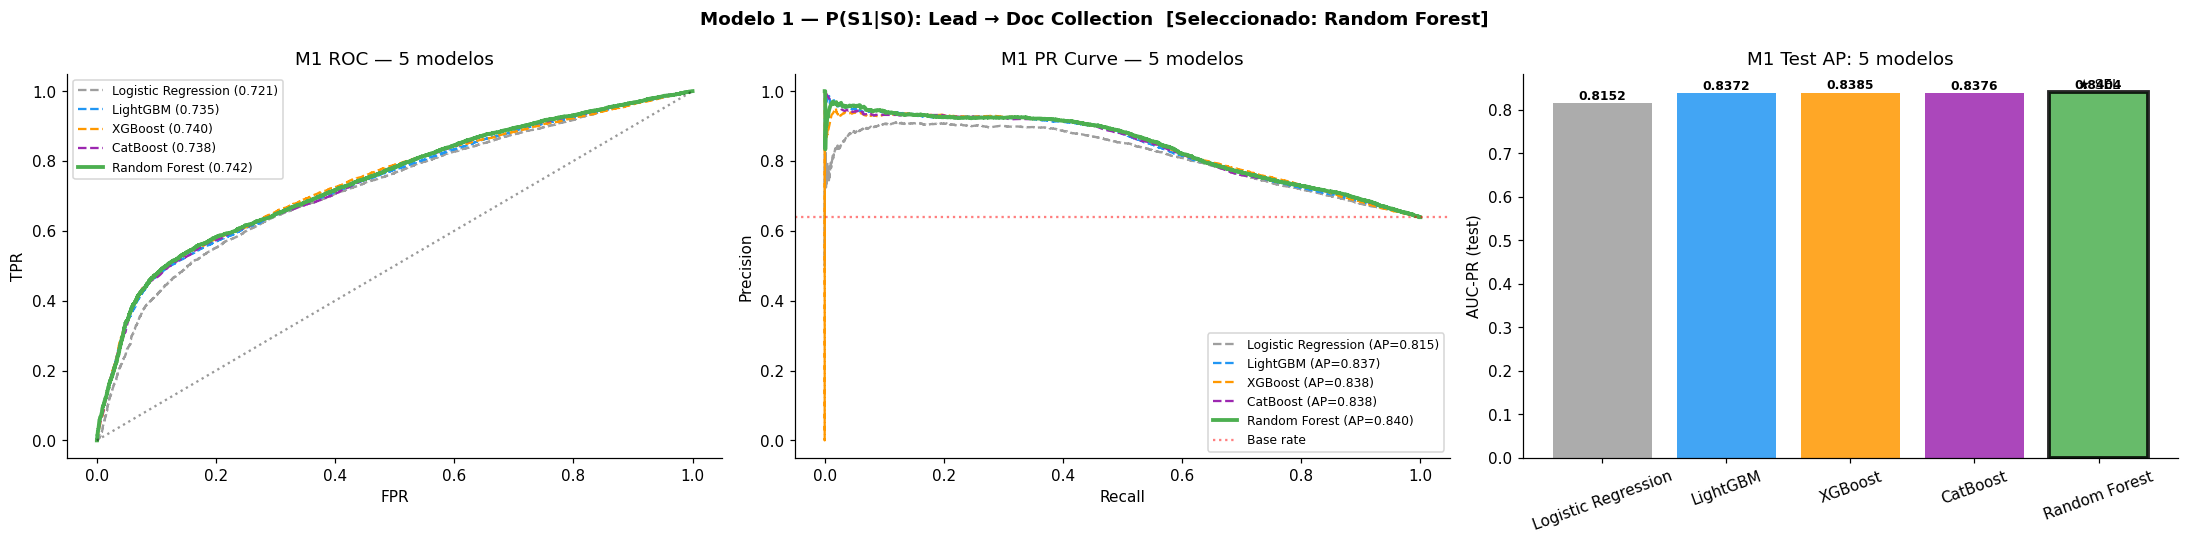


M1 benchmark: {'Logistic Regression': 0.8152, 'LightGBM': 0.8372, 'XGBoost': 0.8385, 'CatBoost': 0.8376, 'Random Forest': 0.8404}


In [21]:

# ── M1 Visualization — 5 modelos ─────────────────────────────────────────────
_m1_colors = {
    "Logistic Regression": "#9E9E9E",
    "LightGBM":            "#2196F3",
    "XGBoost":             "#FF9800",
    "CatBoost":            "#9C27B0",
    "Random Forest":       "#4CAF50",
}
_m1_preds_te = {
    "Logistic Regression": lr1_prob,
    "LightGBM":            p1_test,
    "XGBoost":             p1_xgb_te,
    "CatBoost":            p1_cb_te,
    "Random Forest":       p1_rf_te,
}

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# ROC
for name, p_te in _m1_preds_te.items():
    fpr_, tpr_, _ = roc_curve(y_te1, p_te)
    lw  = 2.5 if name == m1_type else 1.5
    ls  = "-" if name == m1_type else "--"
    axes[0].plot(fpr_, tpr_, lw=lw, ls=ls, color=_m1_colors[name],
                 label=f"{name} ({roc_auc_score(y_te1, p_te):.3f})")
axes[0].plot([0,1],[0,1],"k:",alpha=0.4)
axes[0].legend(fontsize=8); axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].set_title("M1 ROC — 5 modelos")

# PR curves
for name, p_te in _m1_preds_te.items():
    p_, r_, _ = precision_recall_curve(y_te1, p_te)
    lw  = 2.5 if name == m1_type else 1.5
    ls  = "-" if name == m1_type else "--"
    axes[1].plot(r_, p_, lw=lw, ls=ls, color=_m1_colors[name],
                 label=f"{name} (AP={average_precision_score(y_te1, p_te):.3f})")
axes[1].axhline(float(y_te1.mean()), color="red", ls=":", alpha=0.5, label="Base rate")
axes[1].legend(fontsize=8); axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("M1 PR Curve — 5 modelos")

# Bar chart: Test AP comparison
_m1_names = list(_m1_preds_te.keys())
_m1_aps   = [average_precision_score(y_te1, _m1_preds_te[n]) for n in _m1_names]
bar_clrs  = [_m1_colors[n] for n in _m1_names]
bars = axes[2].bar(_m1_names, _m1_aps, color=bar_clrs, alpha=0.85)
for b, ap in zip(bars, _m1_aps):
    axes[2].text(b.get_x() + b.get_width()/2, ap + 0.002,
                 f"{ap:.4f}", ha="center", va="bottom", fontsize=8, fontweight="bold")
axes[2].set_ylabel("AUC-PR (test)"); axes[2].set_title("M1 Test AP: 5 modelos")
axes[2].tick_params(axis="x", rotation=20)
# Mark selected model
sel_idx = _m1_names.index(m1_type)
bars[sel_idx].set_edgecolor("black"); bars[sel_idx].set_linewidth(2.5)
axes[2].text(sel_idx, _m1_aps[sel_idx] + 0.008, "★ SEL", ha="center", fontsize=9, color="black")

plt.suptitle(f"Modelo 1 — P(S1|S0): Lead → Doc Collection  [Seleccionado: {m1_type}]",
             fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()
print(f"\nM1 benchmark: {_m1_bench_df['Test AP'].to_dict()}")


---
## 9. Modelo 2 — M2: P(S2 | S1): Doc Collection → Hired

> **Pregunta:** ¿Este candidato (que ya completó doc collection) será contratado?
>
> Información disponible: datos de registro + velocidad durante doc collection.

In [22]:

print("=" * 62)
print("  MODELO 2 — P(S2|S1): Doc Collection → Hired")
print("  BENCHMARK: LogReg | LightGBM | XGBoost | CatBoost | RF")
print("  [M2 es el cuello de botella — benchmark prioritario]")
print("=" * 62)

X_tr2, y_tr2 = tr2[FEAT_T2], tr2["TARGET"]
X_va2, y_va2 = va2[FEAT_T2], va2["TARGET"]
X_te2, y_te2 = te2[FEAT_T2], te2["TARGET"]

print(f"  Train: {len(X_tr2):,} | Val: {len(X_va2):,} | Test: {len(X_te2):,}")
print(f"  Target rate train/val/test: {y_tr2.mean()*100:.1f}% / {y_va2.mean()*100:.1f}% / {y_te2.mean()*100:.1f}%")

# ── A. Logistic Regression ────────────────────────────────────────────────────
print("\n--- A. Logistic Regression ---")
scaler2   = StandardScaler()
lr2_model = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)
lr2_model.fit(scaler2.fit_transform(X_tr2.fillna(-999)), y_tr2)
lr2_prob_tr  = lr2_model.predict_proba(scaler2.transform(X_tr2.fillna(-999)))[:, 1]
lr2_prob_val = lr2_model.predict_proba(scaler2.transform(X_va2.fillna(-999)))[:, 1]
lr2_prob     = lr2_model.predict_proba(scaler2.transform(X_te2.fillna(-999)))[:, 1]
print(f"  LR M2 (val AP): {average_precision_score(y_va2, lr2_prob_val):.4f}")

# ── B. LightGBM ───────────────────────────────────────────────────────────────
print("\n--- B. LightGBM (Optuna 50 trials) ---")
bp2, study2 = run_optuna_lgb(X_tr2, y_tr2, X_va2, y_va2, n_trials=50, label="M2_LGB")
m2 = build_final_lgb(bp2, X_tr2, y_tr2, X_va2, y_va2)
p2_train = m2.predict_proba(X_tr2)[:, 1]
p2_val   = m2.predict_proba(X_va2)[:, 1]
p2_test  = m2.predict_proba(X_te2)[:, 1]

# ── C. XGBoost ────────────────────────────────────────────────────────────────
print("\n--- C. XGBoost (Optuna 40 trials) ---")
bp2_xgb = run_optuna_xgb(X_tr2, y_tr2, X_va2, y_va2, n_trials=40, label="M2_XGB")
m2_xgb  = build_final_xgb(bp2_xgb, X_tr2, y_tr2, X_va2, y_va2)
p2_xgb_tr  = m2_xgb.predict_proba(_arr(X_tr2))[:, 1]
p2_xgb_val = m2_xgb.predict_proba(_arr(X_va2))[:, 1]
p2_xgb_te  = m2_xgb.predict_proba(_arr(X_te2))[:, 1]

# ── D. CatBoost (label-encoded, sin cat_features explícito) ───────────────────
print("\n--- D. CatBoost (Optuna 40 trials, label-encoded) ---")
bp2_cb = run_optuna_catboost(X_tr2, y_tr2, X_va2, y_va2, n_trials=40, label="M2_CB")
m2_cb  = build_final_catboost(bp2_cb, X_tr2, y_tr2, X_va2, y_va2)
p2_cb_tr  = m2_cb.predict_proba(_arr(X_tr2))[:, 1]
p2_cb_val = m2_cb.predict_proba(_arr(X_va2))[:, 1]
p2_cb_te  = m2_cb.predict_proba(_arr(X_te2))[:, 1]

# ── E. Random Forest ──────────────────────────────────────────────────────────
print("\n--- E. Random Forest ---")
m2_rf     = build_rf(X_tr2, y_tr2)
p2_rf_tr  = m2_rf.predict_proba(_arr(X_tr2))[:, 1]
p2_rf_val = m2_rf.predict_proba(_arr(X_va2))[:, 1]
p2_rf_te  = m2_rf.predict_proba(_arr(X_te2))[:, 1]

# ── Overfitting check ─────────────────────────────────────────────────────────
print("\n=== Overfitting Check M2 ===")
check_overfitting(y_tr2, lr2_prob_tr,  y_va2, lr2_prob_val, y_te2, lr2_prob,    "LogReg")
check_overfitting(y_tr2, p2_train,     y_va2, p2_val,       y_te2, p2_test,     "LightGBM")
check_overfitting(y_tr2, p2_xgb_tr,   y_va2, p2_xgb_val,   y_te2, p2_xgb_te,  "XGBoost")
check_overfitting(y_tr2, p2_cb_tr,     y_va2, p2_cb_val,    y_te2, p2_cb_te,   "CatBoost")
check_overfitting(y_tr2, p2_rf_tr,     y_va2, p2_rf_val,    y_te2, p2_rf_te,   "RandomForest")

# ── Benchmark table ───────────────────────────────────────────────────────────
_m2_model_data = [
    ("Logistic Regression", lr2_prob_tr, lr2_prob_val, lr2_prob),
    ("LightGBM",            p2_train,    p2_val,        p2_test),
    ("XGBoost",             p2_xgb_tr,   p2_xgb_val,    p2_xgb_te),
    ("CatBoost",            p2_cb_tr,    p2_cb_val,     p2_cb_te),
    ("Random Forest",       p2_rf_tr,    p2_rf_val,     p2_rf_te),
]
_m2_bench_df = build_benchmark_table("M2 — P(S2|S1): Doc Collection → Hired  [CUELLO DE BOTELLA]",
                                     y_tr2, y_va2, y_te2, _m2_model_data)

# ── Model selection ───────────────────────────────────────────────────────────
print("\n=== Model Selection M2 ===")
_m2_probs_dict = {
    "Logistic Regression": (lr2_prob,    lr2_prob_val, lr2_prob_tr),
    "LightGBM":            (p2_test,     p2_val,       p2_train),
    "XGBoost":             (p2_xgb_te,   p2_xgb_val,   p2_xgb_tr),
    "CatBoost":            (p2_cb_te,    p2_cb_val,    p2_cb_tr),
    "Random Forest":       (p2_rf_te,    p2_rf_val,    p2_rf_tr),
}
m2_type, p2_best, p2_best_val = select_best_model_multi(_m2_probs_dict, y_te2, y_tr2)
print(f"\n  AP_test (selected M2): {average_precision_score(y_te2, p2_best):.4f}")
print(f"  P@10%: {precision_at_k(y_te2.values, p2_best, 0.10):.4f} | "
      f"Lift@10%: {lift_at_k(y_te2.values, p2_best, 0.10):.2f}x")
print(f"  P@20%: {precision_at_k(y_te2.values, p2_best, 0.20):.4f} | "
      f"Lift@20%: {lift_at_k(y_te2.values, p2_best, 0.20):.2f}x")


  MODELO 2 — P(S2|S1): Doc Collection → Hired
  BENCHMARK: LogReg | LightGBM | XGBoost | CatBoost | RF
  [M2 es el cuello de botella — benchmark prioritario]
  Train: 61,335 | Val: 14,942 | Test: 9,467
  Target rate train/val/test: 77.2% / 70.3% / 63.2%

--- A. Logistic Regression ---
  LR M2 (val AP): 0.7605

--- B. LightGBM (Optuna 50 trials) ---


  0%|          | 0/50 [00:00<?, ?it/s]

  → M2_LGB: best AUC-PR (val) = 0.8068

--- C. XGBoost (Optuna 40 trials) ---


  0%|          | 0/40 [00:00<?, ?it/s]

  → XGB M2_XGB: best AUC-PR (val) = 0.8093

--- D. CatBoost (Optuna 40 trials, label-encoded) ---


  0%|          | 0/40 [00:00<?, ?it/s]

  → CatBoost M2_CB: best AUC-PR (val) = 0.8116

--- E. Random Forest ---

=== Overfitting Check M2 ===
  LogReg        train=0.8521  val=0.7605  test=0.6745  gap=+0.1776  ⚠️ overfit
  LightGBM      train=0.8814  val=0.8266  test=0.7297  gap=+0.1518  ⚠️ overfit
  XGBoost       train=0.8619  val=0.8136  test=0.7184  gap=+0.1434  ⚠️ overfit
  CatBoost      train=0.8570  val=0.8111  test=0.7233  gap=+0.1337  ⚠️ overfit
  RandomForest  train=0.9048  val=0.7988  test=0.7122  gap=+0.1927  ⚠️ overfit

  BENCHMARK — M2 — P(S2|S1): Doc Collection → Hired  [CUELLO DE BOTELLA]
  Métrica principal: AUC-PR (Test AP). Penalización sobreajuste: −0.30×gap
                     Train AP  Val AP  Test AP  Gap train-test  AUC-ROC   Brier      F1  Recall    P@5%   P@10%   P@20%  Lift@5%  Lift@10%  Lift@20%        Comentario
Modelo                                                                                                                                                                
LightGBM           

In [23]:
# ══════════════════════════════════════════════════════════════════════════════
# DIAGNÓSTICO POST-FIX: Verificar que el censoring filter corrigió el drift
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 70)
print("  DIAGNÓSTICO: Target rate mensual en DS2 (S1→S2) — POST CENSORING")
print("=" * 70)

monthly = (ds_t2.groupby("_month_period")
           .agg(n=("TARGET","count"), hired=("TARGET","sum"))
           .assign(rate=lambda d: d["hired"]/d["n"]))
print(f"\n  Censoring buffer: {CENSORING_DAYS} días (P75 lead_to_hired)")
print(f"  Cutoff: leads creados hasta {CENSORING_CUTOFF.date()}\n")
print("  Mes         N leads    Hired    Rate")
print("  " + "-"*45)
for period, row in monthly.iterrows():
    marker = " ← TEST" if pd.Timestamp(period) > VAL_END else (
             " ← VAL" if pd.Timestamp(period) > TRAIN_END else "")
    print(f"  {period}   {row['n']:>7,.0f}   {row['hired']:>6,.0f}   {row['rate']*100:5.1f}%{marker}")

print(f"\n  Train mean: {y_tr2.mean()*100:.1f}%  |  Val mean: {y_va2.mean()*100:.1f}%  |  Test mean: {y_te2.mean()*100:.1f}%")
drift = (y_tr2.mean() - y_te2.mean()) * 100
print(f"  Drift train→test: {drift:+.1f} pp {'✅ < 10pp' if abs(drift) < 10 else '⚠️ > 10pp'}")

# Score distributions
print("\n  Distribución de probabilidades predichas en test:")
_probs = {
    "LogReg":    lr2_prob,
    "LightGBM":  p2_test,
    "XGBoost":   p2_xgb_te,
    "CatBoost":  p2_cb_te,
    "RF":        p2_rf_te,
}
for name, probs in _probs.items():
    pa = np.array(probs)
    print(f"    {name:12s}: mean={pa.mean():.3f}  median={np.median(pa):.3f}  "
          f"min={pa.min():.3f}  max={pa.max():.3f}  ≥0.5: {(pa >= 0.5).mean()*100:.1f}%")


  DIAGNÓSTICO: Target rate mensual en DS2 (S1→S2) — POST CENSORING

  Censoring buffer: 60 días (P75 lead_to_hired)
  Cutoff: leads creados hasta 2026-02-06

  Mes         N leads    Hired    Rate
  ---------------------------------------------
  2025-04     6,395    5,318    83.2%
  2025-05     8,555    7,371    86.2%
  2025-06    10,435    8,248    79.0%
  2025-07     9,427    6,690    71.0%
  2025-08     7,725    5,466    70.8%
  2025-09     9,533    7,100    74.5%
  2025-10     9,521    7,351    77.2%
  2025-11     8,262    5,937    71.9% ← VAL
  2025-12     6,483    4,444    68.5% ← VAL
  2026-01     7,842    5,016    64.0% ← TEST
  2026-02     1,566      918    58.6% ← TEST

  Train mean: 77.2%  |  Val mean: 70.3%  |  Test mean: 63.2%
  Drift train→test: +14.0 pp ⚠️ > 10pp

  Distribución de probabilidades predichas en test:
    LogReg      : mean=0.139  median=0.114  min=0.003  max=0.924  ≥0.5: 0.6%
    LightGBM    : mean=0.821  median=0.826  min=0.484  max=0.955  ≥0.5: 100.0%
 

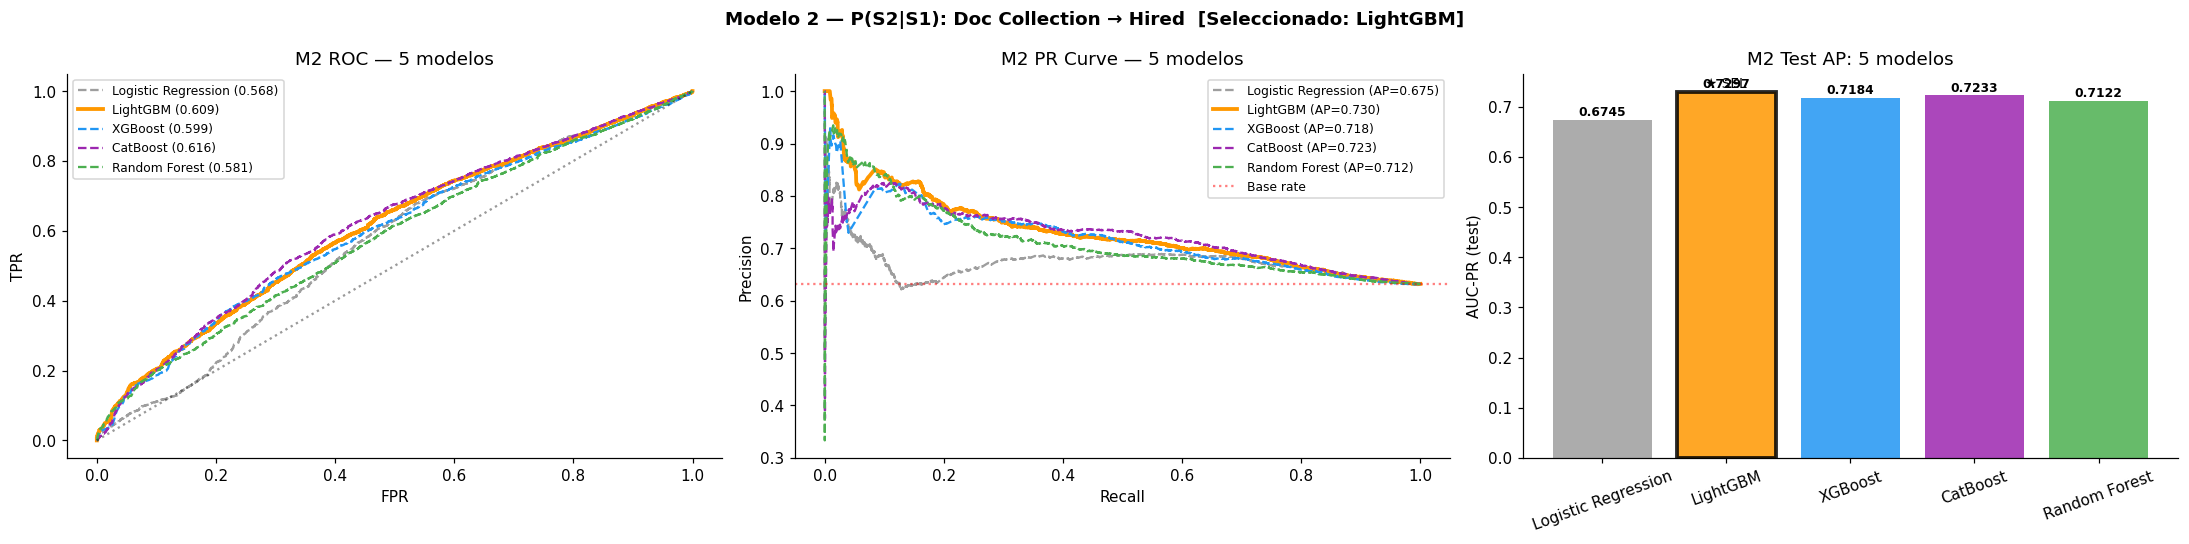


M2 benchmark: {'Logistic Regression': 0.6745, 'LightGBM': 0.7297, 'XGBoost': 0.7184, 'CatBoost': 0.7233, 'Random Forest': 0.7122}


In [24]:

# ── M2 Visualization — 5 modelos ─────────────────────────────────────────────
_m2_colors = {
    "Logistic Regression": "#9E9E9E",
    "LightGBM":            "#FF9800",
    "XGBoost":             "#2196F3",
    "CatBoost":            "#9C27B0",
    "Random Forest":       "#4CAF50",
}
_m2_preds_te = {
    "Logistic Regression": lr2_prob,
    "LightGBM":            p2_test,
    "XGBoost":             p2_xgb_te,
    "CatBoost":            p2_cb_te,
    "Random Forest":       p2_rf_te,
}

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# ROC
for name, p_te in _m2_preds_te.items():
    fpr_, tpr_, _ = roc_curve(y_te2, p_te)
    lw = 2.5 if name == m2_type else 1.5
    ls = "-" if name == m2_type else "--"
    axes[0].plot(fpr_, tpr_, lw=lw, ls=ls, color=_m2_colors[name],
                 label=f"{name} ({roc_auc_score(y_te2, p_te):.3f})")
axes[0].plot([0,1],[0,1],"k:",alpha=0.4)
axes[0].legend(fontsize=8); axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].set_title("M2 ROC — 5 modelos")

# PR curves
for name, p_te in _m2_preds_te.items():
    p_, r_, _ = precision_recall_curve(y_te2, p_te)
    lw = 2.5 if name == m2_type else 1.5
    ls = "-" if name == m2_type else "--"
    axes[1].plot(r_, p_, lw=lw, ls=ls, color=_m2_colors[name],
                 label=f"{name} (AP={average_precision_score(y_te2, p_te):.3f})")
axes[1].axhline(float(y_te2.mean()), color="red", ls=":", alpha=0.5, label="Base rate")
axes[1].legend(fontsize=8); axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("M2 PR Curve — 5 modelos")

# Bar chart: Test AP
_m2_names = list(_m2_preds_te.keys())
_m2_aps   = [average_precision_score(y_te2, _m2_preds_te[n]) for n in _m2_names]
bar_clrs2 = [_m2_colors[n] for n in _m2_names]
bars2 = axes[2].bar(_m2_names, _m2_aps, color=bar_clrs2, alpha=0.85)
for b, ap in zip(bars2, _m2_aps):
    axes[2].text(b.get_x() + b.get_width()/2, ap + 0.002,
                 f"{ap:.4f}", ha="center", va="bottom", fontsize=8, fontweight="bold")
axes[2].set_ylabel("AUC-PR (test)"); axes[2].set_title("M2 Test AP: 5 modelos")
axes[2].tick_params(axis="x", rotation=20)
sel_idx2 = _m2_names.index(m2_type)
bars2[sel_idx2].set_edgecolor("black"); bars2[sel_idx2].set_linewidth(2.5)
axes[2].text(sel_idx2, _m2_aps[sel_idx2] + 0.010, "★ SEL", ha="center",
             fontsize=9, color="black")

plt.suptitle(f"Modelo 2 — P(S2|S1): Doc Collection → Hired  [Seleccionado: {m2_type}]",
             fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()
print(f"\nM2 benchmark: {_m2_bench_df['Test AP'].to_dict()}")


---
## 10. Modelo 3 — M3: P(CFO | S2): Hired → CFO

> **Pregunta:** ¿Este rider recién contratado hará su primer pedido (CFO)?
>
> Información disponible: todo el historial del funnel + duración del proceso de contratación.

In [25]:

print("=" * 62)
print("  MODELO 3 — P(CFO|S2): Hired → CFO (First Order)")
print("  BENCHMARK: LogReg | LightGBM | XGBoost | CatBoost | RF")
print("=" * 62)

X_tr3, y_tr3 = tr3[FEAT_T3], tr3["TARGET"]
X_va3, y_va3 = va3[FEAT_T3], va3["TARGET"]
X_te3, y_te3 = te3[FEAT_T3], te3["TARGET"]

print(f"  Train: {len(X_tr3):,} | Val: {len(X_va3):,} | Test: {len(X_te3):,}")
print(f"  Target rate train/val/test: {y_tr3.mean()*100:.1f}% / {y_va3.mean()*100:.1f}% / {y_te3.mean()*100:.1f}%")

# ── A. Logistic Regression ────────────────────────────────────────────────────
print("\n--- A. Logistic Regression ---")
scaler3   = StandardScaler()
lr3_model = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)
lr3_model.fit(scaler3.fit_transform(X_tr3.fillna(-999)), y_tr3)
lr3_prob_tr  = lr3_model.predict_proba(scaler3.transform(X_tr3.fillna(-999)))[:, 1]
lr3_prob_val = lr3_model.predict_proba(scaler3.transform(X_va3.fillna(-999)))[:, 1]
lr3_prob     = lr3_model.predict_proba(scaler3.transform(X_te3.fillna(-999)))[:, 1]
print(f"  LR M3 (val AP): {average_precision_score(y_va3, lr3_prob_val):.4f}")

# ── B. LightGBM ───────────────────────────────────────────────────────────────
print("\n--- B. LightGBM (Optuna 50 trials) ---")
bp3, study3 = run_optuna_lgb(X_tr3, y_tr3, X_va3, y_va3, n_trials=50, label="M3_LGB")
m3 = build_final_lgb(bp3, X_tr3, y_tr3, X_va3, y_va3)
p3_train = m3.predict_proba(X_tr3)[:, 1]
p3_val   = m3.predict_proba(X_va3)[:, 1]
p3_test  = m3.predict_proba(X_te3)[:, 1]

# ── C. XGBoost ────────────────────────────────────────────────────────────────
print("\n--- C. XGBoost (Optuna 40 trials) ---")
bp3_xgb = run_optuna_xgb(X_tr3, y_tr3, X_va3, y_va3, n_trials=40, label="M3_XGB")
m3_xgb  = build_final_xgb(bp3_xgb, X_tr3, y_tr3, X_va3, y_va3)
p3_xgb_tr  = m3_xgb.predict_proba(_arr(X_tr3))[:, 1]
p3_xgb_val = m3_xgb.predict_proba(_arr(X_va3))[:, 1]
p3_xgb_te  = m3_xgb.predict_proba(_arr(X_te3))[:, 1]

# ── D. CatBoost (label-encoded, sin cat_features explícito) ───────────────────
print("\n--- D. CatBoost (Optuna 40 trials, label-encoded) ---")
bp3_cb = run_optuna_catboost(X_tr3, y_tr3, X_va3, y_va3, n_trials=40, label="M3_CB")
m3_cb  = build_final_catboost(bp3_cb, X_tr3, y_tr3, X_va3, y_va3)
p3_cb_tr  = m3_cb.predict_proba(_arr(X_tr3))[:, 1]
p3_cb_val = m3_cb.predict_proba(_arr(X_va3))[:, 1]
p3_cb_te  = m3_cb.predict_proba(_arr(X_te3))[:, 1]

# ── E. Random Forest ──────────────────────────────────────────────────────────
print("\n--- E. Random Forest ---")
m3_rf     = build_rf(X_tr3, y_tr3)
p3_rf_tr  = m3_rf.predict_proba(_arr(X_tr3))[:, 1]
p3_rf_val = m3_rf.predict_proba(_arr(X_va3))[:, 1]
p3_rf_te  = m3_rf.predict_proba(_arr(X_te3))[:, 1]

# ── Overfitting check ─────────────────────────────────────────────────────────
print("\n=== Overfitting Check M3 ===")
check_overfitting(y_tr3, lr3_prob_tr,  y_va3, lr3_prob_val, y_te3, lr3_prob,    "LogReg")
check_overfitting(y_tr3, p3_train,     y_va3, p3_val,       y_te3, p3_test,     "LightGBM")
check_overfitting(y_tr3, p3_xgb_tr,   y_va3, p3_xgb_val,   y_te3, p3_xgb_te,  "XGBoost")
check_overfitting(y_tr3, p3_cb_tr,     y_va3, p3_cb_val,    y_te3, p3_cb_te,   "CatBoost")
check_overfitting(y_tr3, p3_rf_tr,     y_va3, p3_rf_val,    y_te3, p3_rf_te,   "RandomForest")

# ── Benchmark table ───────────────────────────────────────────────────────────
_m3_model_data = [
    ("Logistic Regression", lr3_prob_tr, lr3_prob_val, lr3_prob),
    ("LightGBM",            p3_train,    p3_val,        p3_test),
    ("XGBoost",             p3_xgb_tr,   p3_xgb_val,    p3_xgb_te),
    ("CatBoost",            p3_cb_tr,    p3_cb_val,     p3_cb_te),
    ("Random Forest",       p3_rf_tr,    p3_rf_val,     p3_rf_te),
]
_m3_bench_df = build_benchmark_table("M3 — P(CFO|S2): Hired → CFO (First Order)",
                                     y_tr3, y_va3, y_te3, _m3_model_data)

# ── Model selection ───────────────────────────────────────────────────────────
print("\n=== Model Selection M3 ===")
_m3_probs_dict = {
    "Logistic Regression": (lr3_prob,    lr3_prob_val, lr3_prob_tr),
    "LightGBM":            (p3_test,     p3_val,       p3_train),
    "XGBoost":             (p3_xgb_te,   p3_xgb_val,   p3_xgb_tr),
    "CatBoost":            (p3_cb_te,    p3_cb_val,    p3_cb_tr),
    "Random Forest":       (p3_rf_te,    p3_rf_val,    p3_rf_tr),
}
m3_type, p3_best, p3_best_val = select_best_model_multi(_m3_probs_dict, y_te3, y_tr3)
print(f"\n  AP_test (selected M3): {average_precision_score(y_te3, p3_best):.4f}")
print(f"  P@10%: {precision_at_k(y_te3.values, p3_best, 0.10):.4f} | "
      f"Lift@10%: {lift_at_k(y_te3.values, p3_best, 0.10):.2f}x")


  MODELO 3 — P(CFO|S2): Hired → CFO (First Order)
  BENCHMARK: LogReg | LightGBM | XGBoost | CatBoost | RF
  Train: 47,366 | Val: 10,510 | Test: 5,983
  Target rate train/val/test: 56.6% / 61.1% / 57.8%

--- A. Logistic Regression ---
  LR M3 (val AP): 0.6818

--- B. LightGBM (Optuna 50 trials) ---


  0%|          | 0/50 [00:00<?, ?it/s]

  → M3_LGB: best AUC-PR (val) = 0.7014

--- C. XGBoost (Optuna 40 trials) ---


  0%|          | 0/40 [00:00<?, ?it/s]

  → XGB M3_XGB: best AUC-PR (val) = 0.7041

--- D. CatBoost (Optuna 40 trials, label-encoded) ---


  0%|          | 0/40 [00:00<?, ?it/s]

  → CatBoost M3_CB: best AUC-PR (val) = 0.6999

--- E. Random Forest ---

=== Overfitting Check M3 ===
  LogReg        train=0.6954  val=0.6818  test=0.6630  gap=+0.0324  ✅ OK
  LightGBM      train=0.7451  val=0.7286  test=0.6812  gap=+0.0639  ⚠️ overfit
  XGBoost       train=0.7334  val=0.7234  test=0.6830  gap=+0.0504  ⚠️ overfit
  CatBoost      train=0.6530  val=0.6486  test=0.6007  gap=+0.0524  ⚠️ overfit
  RandomForest  train=0.7829  val=0.6981  test=0.6723  gap=+0.1106  ⚠️ overfit

  BENCHMARK — M3 — P(CFO|S2): Hired → CFO (First Order)
  Métrica principal: AUC-PR (Test AP). Penalización sobreajuste: −0.30×gap
                     Train AP  Val AP  Test AP  Gap train-test  AUC-ROC   Brier      F1  Recall    P@5%   P@10%   P@20%  Lift@5%  Lift@10%  Lift@20%                           Comentario
Modelo                                                                                                                                                                                   
XGBo

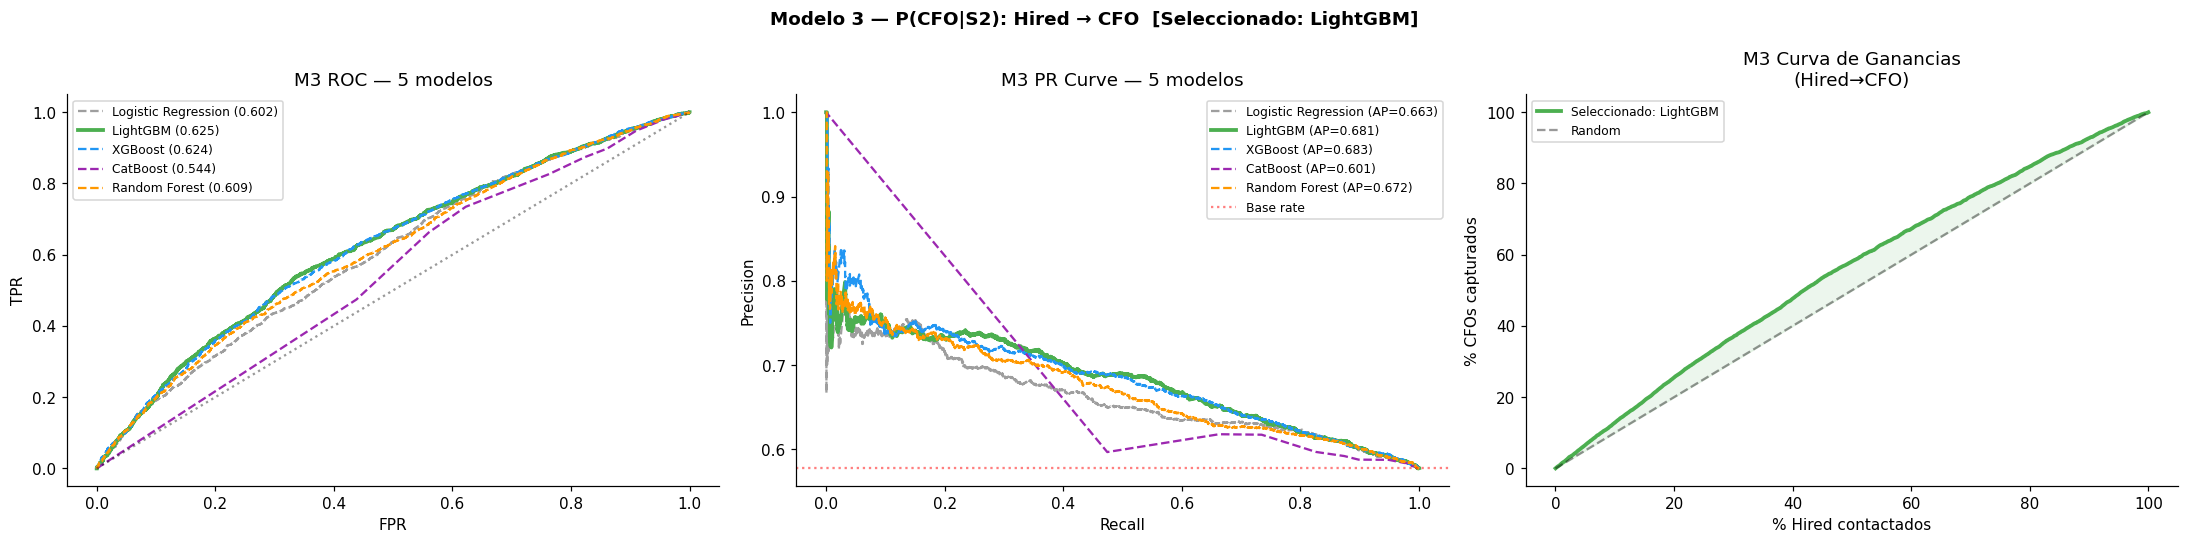


M3 benchmark: {'Logistic Regression': 0.663, 'LightGBM': 0.6812, 'XGBoost': 0.683, 'CatBoost': 0.6007, 'Random Forest': 0.6723}

  RESUMEN EJECUTIVO — MEJOR MODELO POR TRANSICIÓN
  M1 P(S1|S0)    : [Random Forest         ]  AP=0.8404  Gap=-0.0418  P@10%=0.9325  Lift@10%=1.46x
  M2 P(S2|S1)    : [LightGBM              ]  AP=0.7297  Gap=+0.1518  P@10%=0.8203  Lift@10%=1.30x
  M3 P(CFO|S2)   : [LightGBM              ]  AP=0.6812  Gap=+0.0639  P@10%=0.7408  Lift@10%=1.28x


In [26]:

# ── M3 Visualization — 5 modelos ─────────────────────────────────────────────
_m3_colors = {
    "Logistic Regression": "#9E9E9E",
    "LightGBM":            "#4CAF50",
    "XGBoost":             "#2196F3",
    "CatBoost":            "#9C27B0",
    "Random Forest":       "#FF9800",
}
_m3_preds_te = {
    "Logistic Regression": lr3_prob,
    "LightGBM":            p3_test,
    "XGBoost":             p3_xgb_te,
    "CatBoost":            p3_cb_te,
    "Random Forest":       p3_rf_te,
}

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# ROC
for name, p_te in _m3_preds_te.items():
    fpr_, tpr_, _ = roc_curve(y_te3, p_te)
    lw = 2.5 if name == m3_type else 1.5
    ls = "-" if name == m3_type else "--"
    axes[0].plot(fpr_, tpr_, lw=lw, ls=ls, color=_m3_colors[name],
                 label=f"{name} ({roc_auc_score(y_te3, p_te):.3f})")
axes[0].plot([0,1],[0,1],"k:",alpha=0.4)
axes[0].legend(fontsize=8); axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].set_title("M3 ROC — 5 modelos")

# PR curves
for name, p_te in _m3_preds_te.items():
    p_, r_, _ = precision_recall_curve(y_te3, p_te)
    lw = 2.5 if name == m3_type else 1.5
    ls = "-" if name == m3_type else "--"
    axes[1].plot(r_, p_, lw=lw, ls=ls, color=_m3_colors[name],
                 label=f"{name} (AP={average_precision_score(y_te3, p_te):.3f})")
axes[1].axhline(float(y_te3.mean()), color="red", ls=":", alpha=0.5, label="Base rate")
axes[1].legend(fontsize=8); axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("M3 PR Curve — 5 modelos")

# Curva de ganancias del modelo seleccionado
idx_s = np.argsort(p3_best)[::-1]
y_s   = np.array(y_te3)[idx_s]
cum_gains = np.cumsum(y_s) / max(y_s.sum(), 1)
pct_pop   = np.arange(1, len(y_s)+1) / len(y_s)
axes[2].plot(pct_pop*100, cum_gains*100, lw=2.5,
             color=_m3_colors.get(m3_type, "#4CAF50"),
             label=f"Seleccionado: {m3_type}")
axes[2].plot([0,100],[0,100],"k--",alpha=0.4, label="Random")
axes[2].fill_between(pct_pop*100, cum_gains*100, pct_pop*100, alpha=0.1,
                     color=_m3_colors.get(m3_type, "#4CAF50"))
axes[2].set_xlabel("% Hired contactados"); axes[2].set_ylabel("% CFOs capturados")
axes[2].set_title(f"M3 Curva de Ganancias\n(Hired→CFO)")
axes[2].legend(fontsize=8)

plt.suptitle(f"Modelo 3 — P(CFO|S2): Hired → CFO  [Seleccionado: {m3_type}]",
             fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()
print(f"\nM3 benchmark: {_m3_bench_df['Test AP'].to_dict()}")

# ── Resumen ejecutivo: mejores modelos por transición ─────────────────────────
print("\n" + "="*62)
print("  RESUMEN EJECUTIVO — MEJOR MODELO POR TRANSICIÓN")
print("="*62)
for trans, mtype, bench in [
    ("M1 P(S1|S0)", m1_type, _m1_bench_df),
    ("M2 P(S2|S1)", m2_type, _m2_bench_df),
    ("M3 P(CFO|S2)", m3_type, _m3_bench_df),
]:
    ap = bench.loc[mtype, "Test AP"] if mtype in bench.index else float("nan")
    gap = bench.loc[mtype, "Gap train-test"] if mtype in bench.index else float("nan")
    p10 = bench.loc[mtype, "P@10%"] if mtype in bench.index else float("nan")
    l10 = bench.loc[mtype, "Lift@10%"] if mtype in bench.index else float("nan")
    print(f"  {trans:15s}: [{mtype:22s}]  AP={ap:.4f}  Gap={gap:+.4f}  "
          f"P@10%={p10:.4f}  Lift@10%={l10:.2f}x")


---
## 11. Composición de Probabilidades

$$P(\text{CFO}) = P(S_1|S_0) \times P(S_2|S_1) \times P(\text{CFO}|S_2)$$

Para leads que no han llegado a S1 o S2, se usan las probabilidades medias del train
como proxy (marginalización sobre leads no-observados).

---
## 10b. Modelos de Fallback — P(S2|S0), P(CFO|S1), P(CFO|S0)

Para leads que aún no han avanzado en el funnel, en lugar de usar medias globales se
entrenan **modelos de fallback** simples (Logistic Regression, rápidos y robustos):

| Modelo | Input | Target | Uso |
|---|---|---|---|
| `m_s2s0` | Feats S0 | `reached_s2` | Lead no en S1 → estima P(eventualmente llega a S2) |
| `m_cfos1` | Feats T2 | `is_cfo` | Lead en S1 no en S2 → estima P(eventualmente CFO) |
| `m_cfos0` | Feats S0 | `is_cfo` | Lead no en S1 → estima P(eventualmente CFO) |


In [27]:
# ── Fallback Models: Option A — mini-LR para leads sin info de etapas posteriores ──
print("=" * 62)
print("  FALLBACK MODELS — P(S2|S0), P(CFO|S1), P(CFO|S0)")
print("=" * 62)

# M_s2s0: P(eventually reach S2 | S0) — for leads not yet in S1
scaler_fb1 = StandardScaler()
m_s2s0 = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)
m_s2s0.fit(scaler_fb1.fit_transform(tr1[FEAT_T1].fillna(-999)), tr1["reached_s2"])
fb_p_s2s0_te = m_s2s0.predict_proba(scaler_fb1.transform(te1[FEAT_T1].fillna(-999)))[:, 1]
ap_s2s0 = average_precision_score(te1["reached_s2"].values, fb_p_s2s0_te)
print(f"  m_s2s0  (P(S2|S0)):  AUC-PR test = {ap_s2s0:.4f}")

# M_cfos0: P(eventually reach CFO | S0) — direct path from S0
scaler_fb3 = StandardScaler()
m_cfos0 = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)
m_cfos0.fit(scaler_fb3.fit_transform(tr1[FEAT_T1].fillna(-999)), tr1["is_cfo"])
fb_p_cfos0_te = m_cfos0.predict_proba(scaler_fb3.transform(te1[FEAT_T1].fillna(-999)))[:, 1]
ap_cfos0 = average_precision_score(te1["is_cfo"].values, fb_p_cfos0_te)
print(f"  m_cfos0 (P(CFO|S0)): AUC-PR test = {ap_cfos0:.4f}")

# M_cfos1: P(eventually reach CFO | S1) — for S1 leads not yet hired
scaler_fb2 = StandardScaler()
m_cfos1 = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)
m_cfos1.fit(scaler_fb2.fit_transform(tr2[FEAT_T2].fillna(-999)), tr2["is_cfo"])
fb_p_cfos1_te = m_cfos1.predict_proba(scaler_fb2.transform(te2[FEAT_T2].fillna(-999)))[:, 1]
ap_cfos1 = average_precision_score(te2["is_cfo"].values, fb_p_cfos1_te)
print(f"  m_cfos1 (P(CFO|S1)): AUC-PR test = {ap_cfos1:.4f}")

print("\n  Fallback strategy summary:")
print("  Lead @ S0 (no S1 info)   → P(CFO) = m_cfos0 score")
print("  Lead @ S1 (no S2 info)   → P(CFO) = p(S1|S0) × m_cfos1 score")
print("  Lead @ S2 (all info)     → P(CFO) = M1 × M2 × M3 (full decomposition)")


  FALLBACK MODELS — P(S2|S0), P(CFO|S1), P(CFO|S0)
  m_s2s0  (P(S2|S0)):  AUC-PR test = 0.5827
  m_cfos0 (P(CFO|S0)): AUC-PR test = 0.3325
  m_cfos1 (P(CFO|S1)): AUC-PR test = 0.4083

  Fallback strategy summary:
  Lead @ S0 (no S1 info)   → P(CFO) = m_cfos0 score
  Lead @ S1 (no S2 info)   → P(CFO) = p(S1|S0) × m_cfos1 score
  Lead @ S2 (all info)     → P(CFO) = M1 × M2 × M3 (full decomposition)


In [28]:
# ── Build scoring table for ALL test leads (base: T1 / S0 perspective) ────────
score_df = te1[["applicant_id","created_at","_month_period",
                "city_group","source","is_cfo",
                "reached_s1","reached_s2"]].copy()

# M1 scores all leads
score_df["p_s1_s0"] = p1_best  # use selected model (LGB or LogReg)

# ── M2/M3 scores via fallback model (Option A) ────────────────────────────────
# Global means (kept for reference / edge cases)
global_p2 = float(p2_train.mean())
global_p3 = float(p3_train.mean())

# Map M2 and M3 scores to full-test index
t2_score_map = pd.Series(p2_best, index=te2.index)
t3_score_map = pd.Series(p3_best, index=te3.index)

# Conditional fallback means from train (by city×source — much better than global)
_fb_p2 = (tr2.assign(TARGET=tr2["TARGET"])
             .groupby(["city_group","source"])["TARGET"].mean())
_fb_p3 = (tr3.assign(TARGET=tr3["TARGET"])
             .groupby(["city_group","source"])["TARGET"].mean())

def cond_fallback(row_idx_series, city_s, src_s, score_map, cond_dict, global_val):
    # Use score_map if available, else conditional mean, else global.
    result = row_idx_series.map(score_map)
    mask_na = result.isna()
    if mask_na.any():
        keys = list(zip(city_s[mask_na], src_s[mask_na]))
        cond_vals = [cond_dict.get(k, global_val) for k in keys]
        result.loc[mask_na] = cond_vals
    return result.values

score_df["p_s2_s1"]  = cond_fallback(
    pd.Series(score_df.index, index=score_df.index),
    score_df["city_group"], score_df["source"],
    t2_score_map, _fb_p2.to_dict(), global_p2)

score_df["p_cfo_s2"] = cond_fallback(
    pd.Series(score_df.index, index=score_df.index),
    score_df["city_group"], score_df["source"],
    t3_score_map, _fb_p3.to_dict(), global_p3)

# ── Alternative: direct fallback model (cfos0) for leads not in S1 ────────────
in_s1 = score_df.index.isin(te2.index)
in_s2 = score_df.index.isin(te3.index)

score_df["p_cfo_fallback"] = np.where(
    in_s2,
    score_df["p_s1_s0"] * score_df["p_s2_s1"] * score_df["p_cfo_s2"],  # full decomp
    np.where(
        in_s1,
        score_df["p_s1_s0"] * pd.Series(fb_p_cfos1_te, index=te2.index).reindex(score_df.index).fillna(global_p3).values,
        fb_p_cfos0_te,  # direct P(CFO|S0) for leads not in S1
    )
)

# ── Composed probability (standard decomposition) ─────────────────────────────
score_df["p_cfo_composed"] = (
    score_df["p_s1_s0"] * score_df["p_s2_s1"] * score_df["p_cfo_s2"]
)

print("=== Scoring table built for test set ===")
print(f"Leads: {len(score_df):,}  (S1: {in_s1.sum():,} | S2: {in_s2.sum():,} | S0-only: {(~in_s1).sum():,})")
print(f"\nScore statistics:")
for col in ["p_s1_s0","p_s2_s1","p_cfo_s2","p_cfo_composed","p_cfo_fallback"]:
    s = score_df[col]
    print(f"  {col:22s}: mean={s.mean():.4f}  std={s.std():.4f}")
print(f"\nActual CFO rate in test: {score_df['is_cfo'].mean()*100:.2f}%")
print(f"Mean P(CFO) composed:    {score_df['p_cfo_composed'].mean()*100:.2f}%")
print(f"Mean P(CFO) fallback:    {score_df['p_cfo_fallback'].mean()*100:.2f}%")


=== Scoring table built for test set ===
Leads: 14,814  (S1: 9,467 | S2: 5,983 | S0-only: 5,347)

Score statistics:
  p_s1_s0               : mean=0.5527  std=0.1765
  p_s2_s1               : mean=0.7944  std=0.0802
  p_cfo_s2              : mean=0.5582  std=0.1062
  p_cfo_composed        : mean=0.2600  std=0.1340
  p_cfo_fallback        : mean=0.2288  std=0.1415

Actual CFO rate in test: 23.33%
Mean P(CFO) composed:    26.00%
Mean P(CFO) fallback:    22.88%


=== Evaluación Probabilidad Compuesta vs Fallback vs Single-Stage (test) ===
                                      AUC-PR  AUC-ROC      F1  Recall   Brier  Threshold
Model                                                                                   
Constante                             0.2333   0.5000  0.3783  1.0000  0.1789      0.233
Solo M1: P(S1|S0)                     0.3639   0.6717  0.4529  0.5590  0.2738      0.601
Compuesta: M1×M2×M3 (cond. fallback)  0.4142   0.7096  0.4798  0.6236  0.1620      0.270
Fallback directo (cfos0/cfos1/M3)     0.4891   0.7891  0.5420  0.7708  0.1488      0.209
Direct P(CFO|S0)                      0.3325   0.6468  0.4244  0.6635  0.1764      0.151

=== Precision@K y Lift@K ===
 Corte    Compuesta    Fallback    Solo M1   Lift Comp
    5%       0.5419      0.6568     0.4595       2.32x
   10%       0.4848      0.5645     0.4207       2.08x
   20%       0.4294      0.5172     0.3842       1.84x
   30%       0.4100      0.4613     0.3864       1

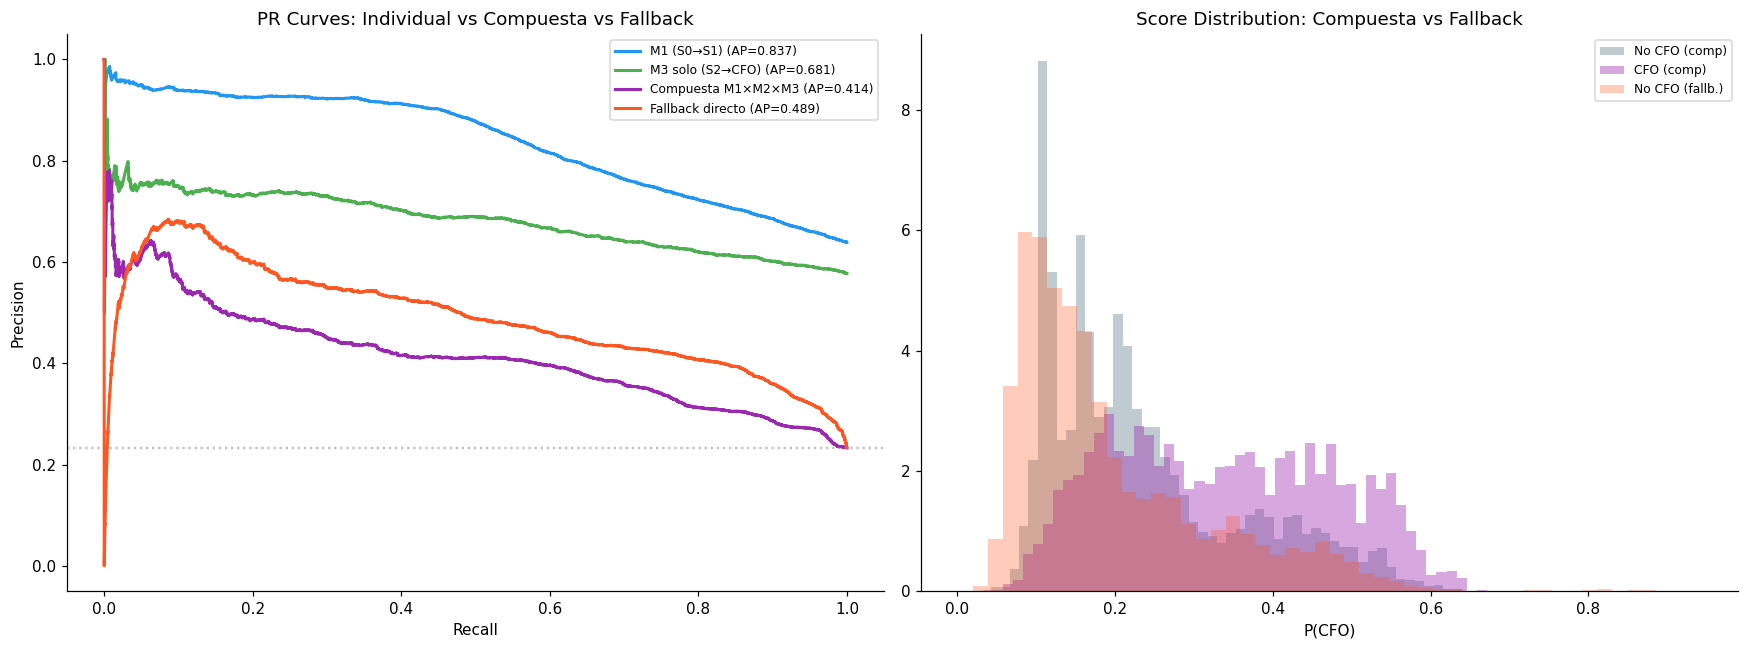

In [29]:
# ── Evaluate composed probability + fallback ─────────────────────────────────
y_true_all = score_df["is_cfo"].values
y_comp     = score_df["p_cfo_composed"].values
y_fallback = score_df["p_cfo_fallback"].values
y_t1_only  = score_df["p_s1_s0"].values

print("=== Evaluación Probabilidad Compuesta vs Fallback vs Single-Stage (test) ===")
res_comp = [
    evaluate_binary(y_true_all, np.full(len(y_true_all), score_df["is_cfo"].mean()), "Constante"),
    evaluate_binary(y_true_all, y_t1_only,  "Solo M1: P(S1|S0)"),
    evaluate_binary(y_true_all, y_comp,     "Compuesta: M1×M2×M3 (cond. fallback)"),
    evaluate_binary(y_true_all, y_fallback, "Fallback directo (cfos0/cfos1/M3)"),
    evaluate_binary(y_true_all, fb_p_cfos0_te, "Direct P(CFO|S0)"),
]
print(pd.DataFrame(res_comp).set_index("Model").to_string())

print("\n=== Precision@K y Lift@K ===")
print(f"{'Corte':>6}  {'Compuesta':>11}  {'Fallback':>10}  {'Solo M1':>9}  {'Lift Comp':>10}")
for k in [0.05, 0.10, 0.20, 0.30]:
    pc = precision_at_k(y_true_all, y_comp, k)
    pf = precision_at_k(y_true_all, y_fallback, k)
    pt = precision_at_k(y_true_all, y_t1_only, k)
    lc = lift_at_k(y_true_all, y_comp, k)
    print(f"{int(k*100):>5}%  {pc:>11.4f}  {pf:>10.4f}  {pt:>9.4f}  {lc:>9.2f}x")

# PR curves comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for (yt_, yp_, label, color) in [
    (y_te1.values, p1_test,    "M1 (S0→S1)",              "#2196F3"),
    (y_te3.values, p3_test,    "M3 solo (S2→CFO)",        "#4CAF50"),
    (y_true_all,   y_comp,     "Compuesta M1×M2×M3",      "#9C27B0"),
    (y_true_all,   y_fallback, "Fallback directo",         "#FF5722"),
]:
    p_, r_, _ = precision_recall_curve(yt_, yp_)
    axes[0].plot(r_, p_, lw=2, label=f"{label} (AP={average_precision_score(yt_, yp_):.3f})", color=color)
axes[0].axhline(float(y_true_all.mean()), ls=":", color="gray", alpha=0.5)
axes[0].set_title("PR Curves: Individual vs Compuesta vs Fallback")
axes[0].legend(fontsize=8); axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")

axes[1].hist(y_comp[y_true_all==0],    bins=50, alpha=0.4, density=True, color="#607D8B", label="No CFO (comp)")
axes[1].hist(y_comp[y_true_all==1],    bins=50, alpha=0.4, density=True, color="#9C27B0", label="CFO (comp)")
axes[1].hist(y_fallback[y_true_all==0],bins=50, alpha=0.3, density=True, color="#FF5722", label="No CFO (fallb.)", linestyle="--")
axes[1].set_title("Score Distribution: Compuesta vs Fallback")
axes[1].set_xlabel("P(CFO)"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()


---\n## 12. Calibración de los Modelos\n\nUn modelo bien calibrado tiene sus probabilidades alineadas con las frecuencias reales.\nEvaluamos con curva de calibración y Brier Score. Aplicamos **Platt scaling** donde sea necesario.

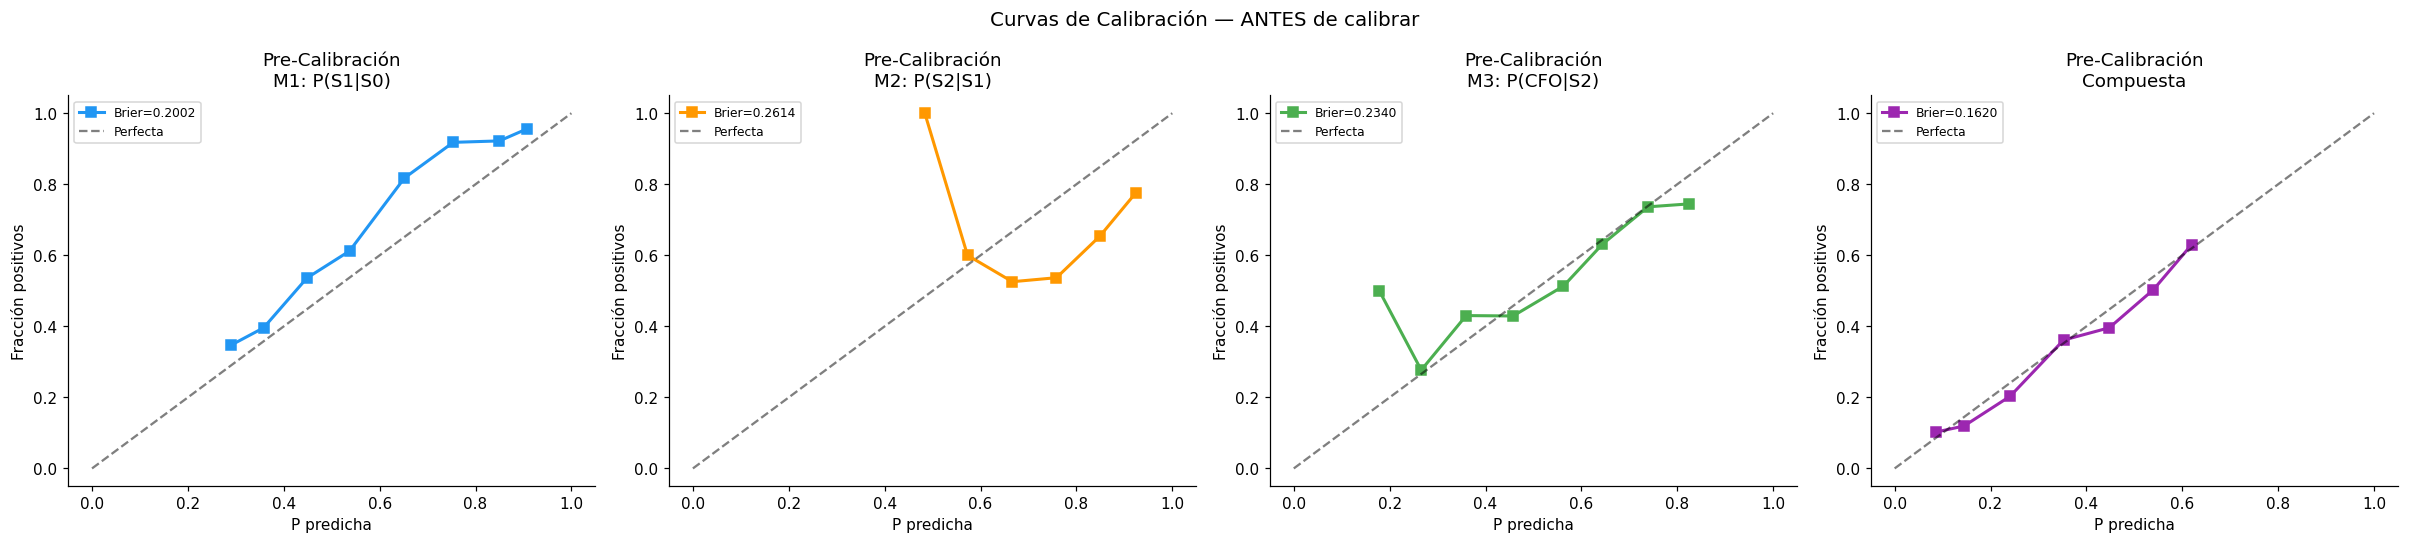

=== Calibración: Platt Scaling vs Isotonic Regression ===

  Modelos seleccionados: M1=[Random Forest]  M2=[LightGBM]  M3=[LightGBM]

  M1: raw=0.20017 → Platt=0.19266  ISO=0.19277  → mejor: Platt (Δ=+0.00751)
  M2: raw=0.26145 → Platt=0.25857  ISO=0.26008  → mejor: Platt (Δ=+0.00288)
  M3: raw=0.23396 → Platt=0.23477  ISO=0.23563  → mejor: Platt (Δ=-0.00081)

=== Resumen de Calibración ===
        Brier_raw  Brier_Platt  Brier_ISO   Best   Δ_best
Modelo                                                   
M1        0.20017      0.19266    0.19277  Platt  0.00751
M2        0.26145      0.25857    0.26008  Platt  0.00288
M3        0.23396      0.23477    0.23563  Platt -0.00081


In [30]:

# ── Calibration curves: PRE-calibration ──────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
cal_entries = [
    (y_te1.values, p1_best, "#2196F3", "M1: P(S1|S0)"),
    (y_te2.values, p2_best, "#FF9800", "M2: P(S2|S1)"),
    (y_te3.values, p3_best, "#4CAF50", "M3: P(CFO|S2)"),
    (y_true_all,   y_comp,  "#9C27B0", "Compuesta"),
]
cal_results = []
for ax, (yt, yp, color, label) in zip(axes, cal_entries):
    fop, mpv = calibration_curve(yt, yp, n_bins=10, strategy="uniform")
    brier    = brier_score_loss(yt, yp)
    ax.plot(mpv, fop, "s-", lw=2, color=color, label=f"Brier={brier:.4f}")
    ax.plot([0,1],[0,1],"k--",alpha=0.5,label="Perfecta")
    ax.set_title(f"Pre-Calibración\n{label}"); ax.legend(fontsize=8)
    ax.set_xlabel("P predicha"); ax.set_ylabel("Fracción positivos")
    cal_results.append({"Modelo": label, "Brier_raw": brier,
                        "AUC-PR": round(average_precision_score(yt, yp), 4)})
plt.suptitle("Curvas de Calibración — ANTES de calibrar", fontsize=13)
plt.tight_layout(); plt.show()

# ── Platt Scaling ─────────────────────────────────────────────────────────────
def platt_scale(y_cal, p_cal, p_apply):
    eps = 1e-7
    lo_cal   = np.log(np.clip(p_cal,   eps, 1-eps) / (1 - np.clip(p_cal,   eps, 1-eps)))
    lo_apply = np.log(np.clip(p_apply, eps, 1-eps) / (1 - np.clip(p_apply, eps, 1-eps)))
    lr_c = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    lr_c.fit(lo_cal.reshape(-1,1), y_cal)
    return lr_c.predict_proba(lo_apply.reshape(-1,1))[:, 1]

# ── Isotonic Regression ───────────────────────────────────────────────────────
def isotonic_scale(y_cal, p_cal, p_apply):
    ir = IsoReg(out_of_bounds="clip")
    ir.fit(p_cal, y_cal)
    return ir.predict(p_apply)

# ── Calibrate each model on its validation set (both methods) ─────────────────
# p_best_val: validation-set probabilities for the selected model (any algorithm)
# This is used for calibration regardless of which model type was selected.
print("=== Calibración: Platt Scaling vs Isotonic Regression ===\n")
print(f"  Modelos seleccionados: M1=[{m1_type}]  M2=[{m2_type}]  M3=[{m3_type}]")
print()

_val_preds = [
    (y_va1.values, np.asarray(p1_best_val), y_te1.values, np.asarray(p1_best), "M1"),
    (y_va2.values, np.asarray(p2_best_val), y_te2.values, np.asarray(p2_best), "M2"),
    (y_va3.values, np.asarray(p3_best_val), y_te3.values, np.asarray(p3_best), "M3"),
]

cal_detail = []
p_final = {}  # best calibrated probabilities per model key

for (y_val, p_val, y_test, p_test, mname) in _val_preds:
    p_platt    = platt_scale(y_val, p_val, p_test)
    p_iso      = isotonic_scale(y_val, p_val, p_test)
    b_raw      = brier_score_loss(y_test, p_test)
    b_platt    = brier_score_loss(y_test, p_platt)
    b_iso      = brier_score_loss(y_test, p_iso)
    # Select best calibration method
    best_b     = min(b_platt, b_iso)
    best_name  = "Platt" if b_platt <= b_iso else "Isotonic"
    p_final[mname] = p_platt if best_name == "Platt" else p_iso
    cal_detail.append({
        "Modelo": mname, "Brier_raw": round(b_raw,5),
        "Brier_Platt": round(b_platt,5), "Brier_ISO": round(b_iso,5),
        "Best": best_name, "Δ_best": round(b_raw - best_b, 5),
    })
    print(f"  {mname}: raw={b_raw:.5f} → Platt={b_platt:.5f}  ISO={b_iso:.5f}  "
          f"→ mejor: {best_name} (Δ={b_raw-best_b:+.5f})")

print("\n=== Resumen de Calibración ===")
print(pd.DataFrame(cal_detail).set_index("Modelo").to_string())

p1_cal = p_final["M1"]
p2_cal = p_final["M2"]
p3_cal = p_final["M3"]


---
## 13. Interpretabilidad — SHAP por Transición

> ¿Qué features explican por qué un lead NO llega a la siguiente etapa?
> Aquí reside la diferencia de accionabilidad vs el modelo v3.

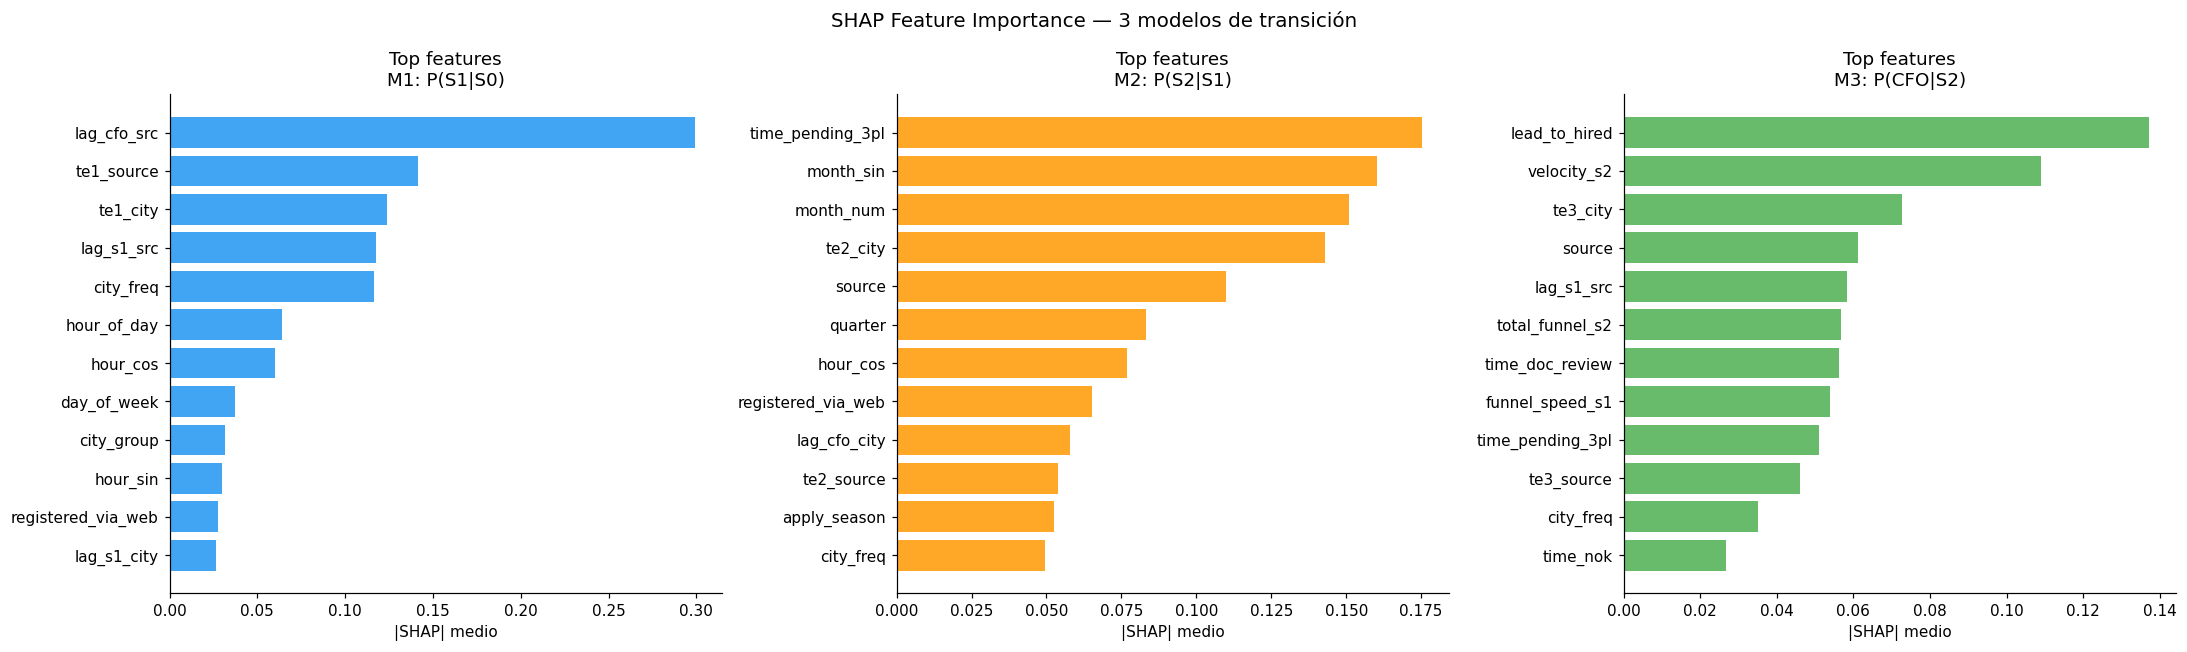

In [31]:
SHAP_N = 2000
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

shap_data = [
    (m1, X_te1, FEAT_T1, "#2196F3", "M1: P(S1|S0)"),
    (m2, X_te2, FEAT_T2, "#FF9800", "M2: P(S2|S1)"),
    (m3, X_te3, FEAT_T3, "#4CAF50", "M3: P(CFO|S2)"),
]
shap_explainers = {}

for ax, (model, X_te, feats, color, title) in zip(axes, shap_data):
    X_s  = X_te.sample(min(SHAP_N, len(X_te)), random_state=RANDOM_STATE)
    exp  = shap.TreeExplainer(model)
    svs  = exp.shap_values(X_s)
    shap_explainers[title] = (exp, X_s, svs, feats)
    mean_abs = np.abs(svs).mean(0)
    top_idx  = mean_abs.argsort()[::-1][:12]
    top_feats = [feats[i] for i in top_idx]
    top_vals  = mean_abs[top_idx]
    ax.barh(top_feats[::-1], top_vals[::-1], color=color, alpha=0.85)
    ax.set_title(f"Top features\n{title}"); ax.set_xlabel("|SHAP| medio")

plt.suptitle("SHAP Feature Importance — 3 modelos de transición", fontsize=13)
plt.tight_layout(); plt.show()

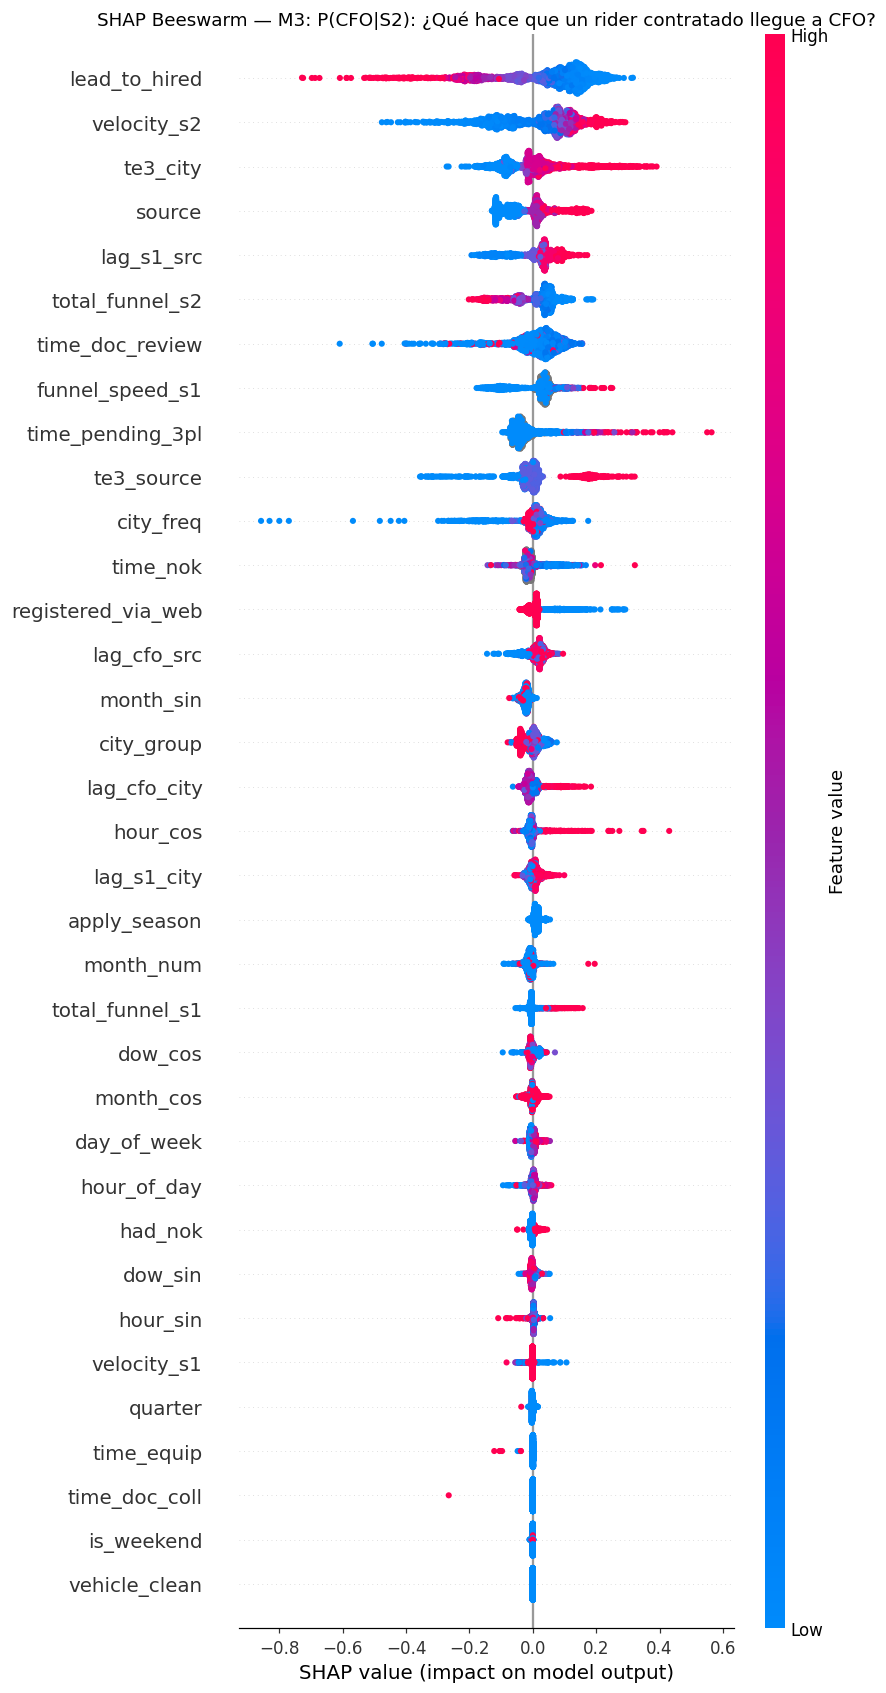

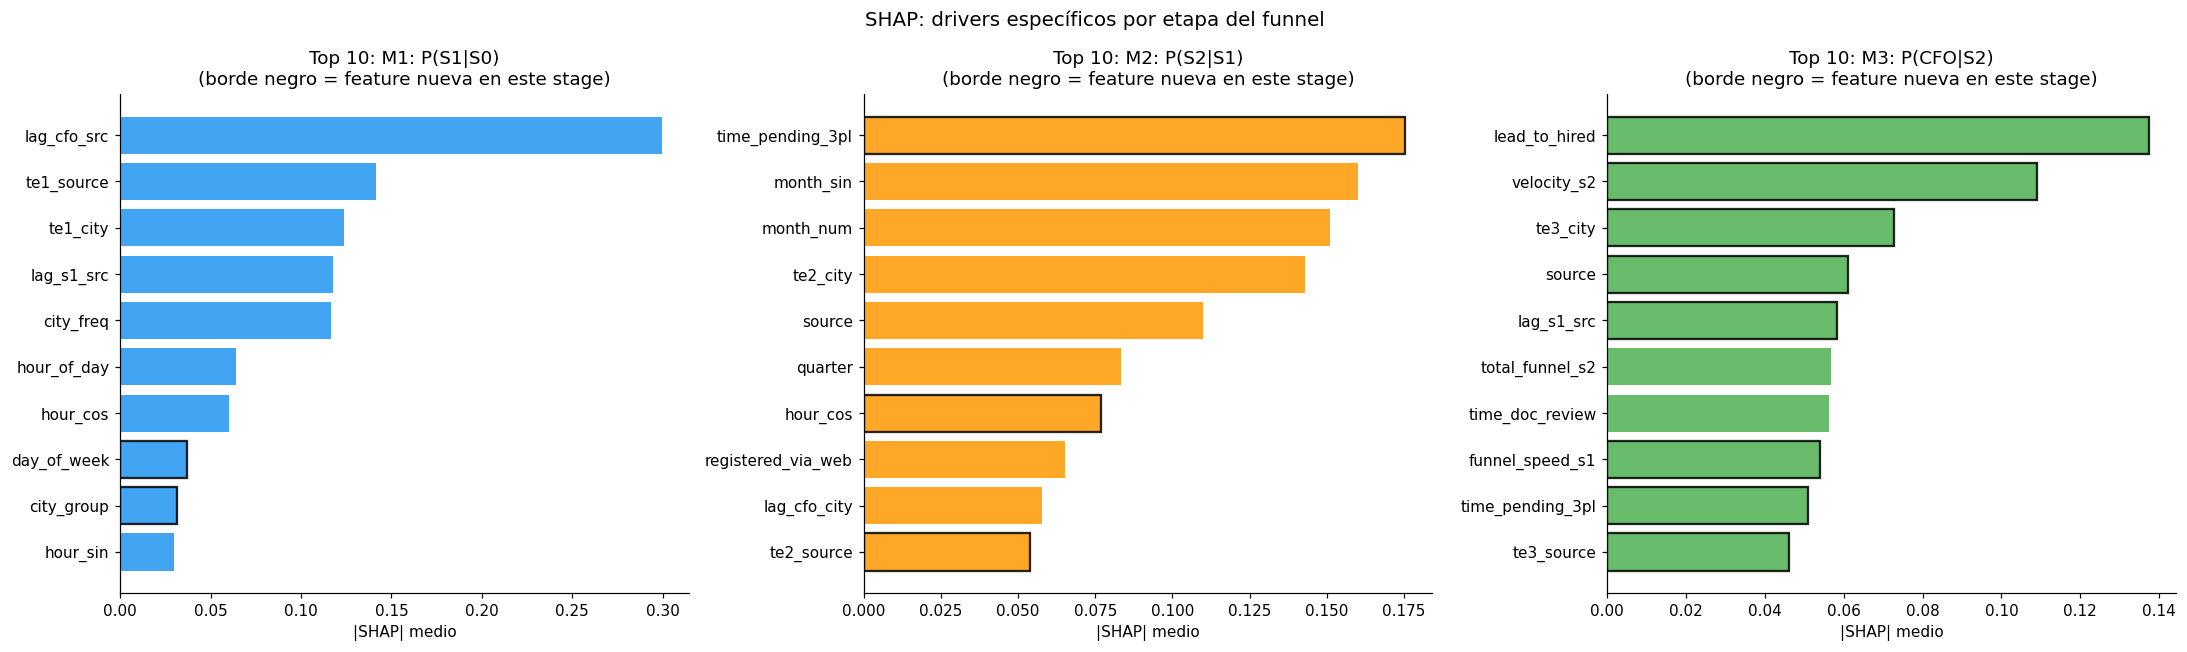


Insights por transición:
  M1 (S0→S1):  drivers de intención inicial — ciudad, source, hora de registro
  M2 (S1→S2):  velocidad de doc collection (time_doc_coll, total_funnel_s1)
  M3 (S2→CFO): comportamiento post-hiring — time_equip, had_nok, lead_to_hired


In [32]:
# ── SHAP Beeswarm para M3 (más importante operativamente) ────────────────────
_, X_s3, svs3, _ = shap_explainers["M3: P(CFO|S2)"]

plt.figure(figsize=(10, 7))
shap.summary_plot(svs3, X_s3, plot_type="dot", max_display=len(FEAT_T3), show=False)
plt.title("SHAP Beeswarm — M3: P(CFO|S2): ¿Qué hace que un rider contratado llegue a CFO?")
plt.tight_layout(); plt.show()

# ── SHAP comparativo: qué features son exclusivas de cada transición ──────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
colors_sh = {"M1: P(S1|S0)": "#2196F3", "M2: P(S2|S1)": "#FF9800", "M3: P(CFO|S2)": "#4CAF50"}
feats_order = {"M1: P(S1|S0)": FEAT_T1, "M2: P(S2|S1)": FEAT_T2, "M3: P(CFO|S2)": FEAT_T3}

for ax, key in zip(axes, ["M1: P(S1|S0)", "M2: P(S2|S1)", "M3: P(CFO|S2)"]):
    exp, X_s, svs, feats = shap_explainers[key]
    mean_abs = np.abs(svs).mean(0)
    top_idx  = mean_abs.argsort()[::-1][:10]
    top_f    = [feats[i] for i in top_idx]
    top_v    = mean_abs[top_idx]
    bars = ax.barh(top_f[::-1], top_v[::-1], color=colors_sh[key], alpha=0.85)
    # Highlight features unique to this transition stage
    for bar, feat in zip(bars[::-1], top_f[::-1]):
        if feat not in FEAT_BASE:
            bar.set_edgecolor("black"); bar.set_linewidth(1.5)
    ax.set_title(f"Top 10: {key}\n(borde negro = feature nueva en este stage)")
    ax.set_xlabel("|SHAP| medio")

plt.suptitle("SHAP: drivers específicos por etapa del funnel", fontsize=13)
plt.tight_layout(); plt.show()

print("\nInsights por transición:")
print("  M1 (S0→S1):  drivers de intención inicial — ciudad, source, hora de registro")
print("  M2 (S1→S2):  velocidad de doc collection (time_doc_coll, total_funnel_s1)")
print("  M3 (S2→CFO): comportamiento post-hiring — time_equip, had_nok, lead_to_hired")

---
## 13b. Análisis de Drift Temporal

Evaluamos la **estabilidad del modelo en el tiempo** midiendo:

- **AUC-PR por mes** en el set de test → detectar degradación
- **Tasa de target por mes** → detectar cambio de distribución de la clase positiva
- **Performance por ciudad** → detectar segmentos con drift local


=== ANÁLISIS DE DRIFT TEMPORAL ===

AUC-PR mensual (test set):
             n   cfo_rate   AP_M1  AP_Compuesta  AP_Cal.  AP_Fallback
period                                                               
2025-12    101  28.712871  0.3458        0.3569   0.3563       0.1841
2026-01  12257  23.929183  0.3732        0.4309   0.4496       0.5564
2026-02   2456  20.114007  0.3212        0.3331   0.3466       0.3424


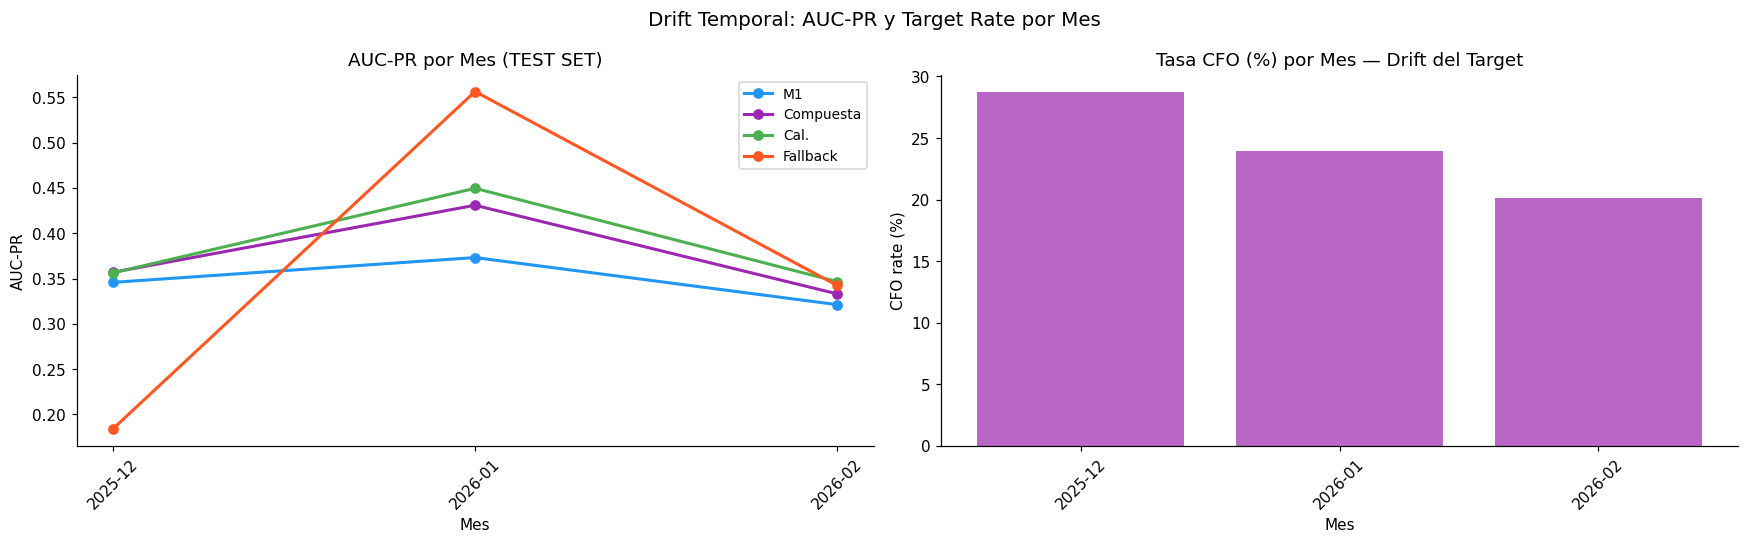


=== AUC-PR por Ciudad (TEST SET) ===
 city    n  cfo_rate  AP_Compuesta  AP_Cal.
  LOD  773      34.9        0.6184   0.6319
  RZE  145      33.1        0.6112   0.6458
  BYT  139      23.7        0.6088   0.6101
  TUN  185      28.6        0.5886   0.5833
  BZG  270      29.6        0.5562   0.5618
  SOS  213      21.1        0.5516   0.5678
  QLC  192      24.5        0.5141   0.5193
  QYY  164      26.8        0.5092   0.5083
  QEO  131      17.6        0.5045   0.5396
  SZZ  293      30.7        0.4972   0.5116
  GDN  821      32.2        0.4964   0.5114
  WAW 2754      28.2        0.4749   0.4878
  SZY  172      24.4        0.4680   0.4808
  OPL  120      25.0        0.4581   0.4822
  QLU  196      26.5        0.4382   0.4751
  CZW  128      28.1        0.4245   0.4266
  WRO  901      16.6        0.4055   0.4174
  KRA 1006      28.0        0.4049   0.4942
OTHER 5058      17.7        0.3989   0.3956
  POZ  766      21.8        0.3514   0.3906
  KTW  387       7.8        0.1779   0

In [33]:

# ── Drift Analysis: AUC-PR por mes ────────────────────────────────────────────
print("=== ANÁLISIS DE DRIFT TEMPORAL ===\n")

# Align calibrated probs to score_df index (te2/te3 are subsets of te1)
p2_cal_aligned = (pd.Series(p2_cal, index=te2.index)
                  .reindex(score_df.index)
                  .fillna(score_df["p_s2_s1"])   # fallback: uncalibrated score
                  .values)
p3_cal_aligned = (pd.Series(p3_cal, index=te3.index)
                  .reindex(score_df.index)
                  .fillna(score_df["p_cfo_s2"])  # fallback: uncalibrated score
                  .values)
y_comp_cal = p1_cal * p2_cal_aligned * p3_cal_aligned

score_df_drift = score_df.copy()
score_df_drift["p1_cal"] = p1_cal
score_df_drift["p2_cal_al"] = p2_cal_aligned
score_df_drift["p3_cal_al"] = p3_cal_aligned
score_df_drift["p_cfo_cal"] = y_comp_cal

# AUC-PR por mes: M1, Compuesta, Compuesta calibrada
monthly_perf = []
for period, grp in score_df_drift.groupby("_month_period"):
    row = {"period": period, "n": len(grp), "cfo_rate": grp["is_cfo"].mean()*100}
    yt  = grp["is_cfo"].values
    if yt.sum() < 2 or yt.sum() == len(yt):
        continue  # skip degenerate months
    for col, lbl in [("p_s1_s0","M1"), ("p_cfo_composed","Compuesta"),
                     ("p_cfo_cal","Cal."), ("p_cfo_fallback","Fallback")]:
        if col not in grp.columns: continue
        try:
            row[f"AP_{lbl}"] = round(average_precision_score(yt, grp[col].values), 4)
        except Exception:
            row[f"AP_{lbl}"] = np.nan
    monthly_perf.append(row)

mp_df = pd.DataFrame(monthly_perf).set_index("period")
print("AUC-PR mensual (test set):")
print(mp_df.to_string())

# Plot: AUC-PR over time + target drift
ap_cols = [c for c in mp_df.columns if c.startswith("AP_")]
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors_drift = {"AP_M1":"#2196F3","AP_Compuesta":"#9C27B0","AP_Cal.":"#4CAF50","AP_Fallback":"#FF5722"}
for col in ap_cols:
    if col not in mp_df: continue
    axes[0].plot(mp_df.index, mp_df[col], "o-", lw=2,
                 label=col.replace("AP_",""), color=colors_drift.get(col,"gray"))
axes[0].set_title("AUC-PR por Mes (TEST SET)"); axes[0].set_xlabel("Mes")
axes[0].set_ylabel("AUC-PR"); axes[0].legend(fontsize=9)
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(mp_df.index, mp_df["cfo_rate"], color="#9C27B0", alpha=0.7)
axes[1].set_title("Tasa CFO (%) por Mes — Drift del Target")
axes[1].set_xlabel("Mes"); axes[1].set_ylabel("CFO rate (%)")
axes[1].tick_params(axis="x", rotation=45)
plt.suptitle("Drift Temporal: AUC-PR y Target Rate por Mes", fontsize=13)
plt.tight_layout(); plt.show()

# ── Drift por ciudad ──────────────────────────────────────────────────────────
print("\n=== AUC-PR por Ciudad (TEST SET) ===")
city_perf = []
for city_code, grp in score_df_drift.groupby("city_group"):
    yt = grp["is_cfo"].values
    if len(grp) < 20 or yt.sum() < 2 or yt.sum() == len(yt): continue
    try:
        city_name = le_dict["city_group"].inverse_transform([int(city_code)])[0]
    except Exception:
        city_name = str(city_code)
    row = {"city": city_name, "n": len(grp), "cfo_rate": round(yt.mean()*100,1)}
    for col, lbl in [("p_cfo_composed","Compuesta"), ("p_cfo_cal","Cal.")]:
        if col in grp.columns:
            try:
                row[f"AP_{lbl}"] = round(average_precision_score(yt, grp[col].values), 4)
            except Exception:
                row[f"AP_{lbl}"] = np.nan
    city_perf.append(row)

cp_df = pd.DataFrame(city_perf).sort_values("AP_Compuesta", ascending=False)
print(cp_df.to_string(index=False))

# Check for cities with major drift (AP < 0.5 or significantly below mean)
mean_ap = cp_df["AP_Compuesta"].mean() if "AP_Compuesta" in cp_df else 0
flagged = cp_df[cp_df.get("AP_Compuesta", pd.Series()) < mean_ap * 0.75]
if len(flagged) > 0:
    print(f"\n⚠️  Ciudades con AUC-PR < 75% de la media ({mean_ap:.3f}):")
    print(flagged[["city","n","cfo_rate","AP_Compuesta"]].to_string(index=False))
else:
    print("\n✅  Sin ciudades con drift severo detectado.")


  M1 — CONVERSIÓN S0→S1 POR SOURCE  (base: 58.9%)
      Source     N  CR S0→S1 (%) vs base
    REFERRAL 11655          85.8 +26.9pp
         3PL 36270          71.2 +12.3pp
     ORGANIC 61468          57.0  -1.9pp
   RIDER WEB  2589          47.1 -11.8pp
    PERF MKT 18650          46.3 -12.6pp
JOB PLATFORM 14892          33.8 -25.1pp

  M2 — CONVERSIÓN S1→S2 POR CIUDAD  (base: 74.5%)
Ciudad     N  CR S1→S2 (%) vs base
   GDN  4679          83.6  +9.1pp
   BZG  1533          81.5  +7.0pp
   SZY  1067          79.5  +5.0pp
   BYT   680          79.3  +4.8pp
   RZE   897          78.4  +3.9pp
   QLC   864          78.4  +3.9pp
   WAW 18431          78.3  +3.8pp
   CZW   714          77.9  +3.4pp
   QYY   965          77.5  +3.0pp
   QLU  1195          76.1  +1.6pp
   SOS   804          75.0  +0.5pp
   OPL   619          74.6  +0.1pp
   QEO   647          74.3  -0.2pp
   KRA  7045          74.0  -0.5pp
   TUN   937          73.9  -0.6pp
   SZZ  2169          73.5  -1.0pp
   LOD  5075     

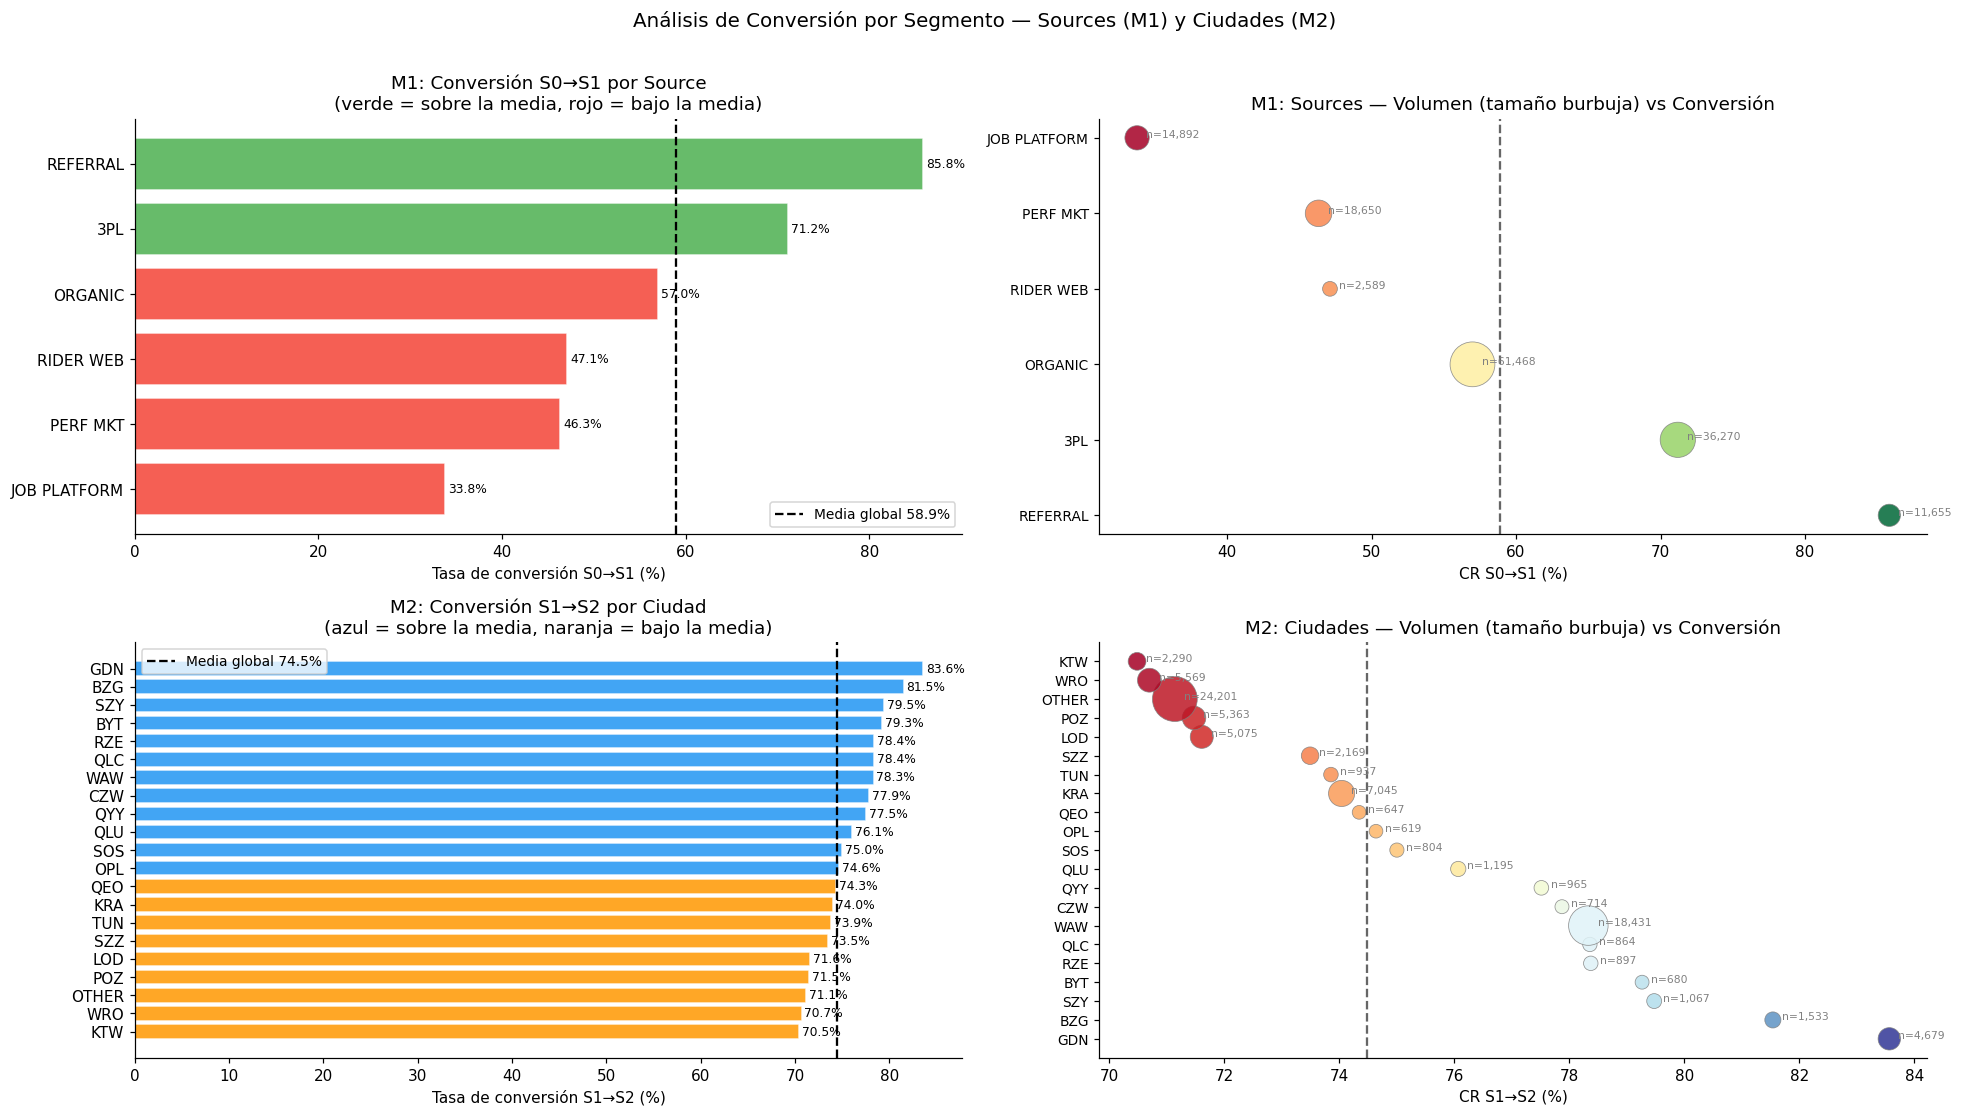

In [34]:

def _decode(series, col):
    """Inverse-transform a label-encoded column using le_dict."""
    try:
        return le_dict[col].inverse_transform(series.astype(int).values)
    except Exception:
        return series.astype(str).values

MIN_N = 30   # minimum observations to show a segment

# ── 1. SOURCES → M1: P(S1|S0) ────────────────────────────────────────────────
_df1 = pd.concat([tr1, va1, te1]).copy()
_df1["source_name"] = _decode(_df1["source"], "source")

src_stats = (
    _df1.groupby("source_name", observed=True)
    .agg(
        n           = ("TARGET", "count"),
        cr_s1       = ("TARGET", "mean"),
    )
    .reset_index()
    .query(f"n >= {MIN_N}")
    .sort_values("cr_s1", ascending=False)
    .reset_index(drop=True)
)
src_stats["cr_s1_pct"] = src_stats["cr_s1"] * 100
base_s1 = _df1["TARGET"].mean() * 100

# ── 2. CITIES → M2: P(S2|S1) ─────────────────────────────────────────────────
_df2 = pd.concat([tr2, va2, te2]).copy()
_df2["city_name"] = _decode(_df2["city_group"], "city_group")

city_stats = (
    _df2.groupby("city_name", observed=True)
    .agg(
        n       = ("TARGET", "count"),
        cr_s2   = ("TARGET", "mean"),
    )
    .reset_index()
    .query(f"n >= {MIN_N}")
    .sort_values("cr_s2", ascending=False)
    .reset_index(drop=True)
)
city_stats["cr_s2_pct"] = city_stats["cr_s2"] * 100
base_s2 = _df2["TARGET"].mean() * 100

# ── 3. Print tables ───────────────────────────────────────────────────────────
print("=" * 60)
print(f"  M1 — CONVERSIÓN S0→S1 POR SOURCE  (base: {base_s1:.1f}%)")
print("=" * 60)
_src_print = src_stats[["source_name", "n", "cr_s1_pct"]].copy()
_src_print.columns = ["Source", "N", "CR S0→S1 (%)"]
_src_print["CR S0→S1 (%)"] = _src_print["CR S0→S1 (%)"].round(1)
_src_print["vs base"] = (_src_print["CR S0→S1 (%)"] - base_s1).round(1).apply(lambda x: f"{x:+.1f}pp")
print(_src_print.to_string(index=False))

print()
print("=" * 60)
print(f"  M2 — CONVERSIÓN S1→S2 POR CIUDAD  (base: {base_s2:.1f}%)")
print("=" * 60)
_city_print = city_stats[["city_name", "n", "cr_s2_pct"]].copy()
_city_print.columns = ["Ciudad", "N", "CR S1→S2 (%)"]
_city_print["CR S1→S2 (%)"] = _city_print["CR S1→S2 (%)"].round(1)
_city_print["vs base"] = (_city_print["CR S1→S2 (%)"] - base_s2).round(1).apply(lambda x: f"{x:+.1f}pp")
print(_city_print.to_string(index=False))

# ── 4. Visualización ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# Panel A: Sources — conversion rate
clr_src = ["#4CAF50" if v > base_s1 else "#F44336" for v in src_stats["cr_s1_pct"]]
axes[0, 0].barh(src_stats["source_name"][::-1], src_stats["cr_s1_pct"][::-1],
                color=clr_src[::-1], alpha=0.85, edgecolor="white")
axes[0, 0].axvline(base_s1, color="black", ls="--", lw=1.5, label=f"Media global {base_s1:.1f}%")
axes[0, 0].set_xlabel("Tasa de conversión S0→S1 (%)")
axes[0, 0].set_title("M1: Conversión S0→S1 por Source\n(verde = sobre la media, rojo = bajo la media)")
axes[0, 0].legend(fontsize=9)
for i, (_, row_s) in enumerate(src_stats[::-1].iterrows()):
    axes[0, 0].text(row_s["cr_s1_pct"] + 0.3, i,
                    f"{row_s['cr_s1_pct']:.1f}%", va="center", fontsize=8)

# Panel B: Sources — volume bubble (n vs conversion rate)
sc = axes[0, 1].scatter(src_stats["cr_s1_pct"], range(len(src_stats)),
                        s=src_stats["n"] / src_stats["n"].max() * 800 + 60,
                        c=src_stats["cr_s1_pct"], cmap="RdYlGn",
                        edgecolors="gray", linewidth=0.5, alpha=0.85)
axes[0, 1].set_yticks(range(len(src_stats)))
axes[0, 1].set_yticklabels(src_stats["source_name"], fontsize=9)
axes[0, 1].axvline(base_s1, color="black", ls="--", lw=1.5, alpha=0.6)
axes[0, 1].set_xlabel("CR S0→S1 (%)")
axes[0, 1].set_title("M1: Sources — Volumen (tamaño burbuja) vs Conversión")
for i, row_s in src_stats.iterrows():
    axes[0, 1].annotate(f"n={row_s['n']:,}", (row_s["cr_s1_pct"], i),
                        textcoords="offset points", xytext=(6, 0), fontsize=7, color="gray")

# Panel C: Cities — conversion rate
clr_city = ["#2196F3" if v > base_s2 else "#FF9800" for v in city_stats["cr_s2_pct"]]
axes[1, 0].barh(city_stats["city_name"][::-1], city_stats["cr_s2_pct"][::-1],
                color=clr_city[::-1], alpha=0.85, edgecolor="white")
axes[1, 0].axvline(base_s2, color="black", ls="--", lw=1.5, label=f"Media global {base_s2:.1f}%")
axes[1, 0].set_xlabel("Tasa de conversión S1→S2 (%)")
axes[1, 0].set_title("M2: Conversión S1→S2 por Ciudad\n(azul = sobre la media, naranja = bajo la media)")
axes[1, 0].legend(fontsize=9)
for i, (_, row_c) in enumerate(city_stats[::-1].iterrows()):
    axes[1, 0].text(row_c["cr_s2_pct"] + 0.3, i,
                    f"{row_c['cr_s2_pct']:.1f}%", va="center", fontsize=8)

# Panel D: Cities — volume bubble
axes[1, 1].scatter(city_stats["cr_s2_pct"], range(len(city_stats)),
                   s=city_stats["n"] / city_stats["n"].max() * 800 + 60,
                   c=city_stats["cr_s2_pct"], cmap="RdYlBu",
                   edgecolors="gray", linewidth=0.5, alpha=0.85)
axes[1, 1].set_yticks(range(len(city_stats)))
axes[1, 1].set_yticklabels(city_stats["city_name"], fontsize=9)
axes[1, 1].axvline(base_s2, color="black", ls="--", lw=1.5, alpha=0.6)
axes[1, 1].set_xlabel("CR S1→S2 (%)")
axes[1, 1].set_title("M2: Ciudades — Volumen (tamaño burbuja) vs Conversión")
for i, row_c in city_stats.iterrows():
    axes[1, 1].annotate(f"n={row_c['n']:,}", (row_c["cr_s2_pct"], i),
                        textcoords="offset points", xytext=(6, 0), fontsize=7, color="gray")

plt.suptitle("Análisis de Conversión por Segmento — Sources (M1) y Ciudades (M2)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


=== DETECCIÓN DE DRIFT EN TASA DE CONVERSION ===

_month_period     n  s1_rate  cfo_rate  cfo_roll3  drift_flag
      2025-04 10535 0.607024  0.262079        NaN        <NA>
      2025-05 14736 0.580551   0.27633   0.262079       False
      2025-06 18877 0.552789  0.258992   0.269204       False
      2025-07 16506 0.571126   0.21265   0.265800       False
      2025-08 13456 0.574093  0.227705   0.249324       False
      2025-09 17675 0.539349  0.249675   0.233116       False
      2025-10 15997 0.595174    0.2643   0.230010       False
      2025-11 13291 0.621624  0.281393   0.247226       False
      2025-12  9738 0.665742  0.267201   0.265123       False
      2026-01 12257 0.639798  0.239292   0.270965       False
      2026-02  2456 0.637622   0.20114   0.262629        True


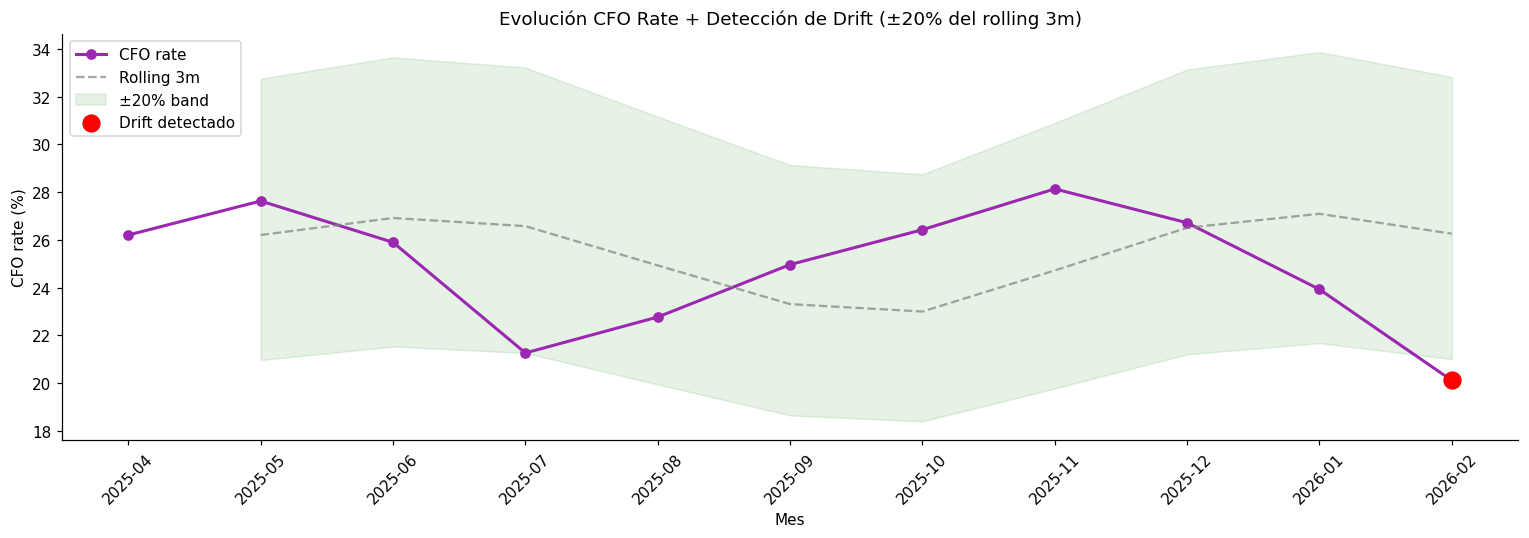


⚠️  DRIFT DETECTADO. Considerar:
  1. Añadir sample_weight temporal (más peso a meses recientes)
  2. Incluir 'month_num' como feature explícita
  3. Reentrenar con solo los últimos N meses de datos de train


In [35]:
# ── Temporal Trend: target rate shift detection ───────────────────────────────
print("=== DETECCIÓN DE DRIFT EN TASA DE CONVERSION ===\n")

# Full dataset monthly stats (train + val + test)
full_monthly = df.groupby("_month_period").agg(
    n=("is_cfo","count"),
    s1_rate=("reached_s1","mean"),
    s2_rate=("reached_s2","mean"),
    cfo_rate=("is_cfo","mean"),
).reset_index().sort_values("_month_period")

# Flag months where rate drops > 20% from trailing 3-month mean
full_monthly["cfo_roll3"] = full_monthly["cfo_rate"].rolling(3, min_periods=1).mean().shift(1)
full_monthly["drift_flag"] = (
    (full_monthly["cfo_rate"] < full_monthly["cfo_roll3"] * 0.80) |
    (full_monthly["cfo_rate"] > full_monthly["cfo_roll3"] * 1.25)
)

print(full_monthly[["_month_period","n","s1_rate","cfo_rate","cfo_roll3","drift_flag"]].to_string(index=False))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(full_monthly["_month_period"], full_monthly["cfo_rate"]*100, "o-", lw=2,
        color="#9C27B0", label="CFO rate")
ax.plot(full_monthly["_month_period"], full_monthly["cfo_roll3"]*100, "--",
        lw=1.5, color="gray", alpha=0.7, label="Rolling 3m")
ax.fill_between(range(len(full_monthly)),
                full_monthly["cfo_roll3"].values*80,
                full_monthly["cfo_roll3"].values*125, alpha=0.1, color="green",
                label="±20% band")
# Mark drift points
drift_pts = full_monthly[full_monthly["drift_flag"]]
if len(drift_pts):
    dp_x = [list(full_monthly["_month_period"]).index(p) for p in drift_pts["_month_period"]]
    ax.scatter(dp_x, drift_pts["cfo_rate"]*100, s=120, color="red", zorder=5, label="Drift detectado")
ax.set_title("Evolución CFO Rate + Detección de Drift (±20% del rolling 3m)")
ax.set_xlabel("Mes"); ax.set_ylabel("CFO rate (%)")
ax.tick_params(axis="x", rotation=45); ax.legend()
plt.tight_layout(); plt.show()

# ── Temporal weighting recommendation ────────────────────────────────────────
if full_monthly["drift_flag"].sum() > 0:
    print("\n⚠️  DRIFT DETECTADO. Considerar:")
    print("  1. Añadir sample_weight temporal (más peso a meses recientes)")
    print("  2. Incluir 'month_num' como feature explícita")
    print("  3. Reentrenar con solo los últimos N meses de datos de train")
else:
    print("\n✅  Sin cambios de tendencia significativos. Modelo estable.")


---
## 14. Output de Negocio — Análisis de Cuellos de Botella

### Pipeline accionable
Para cada lead y en cada etapa del funnel, el sistema proporciona:
- La probabilidad específica de la **próxima transición**
- El diagnóstico del **cuello de botella** principal
- Un **ranking** de prioridad para acciones operativas

In [36]:
# ── Bottleneck: transition conversion rates by city and source ─────────────────
def conversion_by_seg(ds_train, ds_test, seg_col, target_col, le, min_n=15):
    """Segmented conversion rate for a given transition."""
    rows = []
    for seg_code, grp in ds_test.groupby(seg_col):
        if len(grp) < min_n: continue
        train_grp = ds_train[ds_train[seg_col] == seg_code]
        if len(train_grp) < 5: continue
        seg_name = le.inverse_transform([int(seg_code)])[0]
        rows.append({
            "segment":        seg_name,
            "n_test":         len(grp),
            "conv_rate_test": grp[target_col].mean(),
            "conv_rate_train":train_grp[target_col].mean(),
            "delta":          grp[target_col].mean() - train_grp[target_col].mean(),
        })
    return pd.DataFrame(rows).sort_values("conv_rate_test")

print("=== CUELLOS DE BOTELLA POR TRANSICIÓN ===\n")

print("▶ M1 — Ciudades con menor tasa S0→S1 (doc collection) en test:")
cb_t1_city = conversion_by_seg(tr1, te1, "city_group", "TARGET", le_dict["city_group"], min_n=20)
print(cb_t1_city.head(8).to_string(index=False))

print("\n▶ M2 — Ciudades con menor tasa S1→S2 (hiring) en test:")
cb_t2_city = conversion_by_seg(tr2, te2, "city_group", "TARGET", le_dict["city_group"], min_n=10)
print(cb_t2_city.head(8).to_string(index=False))

print("\n▶ M3 — Sources con menor tasa S2→CFO en test:")
cb_t3_src = conversion_by_seg(tr3, te3, "source", "TARGET", le_dict["source"], min_n=5)
print(cb_t3_src.head(8).to_string(index=False))

=== CUELLOS DE BOTELLA POR TRANSICIÓN ===

▶ M1 — Ciudades con menor tasa S0→S1 (doc collection) en test:
segment  n_test  conv_rate_test  conv_rate_train    delta
  OTHER    5058        0.511665         0.454337 0.057327
    SZY     172        0.540698         0.536184 0.004513
    BYT     139        0.582734         0.507905 0.074829
    TUN     185        0.583784         0.472143 0.111641
    RZE     145        0.586207         0.540825 0.045382
    QLC     192        0.598958         0.539669 0.059290
    QYY     164        0.609756         0.501403 0.108354
    KTW     387        0.614987         0.550876 0.064111

▶ M2 — Ciudades con menor tasa S1→S2 (hiring) en test:
segment  n_test  conv_rate_test  conv_rate_train     delta
    KTW     238        0.256303         0.811621 -0.555318
    WRO     627        0.424242         0.767713 -0.343471
    KRA     786        0.517812         0.796557 -0.278746
    QEO      83        0.518072         0.787330 -0.269258
    POZ     531      

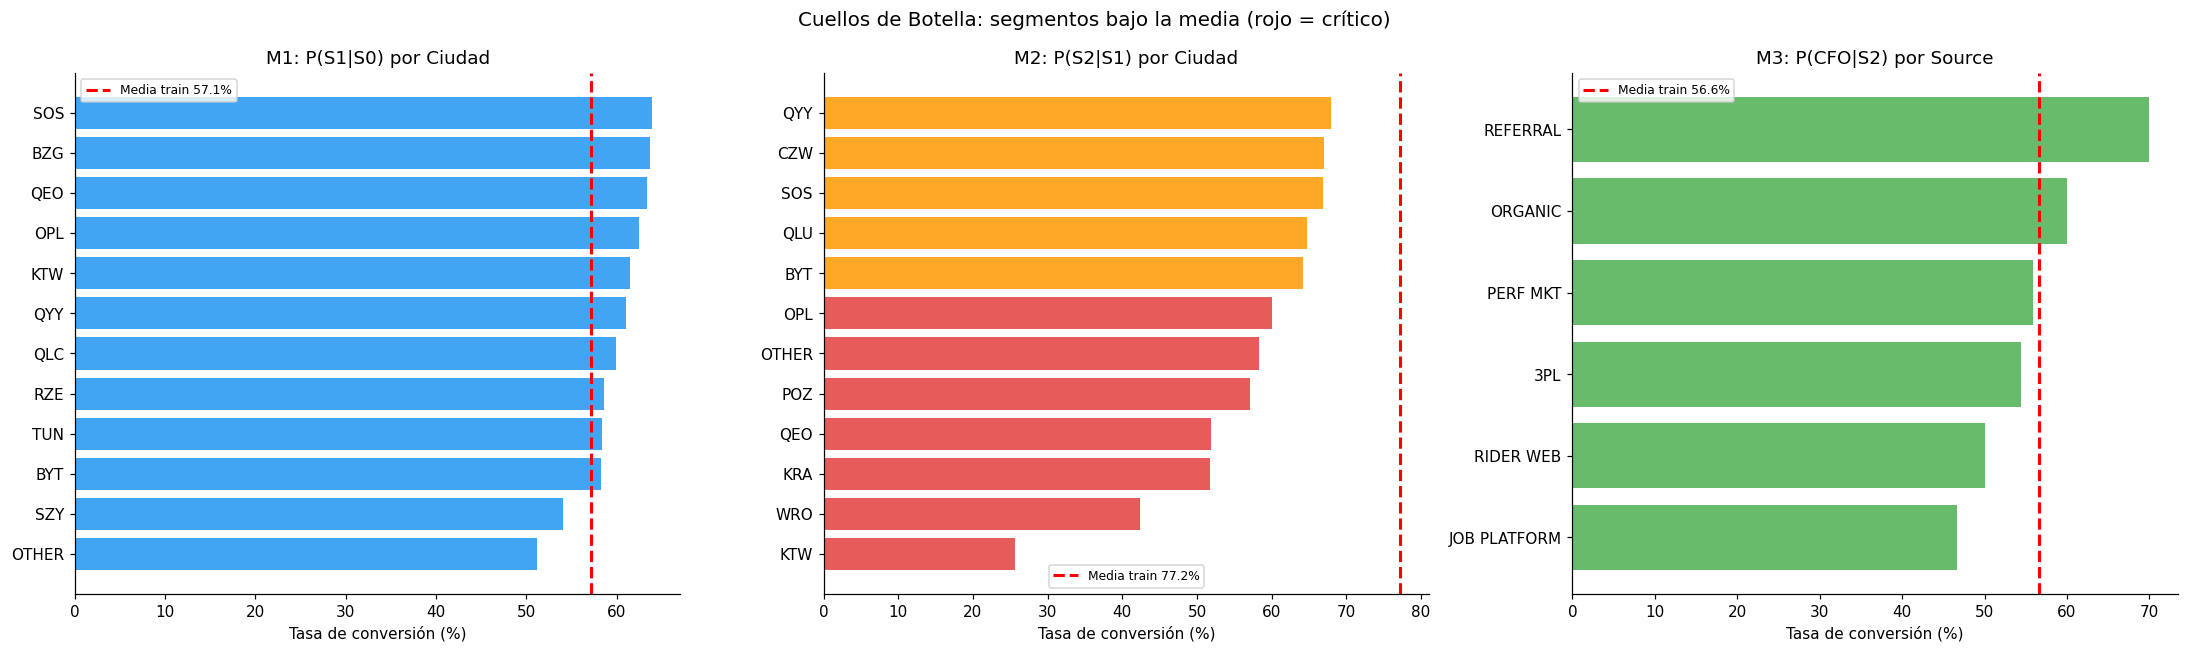

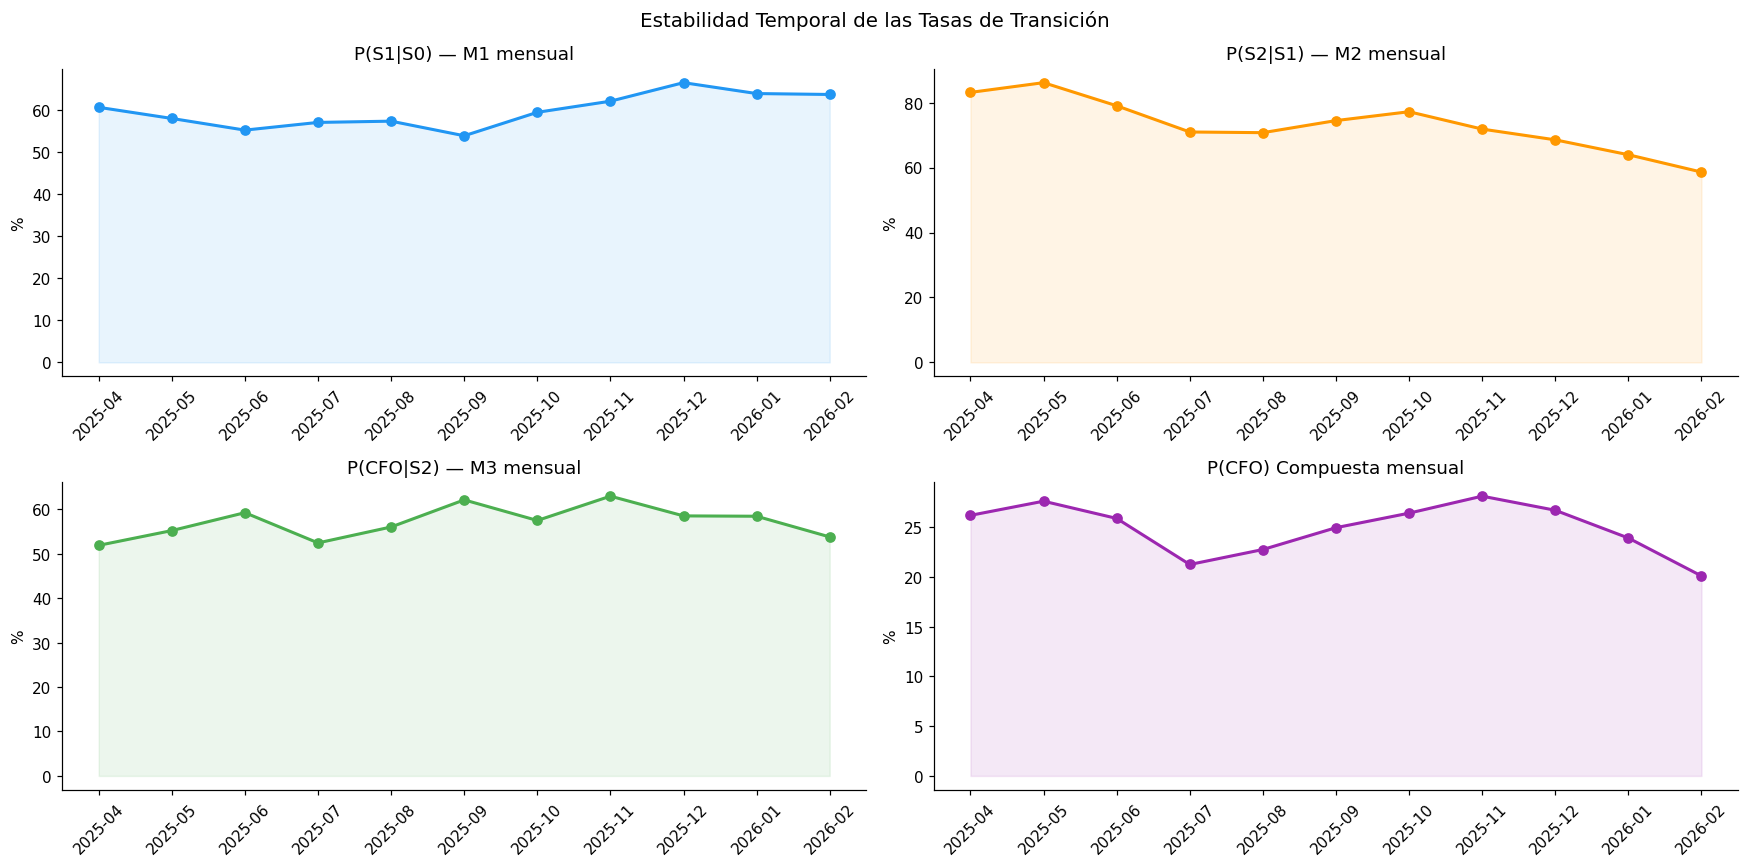

In [37]:
# ── Bottleneck visualization ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (cb_df, title, color, base_rate) in zip(axes, [
    (cb_t1_city, "M1: P(S1|S0) por Ciudad",   "#2196F3", tr1["TARGET"].mean()),
    (cb_t2_city, "M2: P(S2|S1) por Ciudad",   "#FF9800", tr2["TARGET"].mean()),
    (cb_t3_src,  "M3: P(CFO|S2) por Source",  "#4CAF50", tr3["TARGET"].mean()),
]):
    if cb_df.empty: continue
    plot_df = cb_df.head(12)
    colors_bar = ["#E53E3E" if r < base_rate * 0.8 else color
                  for r in plot_df["conv_rate_test"]]
    ax.barh(plot_df["segment"], plot_df["conv_rate_test"]*100,
            color=colors_bar, alpha=0.85)
    ax.axvline(base_rate * 100, color="red", ls="--", lw=2,
               label=f"Media train {base_rate*100:.1f}%")
    ax.set_xlabel("Tasa de conversión (%)"); ax.set_title(title); ax.legend(fontsize=8)

plt.suptitle("Cuellos de Botella: segmentos bajo la media (rojo = crítico)", fontsize=13)
plt.tight_layout(); plt.show()

# ── Temporal stability of transition rates ────────────────────────────────────
monthly = df.groupby("_month_period").agg(
    n=("is_cfo","count"),
    p_t1=("reached_s1","mean"),
    cfo_rate=("is_cfo","mean"),
).reset_index().sort_values("_month_period")

s1_monthly = df[df["reached_s1"]==1].groupby("_month_period")["was_hired"].mean().reset_index(name="p_t2")
s2_monthly = df[df["was_hired"]==1].groupby("_month_period")["is_cfo"].mean().reset_index(name="p_t3")
monthly = monthly.merge(s1_monthly, on="_month_period", how="left")                  .merge(s2_monthly, on="_month_period", how="left")
monthly["p_composed"] = monthly["p_t1"] * monthly["p_t2"] * monthly["p_t3"]

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
for ax, (col, label, color) in zip(axes.flat, [
    ("p_t1",        "P(S1|S0) — M1 mensual",      "#2196F3"),
    ("p_t2",        "P(S2|S1) — M2 mensual",      "#FF9800"),
    ("p_t3",        "P(CFO|S2) — M3 mensual",     "#4CAF50"),
    ("p_composed",  "P(CFO) Compuesta mensual",    "#9C27B0"),
]):
    ax.plot(monthly["_month_period"], monthly[col]*100, "o-", lw=2, color=color)
    ax.fill_between(range(len(monthly)), monthly[col].values*100, alpha=0.1, color=color)
    ax.set_title(label); ax.set_ylabel("%"); ax.tick_params(axis="x", rotation=45)
plt.suptitle("Estabilidad Temporal de las Tasas de Transición", fontsize=13)
plt.tight_layout(); plt.show()

In [38]:
# ── Lead Scoring Pipeline (calibrated) ───────────────────────────────────────
score_output = score_df[["applicant_id","created_at","_month_period","is_cfo",
                          "reached_s1","reached_s2",
                          "p_s1_s0","p_s2_s1","p_cfo_s2",
                          "p_cfo_composed","p_cfo_fallback"]].copy()

score_output["city"]   = le_dict["city_group"].inverse_transform(te1["city_group"].values)
score_output["source"] = le_dict["source"].inverse_transform(te1["source"].values)

# ── Best calibrated composed probability ─────────────────────────────────────
score_output["p_cfo_cal"] = y_comp_cal   # Platt/Isotonic best per model, then composed

# ── Bottleneck diagnosis per lead (using calibrated scores) ──────────────────
q25_t1 = np.percentile(p1_cal, 25)
q25_t2 = np.percentile(p2_cal, 25)
q25_t3 = np.percentile(p3_cal, 25)

score_output["p1_cal"]   = p1_cal
score_output["p2_cal"]   = pd.Series(p2_cal, index=te2.index).reindex(score_output.index).fillna(global_p2).values
score_output["p3_cal"]   = pd.Series(p3_cal, index=te3.index).reindex(score_output.index).fillna(global_p3).values

score_output["bottleneck"] = "Balanceado"
score_output.loc[score_output["p1_cal"] < q25_t1, "bottleneck"] = "M1: doc collection"
score_output.loc[score_output["p2_cal"] < q25_t2, "bottleneck"] = "M2: hiring rate"
score_output.loc[score_output["p3_cal"] < q25_t3, "bottleneck"] = "M3: activation"

# ── Summary metrics for final scoring ─────────────────────────────────────────
yt  = score_output["is_cfo"].values
ypc = score_output["p_cfo_cal"].values

print("=== TOP 20 LEADS POR P(CFO) CALIBRADA — TEST SET ===")
top_cols = ["applicant_id","created_at","city","source",
            "p_s1_s0","p_s2_s1","p_cfo_s2","p_cfo_composed","p_cfo_cal","is_cfo"]
print(score_output.sort_values("p_cfo_cal", ascending=False).head(20)[top_cols].to_string(index=False))

print("\n=== MÉTRICAS NEGOCIO (P(CFO) Calibrada) ===")
print(f"  AUC-PR:  {average_precision_score(yt, ypc):.4f} | AUC-ROC: {roc_auc_score(yt, ypc):.4f}")
print(f"  Brier:   {brier_score_loss(yt, ypc):.4f}")
for k in [0.05, 0.10, 0.20]:
    print(f"  P@{int(k*100):2d}%: {precision_at_k(yt, ypc, k):.4f}  |  Lift@{int(k*100):2d}%: {lift_at_k(yt, ypc, k):.2f}x  |  Recall coverage: {int(len(yt)*k):,} leads")

print("\n=== DIAGNÓSTICO DE CUELLOS DE BOTELLA (calibrado) ===")
print(score_output["bottleneck"].value_counts().to_string())

print("\n=== P(CFO) calibrada POR CUELLO DE BOTELLA ===")
print(score_output.groupby("bottleneck")["p_cfo_cal"].describe().round(4).to_string())


=== TOP 20 LEADS POR P(CFO) CALIBRADA — TEST SET ===
                        applicant_id                 created_at city   source  p_s1_s0  p_s2_s1  p_cfo_s2  p_cfo_composed  p_cfo_cal  is_cfo
347276db-ce0d-470c-a735-034ed910ae33 2026-01-15 13:24:21.426404  GDN REFERRAL 0.889687 0.933877  0.807904        0.671254   0.741115       1
35b6b2e2-b0e9-46fb-a0b3-c3a4bfcaadca 2026-01-22 12:04:49.650485  GDN REFERRAL 0.882633 0.933877  0.770958        0.635479   0.703084       0
c41d00d6-3367-42a6-b5b5-d852fac4779f 2026-01-26 12:07:02.773018  GDN REFERRAL 0.897220 0.931886  0.761593        0.636773   0.700395       1
fd8fcfc5-30db-4caa-9011-54810b11e3f8 2026-01-19 13:15:48.888576  GDN REFERRAL 0.898614 0.931886  0.760556        0.636894   0.700123       0
8258fec7-0d5c-486b-b230-99f8db2ddd06 2026-01-19 13:46:50.448183  GDN REFERRAL 0.898614 0.931886  0.760556        0.636894   0.700123       1
b5e17c92-2443-43df-bfa3-c522405dc9cd 2026-01-19 13:08:58.210867  GDN REFERRAL 0.898614 0.931886  0.76

---